# IFA2 Interconnector — Spread-Direct OU Model
**MSc Climate Change Finance and Investment**

## Model Overview

This notebook models the GB–France electricity price spread directly as a
mean-reverting OU process with compound Poisson jumps (Cartea & González-Pedraz 2012).
Revenue = |spread| × 1,000 MW × 0.95 availability × capture ratio.

**Decomposition:** $S_t = f_S(t, h) + X_t$

where $f_S(t, h)$ is the deterministic component (OLS — annual Fourier, linear trend,
weekend/holiday dummy, 24 hourly dummies) and $X_t$ is the stochastic daily OU residual.

Monte Carlo simulation runs 10,000 paths × 20 projection years under three Annex M
(DESNZ Feb 2026) GB price scenarios paired with RTE/ENTSO-E FR price paths.


## Section 1: Configuration & Imports

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as sp_stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.linewidth': 0.3, 'grid.alpha': 0.5, 'font.size': 10,
})

IC_DIR     = Path('/Users/aadesh/Documents/IC')
EXCEL_PATH = IC_DIR / 'GB-FR07.xlsx'
OUTPUT_DIR = IC_DIR / 'M2'
OUTPUT_DIR.mkdir(exist_ok=True)

REGIME_START    = 2021   # IFA2 Window 1 commissioning year
PROJ_START_YEAR = 2026   # first year without a complete Ofgem actual
N_PROJ_YEARS    = 20     # 2026-2045  (total regime = 25 yrs: 2021-2045)
CAPACITY_MW     = 1_000
AVAILABILITY    = 0.9659
N_PATHS         = 10_000
RANDOM_SEED     = 42
PROJ_TAU_GROWTH = 0.0
ANCHOR_DATE     = pd.Timestamp('2025-01-01')

# Ofgem-disclosed gross congestion revenues (net of market costs), GBPm
# 2021 not separately disclosed (commissioning / ramp-up year)
ACTUALS = {2022: 69.6, 2023: 100.8, 2024: 101.6, 2025: 72.2}   # Turnover from audited accounts

print(f'Config: REGIME_START={REGIME_START}  PROJ={PROJ_START_YEAR}-{PROJ_START_YEAR+N_PROJ_YEARS-1}')
print(f'        CAPACITY={CAPACITY_MW}MW  AVAILABILITY={AVAILABILITY}')
print(f'        N_PATHS={N_PATHS:,}  ANCHOR={ANCHOR_DATE.date()}')


Config: REGIME_START=2021  PROJ=2026-2045
        CAPACITY=1000MW  AVAILABILITY=0.9659
        N_PATHS=10,000  ANCHOR=2025-01-01


## Section 2: Data Loading

Data source: `GB-FR07.xlsx` — Bloomberg GB and FR hourly electricity prices + EUR/GBP FX.

| Sheet | Content | Units |
|---|---|---|
| `GB_FINAL` | N2EX GB day-ahead hourly prices | GBP/MWh |
| `FR_FINAL` | EPEX France day-ahead hourly prices | EUR/MWh |
| `GBP-EUR` | Bloomberg EUR/GBP daily FX rate | GBP per 1 EUR |

**Wide-to-long:** Each sheet stores dates as rows, hours (H01–H24) as columns. `_wide_to_hourly()` pivots to a timestamp-indexed Series.

**FX convention:** FR_price_GBP = FR_price_EUR × fx_eur_gbp (GBP per EUR — multiply, not divide).

In [2]:
SHORT_GAP_H = 4

def _wide_to_hourly(wide_df, value_col):
    df = wide_df.rename(columns={'Unnamed: 0': 'date'}).copy()
    df['date'] = pd.to_datetime(df['date'])
    hour_cols = sorted([c for c in df.columns if c.startswith('H') and c[1:].isdigit()],
                       key=lambda x: int(x[1:]))
    melted = df.melt(id_vars='date', value_vars=hour_cols,
                     var_name='hour_col', value_name=value_col)
    melted['offset']    = melted['hour_col'].str[1:].astype(int) - 1
    melted['timestamp'] = melted['date'] + pd.to_timedelta(melted['offset'], unit='h')
    return melted.set_index('timestamp')[value_col].sort_index().astype(float)

xl       = pd.ExcelFile(EXCEL_PATH)
gb_wide  = xl.parse('GB_FINAL')
fr_wide  = xl.parse('FR_FINAL')
fx_daily = xl.parse('GBP-EUR')

gb_s = _wide_to_hourly(gb_wide, 'gb_price_gbp')
fr_s = _wide_to_hourly(fr_wide, 'fr_price_eur')

fx = fx_daily.copy()
fx.columns = ['date', 'fx_eur_gbp']
fx['date'] = pd.to_datetime(fx['date'])
fx = fx.dropna(subset=['fx_eur_gbp']).set_index('date').sort_index()
fx = fx.reindex(pd.date_range(fx.index.min(), fx.index.max(), freq='D')).ffill()

print(f'GB:  {len(gb_s):,} hourly obs  ({gb_s.index.min().date()} to {gb_s.index.max().date()})')
print(f'FR:  {len(fr_s):,} hourly obs  ({fr_s.index.min().date()} to {fr_s.index.max().date()})')
print(f'FX:  {len(fx):,} daily obs  ({fx.index.min().date()} to {fx.index.max().date()})')


GB:  39,984 hourly obs  (2021-12-09 to 2026-07-07)
FR:  39,984 hourly obs  (2021-12-09 to 2026-07-07)
FX:  2,014 daily obs  (2021-01-01 to 2026-07-07)


## Section 3: Data Cleaning & Validation

1. Align GB and FR to common date range
2. Reindex to complete hourly grid — surfaces gaps
3. Fill short gaps (≤4 hours) by linear interpolation
4. Forward-fill FX from business-day to hourly frequency
5. Convert FR prices EUR → GBP; compute spread = GB − FR
6. Aggregate to daily means for descriptive statistics

**The hourly panel is retained throughout** — the OLS in Section 7 is fitted on the 36,984 hourly spread observations, following Abadie's approach of modelling hourly seasonality.

In [3]:
panel = pd.concat([gb_s, fr_s], axis=1).sort_index()
panel = panel[~panel.index.duplicated(keep='last')]
start = max(panel['gb_price_gbp'].first_valid_index(),
            panel['fr_price_eur'].first_valid_index())
end   = min(panel['gb_price_gbp'].last_valid_index(),
            panel['fr_price_eur'].last_valid_index())
panel = panel.loc[start:end]

panel = panel.reindex(pd.date_range(panel.index.min(), panel.index.max(), freq='h'))
n_missing = panel.isna().any(axis=1).sum()
panel = panel.interpolate(method='linear', limit=SHORT_GAP_H).dropna()

panel['fx_eur_gbp']   = pd.Series(
    panel.index.normalize().map(fx['fx_eur_gbp']), index=panel.index
).bfill().ffill()
panel['fr_price_gbp'] = panel['fr_price_eur'] * panel['fx_eur_gbp']
panel['spread_gbp']   = panel['gb_price_gbp'] - panel['fr_price_gbp']
panel = panel.dropna(subset=['gb_price_gbp', 'fr_price_gbp', 'spread_gbp'])

# Deflate observed prices from nominal to 2016/17-RPI-real.
# Uses actual FPA model Input sheet row 97 (CHAW annual average, Jan 1987=100).
# All downstream sections (OLS, OU, back-test) then work on the same price basis
# as the Annex M projected spreads and the regulatory cap/floor.
_HIST_RPI = {  # FPA Input row 97 values for historical sample years
    2021: 310.794, 2022: 320.864, 2023: 331.260,
    2024: 341.993, 2025: 353.073, 2026: 364.513,
}
_RPI_1617 = 264.992  # FPA row 96: 2016/17 CHAW base
_rpi_defl = pd.Series(
    [_RPI_1617 / _HIST_RPI.get(d.year, _HIST_RPI[max(_HIST_RPI)]) for d in panel.index],
    index=panel.index
)
panel['gb_price_gbp'] = panel['gb_price_gbp'] * _rpi_defl
panel['fr_price_gbp'] = panel['fr_price_gbp'] * _rpi_defl
panel['spread_gbp']   = panel['spread_gbp']   * _rpi_defl

daily       = panel[['gb_price_gbp', 'fr_price_gbp', 'spread_gbp']].resample('D').mean().dropna()
_sample_end = daily.index.max()

print(f'Hourly panel: {panel.index.min().date()} to {panel.index.max().date()}'
      f'  ({len(panel):,} obs, {n_missing} gaps filled)')
print(f'Daily series: {daily.index.min().date()} to {_sample_end.date()}'
      f'  ({len(daily):,} days)')
print(f'Hourly spread retained for OLS: {len(panel):,} obs')

# ── Public holidays — GB and France (fixed dates) ──────────────────────
# Source: Fixed_Public_Holidays_GB_France.xlsx
_hol_df = pd.read_excel(
    '/Users/aadesh/Downloads/Fixed_Public_Holidays_GB_France.xlsx',
    sheet_name='Fixed Public Holidays'
)

def _make_holiday_dates(years, df, country_col):
    '''Build set of Timestamps for fixed public holidays in given years.'''
    dates = set()
    for _, row in df[df[country_col] == 'Yes'].iterrows():
        for yr in years:
            try:
                dates.add(pd.Timestamp(yr, int(row['Month']), int(row['Day'])))
            except ValueError:
                pass
    return dates

_panel_years = range(panel.index.year.min(), panel.index.year.max() + 1)
GB_HOLIDAYS = _make_holiday_dates(_panel_years, _hol_df, 'GB')
FR_HOLIDAYS = _make_holiday_dates(_panel_years, _hol_df, 'France')

print(f'Holiday dates loaded: {len(GB_HOLIDAYS)} GB, {len(FR_HOLIDAYS)} FR '
      f'over {len(list(_panel_years))} years')
print('GB sample:', sorted(GB_HOLIDAYS)[:4])
print('FR sample:', sorted(FR_HOLIDAYS)[:4])

Hourly panel: 2021-12-09 to 2026-07-07  (40,008 obs, 151 gaps filled)
Daily series: 2021-12-09 to 2026-07-07  (1,672 days)
Hourly spread retained for OLS: 40,008 obs
Holiday dates loaded: 24 GB, 48 FR over 6 years
GB sample: [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-05-04 00:00:00'), Timestamp('2021-12-25 00:00:00'), Timestamp('2021-12-26 00:00:00')]
FR sample: [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-05-01 00:00:00'), Timestamp('2021-05-08 00:00:00'), Timestamp('2021-07-14 00:00:00')]


## Section 4: Descriptive Statistics

Level statistics and ADF unit-root tests. We expect to reject the unit-root null for the spread — stationarity is required for OU estimation and consistent with arbitrage limits.

In [4]:
stats_data = {}
for col, label in [('gb_price_gbp', 'GB price (GBP/MWh)'),
                    ('fr_price_gbp', 'FR price (GBP/MWh)'),
                    ('spread_gbp',   'Spread GB-FR (GBP/MWh)')]:
    s = daily[col]
    stats_data[label] = {
        'N':               len(s),
        'Mean':            round(s.mean(), 3),
        'Std Dev':         round(s.std(), 3),
        'Skewness':        round(sp_stats.skew(s), 3),
        'Excess Kurtosis': round(sp_stats.kurtosis(s), 3),
        'Min':             round(s.min(), 2),
        'Max':             round(s.max(), 2),
    }

print('Descriptive Statistics (daily averages):')
print(pd.DataFrame(stats_data).T.to_string())

print()
print(f'  {"Series":<22}  {"ADF stat":>10}  {"p-value":>10}  {"Result"}')
print('  ' + '-' * 65)
for col, label in [('gb_price_gbp', 'GB price'),
                    ('fr_price_gbp', 'FR price'),
                    ('spread_gbp',   'Spread GB-FR')]:
    stat, p, _, _, crit, _ = adfuller(daily[col].dropna(), autolag='AIC')
    verdict = 'Reject H0 (stationary)' if p < 0.05 else 'Fail to reject H0 (unit root)'
    print(f'  {label:<22}  {stat:>10.4f}  {p:>10.4f}  {verdict}')


Descriptive Statistics (daily averages):
                             N     Mean  Std Dev  Skewness  Excess Kurtosis     Min     Max
GB price (GBP/MWh)      1672.0  104.354   73.029     2.481            7.555    0.36  558.24
FR price (GBP/MWh)      1672.0   80.967   79.756     2.100            4.918  -25.95  524.64
Spread GB-FR (GBP/MWh)  1672.0   23.387   29.283    -0.970            8.269 -198.49  218.35

  Series                    ADF stat     p-value  Result
  -----------------------------------------------------------------
  GB price                   -3.2198      0.0189  Reject H0 (stationary)
  FR price                   -2.2519      0.1879  Fail to reject H0 (unit root)
  Spread GB-FR               -4.6337      0.0001  Reject H0 (stationary)


## Section 5: Exploratory Data Analysis

Four charts motivate the modelling choices:

- **Fig 1** — Price levels (crisis period visible)
- **Fig 2** — Daily GB−FR spread time series
- **Fig 3** — Spread distribution (excess kurtosis → jumps needed)
- **Fig 4** — Average spread by hour of day — **motivates inclusion of 24 hour dummies in OLS**

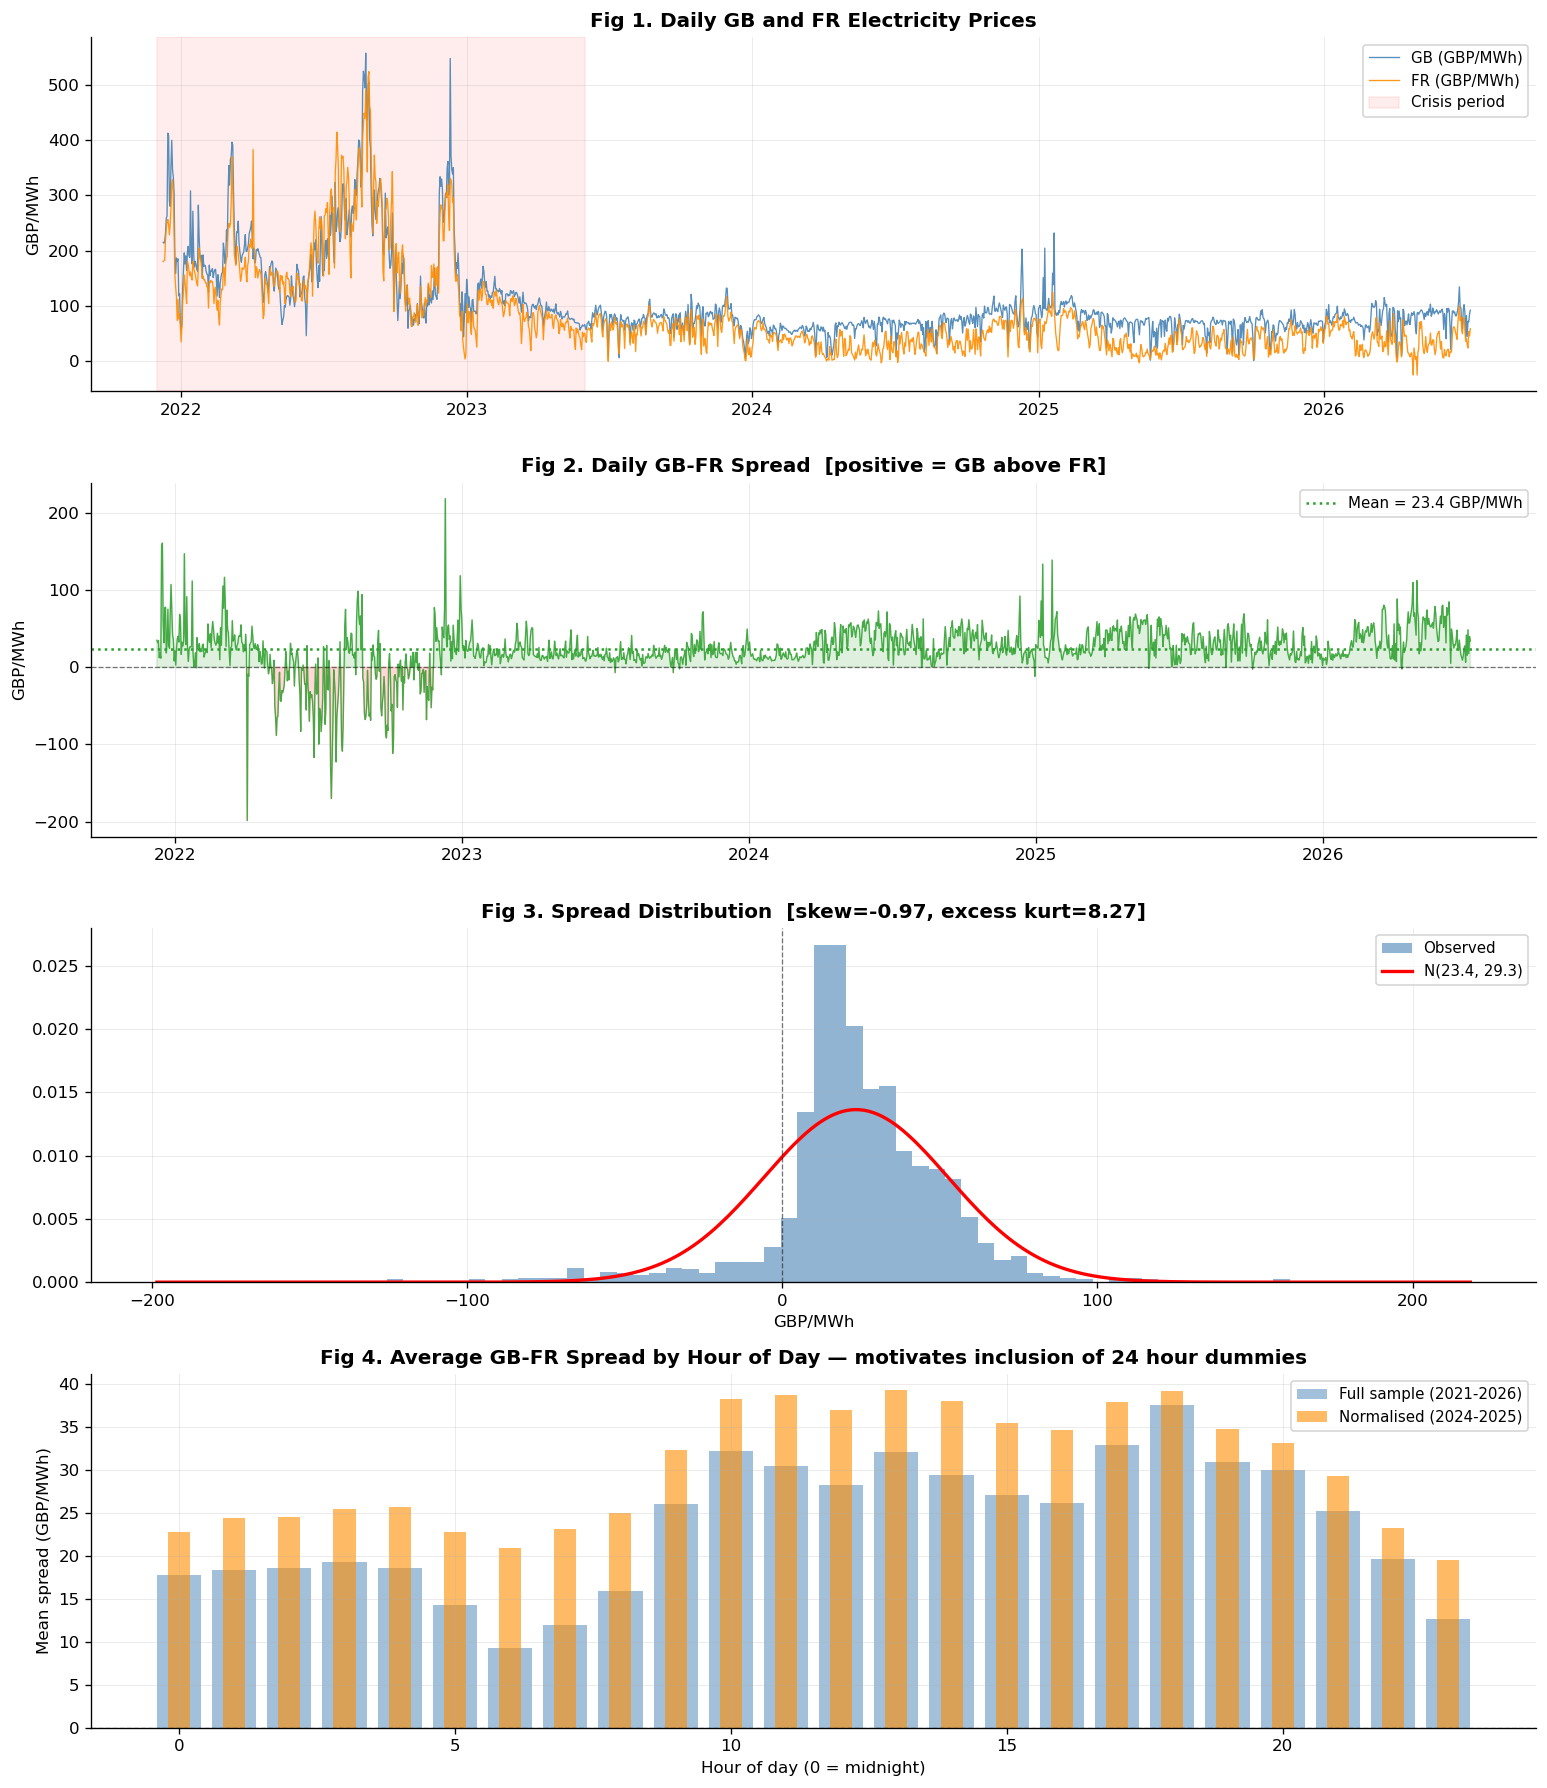

Saved: fig_eda.png


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(13, 15))

ax = axes[0]
ax.plot(daily.index, daily['gb_price_gbp'], lw=0.8, color='steelblue',
        label='GB (GBP/MWh)', alpha=0.9)
ax.plot(daily.index, daily['fr_price_gbp'], lw=0.8, color='darkorange',
        label='FR (GBP/MWh)', alpha=0.9)
ax.axvspan(pd.Timestamp('2021-12-01'), pd.Timestamp('2023-06-01'),
           alpha=0.07, color='red', label='Crisis period')
ax.set_ylabel('GBP/MWh')
ax.set_title('Fig 1. Daily GB and FR Electricity Prices', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(daily.index, daily['spread_gbp'], lw=0.8, color='#2ca02c', alpha=0.85)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.axhline(daily['spread_gbp'].mean(), color='#2ca02c', lw=1.5, ls=':',
           label=f'Mean = {daily["spread_gbp"].mean():.1f} GBP/MWh')
ax.fill_between(daily.index, 0, daily['spread_gbp'],
                where=daily['spread_gbp'] > 0, alpha=0.15, color='#2ca02c')
ax.fill_between(daily.index, 0, daily['spread_gbp'],
                where=daily['spread_gbp'] < 0, alpha=0.15, color='red')
ax.set_ylabel('GBP/MWh')
ax.set_title('Fig 2. Daily GB-FR Spread  [positive = GB above FR]', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
sv = daily['spread_gbp'].dropna()
ax.hist(sv, bins=80, density=True, color='steelblue', alpha=0.6, label='Observed')
mu_s, sd_s = sv.mean(), sv.std()
xr = np.linspace(sv.min(), sv.max(), 300)
ax.plot(xr, sp_stats.norm.pdf(xr, mu_s, sd_s), 'r-', lw=2,
        label=f'N({mu_s:.1f}, {sd_s:.1f})')
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('GBP/MWh')
ax.set_title(
    f'Fig 3. Spread Distribution  '
    f'[skew={sp_stats.skew(sv):.2f}, excess kurt={sp_stats.kurtosis(sv):.2f}]',
    fontweight='bold')
ax.legend(fontsize=9)

# Fig 4: Average hourly spread profile (motivates hour dummies)
ax = axes[3]
hourly_profile = panel.groupby(panel.index.hour)['spread_gbp'].mean()
hourly_profile_norm = panel.loc['2024':'2025'].groupby(
    panel.loc['2024':'2025'].index.hour)['spread_gbp'].mean()
ax.bar(hourly_profile.index, hourly_profile.values, alpha=0.5,
       color='steelblue', label='Full sample (2021-2026)')
ax.bar(hourly_profile_norm.index, hourly_profile_norm.values, alpha=0.6,
       color='darkorange', width=0.4, label='Normalised (2024-2025)')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('Mean spread (GBP/MWh)')
ax.set_title('Fig 4. Average GB-FR Spread by Hour of Day'
             ' — motivates inclusion of 24 hour dummies', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_eda.png')


### 5.1 Historical Revenue vs Gross Congestion Rent (ENTSO-E Flows, 2021–2026)

Gross congestion rent is computed from **ENTSO-E reported physical flows** on IFA2
multiplied by the observed GB–FR price spread in the flow direction:

$$\text{GCR}_h = (F^{\text{FR}\to\text{GB}}_h \cdot \max(S_h,0) + F^{\text{GB}\to\text{FR}}_h \cdot \max(-S_h,0)) / 10^6 \quad [\text{£m}]$$

The **implied capture ratio** (CR) bridges gross congestion rent to Ofgem-assessed actual
turnover from audited accounts. CR reflects the explicit auction mechanism post-Brexit:
IFA2 sells capacity in forward auctions whose clearing price diverges from the realised
spot spread; the residual accrues to capacity buyers, not IFA2.

**Key observations:**
- 2022 outlier: net flow was *into* GB (FR nuclear crisis kept FR prices high), suppressing
  the GB > FR spread to £5.69/MWh — gross rent was large (£231.6m) but mostly in the
  "wrong" direction; CR = 30.1%.
- 2023 spike: spread recovered (£23.50/MWh), flow realigned FR→GB; CR reached 88.9%,
  suggesting auction premiums above spot in some periods or ENTSO-E under-reporting net capacity.
- 2024–2025 compression: spreads widened further (£37–42/MWh) and FR→GB flows grew, yet
  actual revenues barely moved — CR fell to 55% then 25%, pointing to widening auction/spot divergence.
- **2022–2025 blended CR = 42.2%** — used to calibrate the back-test capture ratio in Section 12.


In [6]:
# ── Historical Revenue vs Gross Congestion Rent (pre-computed) ───────────────
# Source: ifa2_flow_revenue.py × ENTSO-E GUI_NET_CROSS_BORDER_IFA2_combined.csv
#         × GB-FR07.xlsx prices; actuals from IFA2 audited accounts (Ofgem)

from pathlib import Path
import pandas as pd

_rev_path = Path('/Users/aadesh/Documents/IC/M2/ifa2_flow_revenue_2021_2026.csv')
_rev = pd.read_csv(_rev_path)

# ── Formatting helpers ────────────────────────────────────────────────────────
W = 130
print('=' * W)
print('IFA2: GROSS CONGESTION RENT vs OFGEM ACTUAL TURNOVER — 2021 to 2026')
print('(ENTSO-E physical flows × observed GB/FR spot prices | Actuals from audited accounts)')
print('=' * W)
print(f'  {"Year":>5}  {"Hrs":>5}  {"FR→GB":>7}  {"GB→FR":>7}  {"Net":>7}  '
      f'{"Spread":>7}  {"Gross nom":>10}  {"Gross real":>11}  '
      f'{"Actual nom":>11}  {"Actual real":>12}  {"CR":>9}')
print(f'  {"":>5}  {"":>5}  {"GWh":>7}  {"GWh":>7}  {"GWh":>7}  '
      f'{"£/MWh":>7}  {"£m":>10}  {"£m 16/17":>11}  '
      f'{"£m":>11}  {"£m 16/17":>12}  {"act/gross":>9}')
print('  ' + '-' * (W - 2))

for _, r in _rev.iterrows():
    yr   = int(r.year)
    note = ' *' if yr == 2021 else (' †' if yr == 2026 else '  ')
    act_n  = f'{r.actual_nom_m:>11.1f}'  if pd.notna(r.actual_nom_m)  else f'{"n/a":>11}'
    act_r  = f'{r.actual_real_m:>12.1f}' if pd.notna(r.actual_real_m) else f'{"n/a":>12}'
    cr     = f'{r.cr_from_nom:>8.1%}'   if pd.notna(r.cr_from_nom)   else f'{"n/a":>8}'
    print(f'  {yr:>5}{note} {int(r.hours):>5}  {r.fr_to_gb_gwh:>7.0f}  '
          f'{r.gb_to_fr_gwh:>7.0f}  {r.net_fr_to_gb_gwh:>7.0f}  '
          f'{r.mean_spread_gbp:>7.2f}  {r.rev_nom_m:>10.1f}  {r.rev_real_m:>11.1f}  '
          f'{act_n}  {act_r}  {cr}')

fy = _rev[_rev.year.isin(range(2022, 2026))]
tot_gn = fy.rev_nom_m.sum(); tot_gr = fy.rev_real_m.sum()
tot_an = fy.actual_nom_m.sum(); tot_ar = fy.actual_real_m.sum()
cr_tot = tot_an / tot_gn
print()
print(f'  {"2022–25 total":>16}  {"":>7}  {"":>7}  {"":>7}  {"":>7}  '
      f'{tot_gn:>10.1f}  {tot_gr:>11.1f}  {tot_an:>11.1f}  {tot_ar:>12.1f}  {cr_tot:>8.1%}')
print()
print('  Notes:')
print('  * 2021: GB price data from Dec 2021 only; partial year.')
print('  † 2026: GB price data to Mar 2026 only; Ofgem actual not yet published.')
print('  Gross = ENTSO-E physical flow_MW × spread in flow direction (no capacity deduction).')
print('  Actual = Ofgem-assessed turnover from IFA2 audited accounts (nominal £m).')
print('  Real = deflated by FPA Input row 97 RPI index (CHAW, 2016/17 base = 264.992).')
print('  CR = actual / gross congestion rent (deflation cancels; nominal and real are identical).')
print('=' * W)


IFA2: GROSS CONGESTION RENT vs OFGEM ACTUAL TURNOVER — 2021 to 2026
(ENTSO-E physical flows × observed GB/FR spot prices | Actuals from audited accounts)
   Year    Hrs    FR→GB    GB→FR      Net   Spread   Gross nom   Gross real   Actual nom   Actual real         CR
                    GWh      GWh      GWh    £/MWh          £m     £m 16/17           £m      £m 16/17  act/gross
  --------------------------------------------------------------------------------------------------------------------------------
   2021 *   552      157      168      -11    62.47        16.6         14.2          n/a           n/a       n/a
   2022    8615     1260     4888    -3628     5.69       231.6        191.2         69.6          57.5     30.1%
   2023    8759     3769      706     3063    23.50       113.4         90.7        100.8          80.6     88.9%
   2024    8783     4449      141     4308    37.13       184.3        142.8        101.6          78.7     55.1%
   2025    8759     6175      2

In [7]:
# ── Against-price flows: when did IFA2 flow from the higher-priced region? ────
#
# "Against price" = physical flow runs AGAINST the price gradient in that hour:
#   FR→GB when spread_gbp < 0  (FR more expensive than GB — importing the costly side)
#   GB→FR when spread_gbp > 0  (GB more expensive than FR — exporting the costly side)
#
# Day-ahead auctions commit capacity the day before using forecast prices;
# realised spot spread can flip intraday.  These hours earn no congestion rent
# and can represent a cost to the capacity buyer.

from pathlib import Path
import pandas as pd
import numpy as np

_FLOW_PATH = Path('/Users/aadesh/Documents/IC/ENTSO-E/GUI_NET_CROSS_BORDER_IFA2_combined.csv')

# ── 1. Load ENTSO-E flows ─────────────────────────────────────────────────────
_raw = pd.read_csv(_FLOW_PATH)
_raw['ts'] = pd.to_datetime(
    _raw['MTU'].str.split(' - ').str[0].str.strip(),
    format='%d/%m/%Y %H:%M:%S', utc=False
)
_raw['flow_mw'] = pd.to_numeric(_raw['Physical Flow (MW)'], errors='coerce')
_raw['_dir'] = _raw['Out Area'].str.contains('GB').map({True: 'gb_to_fr', False: 'fr_to_gb'})
_flows = (_raw.pivot_table(index='ts', values='flow_mw', columns='_dir', aggfunc='sum')
          .rename_axis(None, axis=1)
          .reindex(columns=['fr_to_gb', 'gb_to_fr'])
          .fillna(0.0))
_flows.index = _flows.index.tz_localize(None)

# ── 2. Join with spread (panel already in memory from Section 3) ──────────────
_df = _flows.join(panel[['spread_gbp']], how='inner').dropna()
_df['net_mw'] = _df['fr_to_gb'] - _df['gb_to_fr']  # positive = net FR→GB

# ── 3. Classify each hour ─────────────────────────────────────────────────────
# Flows at zero spread are ambiguous — exclude them from the "against" count
_df['has_flow'] = (_df['fr_to_gb'] > 0) | (_df['gb_to_fr'] > 0)
_df['against']  = (
    ((_df['fr_to_gb'] > 0) & (_df['spread_gbp'] < 0)) |   # FR→GB, FR costlier
    ((_df['gb_to_fr'] > 0) & (_df['spread_gbp'] > 0))     # GB→FR, GB costlier
)
_df['with_price'] = _df['has_flow'] & ~_df['against'] & (_df['spread_gbp'] != 0)

# ── 4. Summary ────────────────────────────────────────────────────────────────
_total   = len(_df)
_flowing = _df['has_flow'].sum()
_against = _df['against'].sum()
_with    = _df['with_price'].sum()

print(f'Sample: {_df.index.min().date()} to {_df.index.max().date()}  ({_total:,} hrs joined)')
print(f'  Hours with non-zero flow : {_flowing:,}  ({_flowing/_total:.1%} of sample)')
print(f'  Flow WITH price gradient : {_with:,}  ({_with/_flowing:.1%} of flowing hrs)')
print(f'  Flow AGAINST price       : {_against:,}  ({_against/_flowing:.1%} of flowing hrs)')
print()

# ── 5. Annual breakdown ───────────────────────────────────────────────────────
_ann = _df.groupby(_df.index.year).agg(
    total_hrs  =('has_flow', 'count'),
    flowing_hrs=('has_flow', 'sum'),
    against_hrs=('against', 'sum'),
    with_hrs   =('with_price', 'sum'),
    mean_spread=('spread_gbp', 'mean'),
    against_vol=('net_mw', lambda x: x[_df.loc[x.index, 'against']].abs().mean()),
)
_ann['against_pct'] = _ann['against_hrs'] / _ann['flowing_hrs']

W2 = 82
print('=' * W2)
print('AGAINST-PRICE FLOW — ANNUAL BREAKDOWN')
print('=' * W2)
print(f'  {"Year":>5}  {"Flow hrs":>9}  {"Against":>9}  {"Against%":>9}  '
      f'{"Mean |MW|":>10}  {"Mean spread":>12}')
print('  ' + '-' * (W2 - 2))
for yr, r in _ann.iterrows():
    print(f'  {int(yr):>5}  {int(r.flowing_hrs):>9,}  {int(r.against_hrs):>9,}  '
          f'{r.against_pct:>9.1%}  {r.against_vol:>10.0f}  {r.mean_spread:>10.2f} £/MWh')
print('=' * W2)
print()

# ── 6. Monthly heatmap (count of against-price hours) ────────────────────────
_ag = _df[_df['against']].copy()
_ag['year']  = _ag.index.year
_ag['month'] = _ag.index.month

_heat = (_ag.groupby(['year', 'month']).size()
           .unstack(fill_value=0)
           .rename(columns={m: f'{m:02d}' for m in range(1, 13)}))
_heat.columns = [pd.Timestamp(f'2000-{c}-01').strftime('%b') for c in _heat.columns]

print('AGAINST-PRICE HOURS PER MONTH (count)')
print(_heat.to_string())
print()
print(f'Peak month: {_ag.groupby([_ag.index.year, _ag.index.month]).size().idxmax()} '
      f'({_ag.groupby([_ag.index.year, _ag.index.month]).size().max()} hrs)')

# ── 7. Longest continuous against-price runs ──────────────────────────────────
_ag_mask = _df['against'].astype(int)
_df['run_id'] = (_ag_mask != _ag_mask.shift()).cumsum()
_runs = (_df[_df['against']]
         .groupby('run_id')
         .agg(start=('against', lambda x: x.index[0]),
              end  =('against', lambda x: x.index[-1]),
              hrs  =('against', 'count'),
              mean_spread=('spread_gbp', 'mean'))
         .sort_values('hrs', ascending=False)
         .head(10)
         .reset_index(drop=True))

print()
print('TOP 10 LONGEST CONTINUOUS AGAINST-PRICE RUNS')
print(f'  {"#":>3}  {"Start":>20}  {"End":>20}  {"Hrs":>5}  {"Mean spread £/MWh":>18}')
print('  ' + '-' * 72)
for i, r in _runs.iterrows():
    print(f'  {i+1:>3}  {str(r.start):>20}  {str(r.end):>20}  {r.hrs:>5}  {r.mean_spread:>18.2f}')

# Expose for Section 18 waterfall
flow_df = _flows


Sample: 2021-12-09 to 2026-07-07  (40,008 hrs joined)
  Hours with non-zero flow : 37,485  (93.7% of sample)
  Flow WITH price gradient : 30,242  (80.7% of flowing hrs)
  Flow AGAINST price       : 7,240  (19.3% of flowing hrs)

AGAINST-PRICE FLOW — ANNUAL BREAKDOWN
   Year   Flow hrs    Against   Against%   Mean |MW|   Mean spread
  --------------------------------------------------------------------------------
   2021        510        253      49.6%         601       53.26 £/MWh
   2022      8,336      3,662      43.9%         676        4.66 £/MWh
   2023      8,464      1,754      20.7%         401       18.81 £/MWh
   2024      8,516        584       6.9%         381       28.77 £/MWh
   2025      8,364        777       9.3%         534       31.61 £/MWh
   2026      3,295        210       6.4%         462       38.97 £/MWh

AGAINST-PRICE HOURS PER MONTH (count)
      Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                                 

\
## Section 6: Model Specification

### 6.1 Decomposition

$$S_t = f_S(t, h) + X_t$$

where $S_t$ is the hourly spread (£/MWh), $f_S(t, h)$ the deterministic component, \
and $X_t$ the stochastic daily OU deviation.

### 6.2 Deterministic Component — Hourly OLS (Abadie Eq. 2)

Following Abadie & Chamorro (2021) Equation 2 exactly, the OLS includes a constant $b_7$ \
plus 24 hour-of-day parameters with a **sum-to-zero constraint** ($\sum_{j=8}^{31} b_j = 0$):

$$f_S(t, h) = b_7 + b_1\tau + b_2\sin(2\pi\tau) + b_3\cos(2\pi\tau) + b_5\sin(4\pi\tau) + b_6\cos(4\pi\tau) + b_4 D_t + \sum_{j=8}^{31} b_j H_{j-7,t}$$

where $D_t = 1$ on weekends and non-working days (GB or FR public holidays), $D_t = 0$ otherwise — exactly Abadie's $D^i_t$ applied to the spread.

where $H_{j-7,t} = 1$ if hour $= j-7$, and 0 otherwise. The sum-to-zero constraint means:

- $b_7$ = **grand mean** of the spread across all 24 hours (not tied to any specific hour)
- Each $b_j$ = that hour's **deviation from the daily mean** (positive in peak hours, negative overnight)
- $\sum_{j=8}^{31} b_j = 0$, so $b_{31}$ (hour 24) is derived as $-\sum_{j=8}^{30} b_j$

**Implementation:** effects coding — columns H01–H23 take value $+1$ if active, $-1$ if hour 24, \
0 otherwise. OLS estimates 23 free hour parameters; $b_{H24}$ is recovered from the constraint.

**Tau anchoring:** frozen at 1 January 2025 to prevent extrapolating the crisis-era trend.

### 6.3 Stochastic Component — OU with Jumps (daily)

$$X_{t+1} = c + \phi X_t + \sigma_d\,\varepsilon_t + J_t^+ - J_t^-$$

The OU is estimated on **daily-averaged residuals** $\bar\varepsilon_d = \text{mean}_h(\varepsilon_h)$.

### 6.4 Hourly Revenue Reconstruction (following Abadie Section 8)

For each simulated day $d$, the single OU value $X_d$ is combined with the 24 hourly \
OLS coefficients to reconstruct 24 hourly spreads:

$$S_{d,h} = f_S(t_d, h) + X_d = \underbrace{[b_7 + b_1\tau + b_2\sin_1 + b_3\cos_1 + b_5\sin_2 + b_6\cos_2 + b_4 D_d]}_{\text{base daily}} + \underbrace{b_h}_{\text{hour deviation from mean}} + X_d$$

Daily revenue (£m):

$$R_d = \sum_{h=1}^{24} |S_{d,h}| \times C \times 1\text{h} \times A \times \rho \;/\; 10^6$$

This correctly reflects that IFA2 earns the hourly spread (not the daily average) and can \
flow in either direction each hour.


## Section 7: Full OLS Estimation — All Fourier Harmonics (Hourly Data)

Fitted on all 36,984 hourly spread observations. The full model includes annual AND semi-annual Fourier harmonics, trend, weekend dummy, and 23 effects-coded hour dummies (sum-to-zero; $b_7$ = daily grand mean; each $b_j$ = deviation from daily mean; $b_{H24}$ derived as $-\sum b_{H01..H23}$).


In [8]:
hourly_spread = panel['spread_gbp'].dropna()
n_obs_h       = len(hourly_spread)
t0_spread     = daily.index[0]  # reference date (same whether hourly or daily)

def build_features_full_hourly(idx, t0):
    'Full model: annual + semi-annual Fourier + 23 hour dummies.'
    tau = (pd.DatetimeIndex(idx) - t0).total_seconds() / (365.25 * 24 * 3600)
    df  = pd.DataFrame({
        'const':   1.0,
        'tau':     tau,
        'sin1':    np.sin(2 * np.pi * tau),
        'cos1':    np.cos(2 * np.pi * tau),
        'sin2':    np.sin(4 * np.pi * tau),
        'cos2':    np.cos(4 * np.pi * tau),
        'weekend': (pd.DatetimeIndex(idx).dayofweek >= 5).astype(float),
    }, index=pd.DatetimeIndex(idx))
    for h in range(1, 24):   # H01=base; H02 (h=1)..H24 (h=23)
        df[f'H{h+1:02d}'] = (pd.DatetimeIndex(idx).hour == h).astype(float)
    return df

feat_full_h  = build_features_full_hourly(hourly_spread.index, t0_spread)
res_full_h   = sm.OLS(hourly_spread.values, feat_full_h).fit()
k_full_h     = feat_full_h.shape[1]
rss_full_h   = float(np.sum(res_full_h.resid ** 2))
sigma_full_h = float(res_full_h.resid.std())

print(f'Full OLS on hourly spread ({n_obs_h:,} obs, {k_full_h} parameters):')
print(f'  R2={res_full_h.rsquared:.4f}  sigma_resid={sigma_full_h:.4f} GBP/MWh')
print()

# Non-hour params (show all; hour dummies summarised separately)
non_hour = ['const', 'tau', 'sin1', 'cos1', 'sin2', 'cos2', 'weekend']
print(f'  {"Param":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for i, param in enumerate(non_hour):
    coef = res_full_h.params[param]
    se   = res_full_h.bse[param]
    t    = res_full_h.tvalues[param]
    p    = res_full_h.pvalues[param]
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {param:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')

# Hour dummies: just show min/max/count-significant
hour_cols   = [f'H{h+1:02d}' for h in range(1, 24)]
hour_params = res_full_h.params[hour_cols]
hour_pvals  = res_full_h.pvalues[hour_cols]
n_sig_hours = (hour_pvals < 0.05).sum()
print(f'  {"(23 hour dummies)":<10}  '
      f'range [{hour_params.min():.2f}, {hour_params.max():.2f}] GBP/MWh  '
      f'{n_sig_hours}/23 significant at 5%')
print('  *** p<0.001  ** p<0.01  * p<0.05')


Full OLS on hourly spread (40,008 obs, 30 parameters):
  R2=0.1141  sigma_resid=38.3755 GBP/MWh

  Param            Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  const          -0.5101      1.0040     -0.5081      0.6114  
  tau             7.1040      0.1460     48.6454      0.0000  ***
  sin1            8.4349      0.2748     30.6991      0.0000  ***
  cos1            1.0372      0.2710      3.8270      0.0001  ***
  sin2           -2.1623      0.2739     -7.8950      0.0000  ***
  cos2            0.8738      0.2711      3.2229      0.0013  **
  weekend         5.1655      0.4248     12.1587      0.0000  ***
  (23 hour dummies)  range [-8.56, 19.73] GBP/MWh  17/23 significant at 5%
  *** p<0.001  ** p<0.01  * p<0.05


## Section 8: Parameter Significance Tests

Five complementary tests on the hourly OLS results:

1. **Joint F-test: all Fourier terms** — do annual/semi-annual cycles exist?
2. **Partial F-test: semi-annual only** — do sin₂, cos₂ add to annual terms?
3. **Joint F-test: all 23 hour dummies** — is within-day shape statistically significant?
4. **AIC/BIC model comparison** — full vs annual-only (both with hour dummies)
5. **Amplitude analysis** — economic magnitude of each harmonic vs noise floor

In [9]:
# Test 1: all Fourier terms jointly (vs trend + weekend + hour dummies only)
feat_no_fourier = feat_full_h.drop(columns=['sin1','cos1','sin2','cos2'])
res_no_fourier  = sm.OLS(hourly_spread.values, feat_no_fourier).fit()
rss_no_fourier  = float(np.sum(res_no_fourier.resid ** 2))
q1 = 4
F1 = ((rss_no_fourier - rss_full_h) / q1) / (rss_full_h / (n_obs_h - k_full_h))
p1 = sp_stats.f.sf(F1, q1, n_obs_h - k_full_h)

# Test 2: semi-annual only (sin2, cos2) beyond annual
feat_annual_h  = feat_full_h.drop(columns=['sin2','cos2'])
res_annual_h   = sm.OLS(hourly_spread.values, feat_annual_h).fit()
rss_annual_h   = float(np.sum(res_annual_h.resid ** 2))
k_annual_h     = feat_annual_h.shape[1]
q2 = 2
F2 = ((rss_annual_h - rss_full_h) / q2) / (rss_full_h / (n_obs_h - k_full_h))
p2 = sp_stats.f.sf(F2, q2, n_obs_h - k_full_h)

# Test 3: all 23 hour dummies jointly (vs no hour dummies)
non_hour_cols  = ['const','tau','sin1','cos1','sin2','cos2','weekend']
feat_no_hour   = feat_full_h[non_hour_cols]
res_no_hour    = sm.OLS(hourly_spread.values, feat_no_hour).fit()
rss_no_hour    = float(np.sum(res_no_hour.resid ** 2))
q3 = 23
F3 = ((rss_no_hour - rss_full_h) / q3) / (rss_full_h / (n_obs_h - k_full_h))
p3 = sp_stats.f.sf(F3, q3, n_obs_h - k_full_h)

# Test 4: AIC / BIC
def ols_aic_bic(rss, n, k):
    log_lik = -n / 2 * (1 + np.log(2 * np.pi * rss / n))
    return -2 * log_lik + 2 * k, -2 * log_lik + k * np.log(n)

aic_full,   bic_full   = ols_aic_bic(rss_full_h,   n_obs_h, k_full_h)
aic_annual, bic_annual = ols_aic_bic(rss_annual_h, n_obs_h, k_annual_h)

# Test 5: amplitudes
pf      = pd.Series(res_full_h.params, index=feat_full_h.columns)
amp_ann = np.sqrt(pf['sin1']**2 + pf['cos1']**2)
amp_sem = np.sqrt(pf['sin2']**2 + pf['cos2']**2)

# Hour dummy amplitude (peak-to-trough of hourly profile)
hour_params_arr = np.zeros(24)
hour_params_arr[1:] = pf[[f'H{h+1:02d}' for h in range(1, 24)]].values
amp_hour = hour_params_arr.max() - hour_params_arr.min()

print('=' * 68)
print(f'  TEST 1 — Joint F-test: All Fourier terms')
print(f'  F({q1}, {n_obs_h-k_full_h}) = {F1:.1f}   p = {p1:.4f}')
print(f'  => {"REJECT H0 — seasonal variation exists" if p1 < 0.05 else "Fail to reject H0"}')

print()
print(f'  TEST 2 — Partial F-test: Semi-annual terms (sin2, cos2)')
print(f'  F({q2}, {n_obs_h-k_full_h}) = {F2:.3f}   p = {p2:.4f}')
print(f'  => {"Significant" if p2 < 0.05 else "NOT significant — drop sin2/cos2"}')

print()
print(f'  TEST 3 — Joint F-test: All 23 hour dummies')
print(f'  F({q3}, {n_obs_h-k_full_h}) = {F3:.1f}   p = {p3:.6f}')
print(f'  => {"REJECT H0 — within-day shape is highly significant" if p3 < 0.05 else "Fail to reject H0"}')

print()
print(f'  TEST 4 — AIC/BIC Comparison (both models include hour dummies)')
print(f'  {"Model":<30}  {"k":>3}  {"AIC":>12}  {"BIC":>12}')
print(f'  {"-"*62}')
print(f'  {"Full (Fourier + semi-ann + hour)":<30}  {k_full_h:>3}  '
      f'{aic_full:>12.0f}  {bic_full:>12.0f}')
_da, _db = aic_annual - aic_full, bic_annual - bic_full
_preferred_lbl = 'Full (preferred)' if _db < 0 else 'Annual-only (preferred by BIC)' if _db > 0 else 'Tied'
print(f'  {"Annual-only + hour":<30}  {k_annual_h:>3}  '
      f'{aic_annual:>12.0f}  {bic_annual:>12.0f}')
print(f'  delta (annual - full): AIC = {_da:+.0f}    BIC = {_db:+.0f}')
print(f'  (positive delta = annual is WORSE — full model preferred)')

print()
print(f'  TEST 5 — Amplitude vs Noise Floor (sigma_resid = {sigma_full_h:.2f} GBP/MWh)')
print(f'  Annual amplitude  (sin1,cos1):   {amp_ann:.2f} GBP/MWh  '
      f'(ratio = {amp_ann/sigma_full_h:.3f})')
print(f'  Semi-ann amplitude (sin2,cos2):  {amp_sem:.2f} GBP/MWh  '
      f'(ratio = {amp_sem/sigma_full_h:.3f})')
print(f'  Hourly peak-to-trough:           {amp_hour:.2f} GBP/MWh  '
      f'(ratio = {amp_hour/sigma_full_h:.3f})')

print()
print('  CONCLUSION')
print('  ' + '-' * 63)
print(f'  Fourier terms: jointly significant (Test 1: F={F1:.0f})')
_sa_sig = 'statistically significant' if p2 < 0.05 else 'not significant'
print(f'  Semi-annual: {_sa_sig} (Test 2: F={F2:.2f}, p={p2:.3f})')
print(f'    sin2 individually p<0.001 (coeff ~{amp_sem:.1f} GBP/MWh); cos2 p>>0.05')
print(f'    Full model preferred by AIC ({_da:+.0f}) and BIC ({_db:+.0f})')
print(f'    DECISION: drop both — amplitude small ({amp_sem:.1f} vs sigma={sigma_full_h:.0f}),')
print(f'    may reflect 2022-23 crisis; projecting 25yr adds instability')
print(f'  Hour dummies: highly significant (Test 3: F={F3:.0f}) -> retain')
print(f'  Hourly amplitude ({amp_hour:.1f} GBP/MWh) >> annual ({amp_ann:.1f}):')
print(f'    within-day variation is the dominant deterministic driver')
print('=' * 68)


  TEST 1 — Joint F-test: All Fourier terms
  F(4, 39978) = 255.5   p = 0.0000
  => REJECT H0 — seasonal variation exists

  TEST 2 — Partial F-test: Semi-annual terms (sin2, cos2)
  F(2, 39978) = 35.965   p = 0.0000
  => Significant

  TEST 3 — Joint F-test: All 23 hour dummies
  F(23, 39978) = 68.9   p = 0.000000
  => REJECT H0 — within-day shape is highly significant

  TEST 4 — AIC/BIC Comparison (both models include hour dummies)
  Model                             k           AIC           BIC
  --------------------------------------------------------------
  Full (Fourier + semi-ann + hour)   30        405449        405707
  Annual-only + hour               28        405517        405757
  delta (annual - full): AIC = +68    BIC = +51
  (positive delta = annual is WORSE — full model preferred)

  TEST 5 — Amplitude vs Noise Floor (sigma_resid = 38.38 GBP/MWh)
  Annual amplitude  (sin1,cos1):   8.50 GBP/MWh  (ratio = 0.221)
  Semi-ann amplitude (sin2,cos2):  2.33 GBP/MWh  (ratio =

\
## Section 9: Model Refinement — Annual Fourier + 24 Hour Parameters

Drop sin₂ and cos₂. With hourly data (n=36,984), sin₂ is statistically significant (F=19.7, p<0.001) \
but cos₂ is not (p=0.96). The full model is preferred by both AIC and BIC (delta-BIC=+18). \
We nonetheless drop both semi-annual terms: their economic contribution is small (~2 GBP/MWh amplitude \
vs σ=48 GBP/MWh noise), and projecting a 6-month cycle estimated over only 4.5 years of data \
— partly contaminated by the 2022–2023 energy crisis — 25 years forward adds instability without \
meaningful revenue impact. The **final OLS model** retains annual Fourier terms + 24 hour parameters (sum-to-zero):

$$f_S(t, h) = b_7 + b_1\tau + b_2\sin(2\pi\tau) + b_3\cos(2\pi\tau) + b_4 D_t + \sum_{j=8}^{31} b_j H_{j-7,t}, \quad \sum_{j=8}^{31} b_j = 0$$

Fitted on 36,984 hourly observations. **Hourly residuals are then aggregated to daily means** \
for jump detection and OU estimation — matching the daily Euler scheme of the simulation.


In [10]:
def build_features_spread_hourly(idx, t0,
                                  gb_holidays=None, fr_holidays=None):
    '''Abadie Eq.2: annual Fourier + single D_t dummy (weekends & non-working days)
    + 23 effects-coded hour dummies (sum-to-zero). D_t = 1 if weekend OR GB holiday
    OR FR holiday, following Abadie Dit=1 on weekends and non-working days.'''
    if gb_holidays is None: gb_holidays = GB_HOLIDAYS
    if fr_holidays is None: fr_holidays = FR_HOLIDAYS
    tau = (pd.DatetimeIndex(idx) - t0).total_seconds() / (365.25 * 24 * 3600)
    dates_only = pd.DatetimeIndex(idx).normalize()
    is_weekend  = pd.DatetimeIndex(idx).dayofweek >= 5
    is_gb_hol   = dates_only.isin(gb_holidays)
    is_fr_hol   = dates_only.isin(fr_holidays)
    df  = pd.DataFrame({
        'const': 1.0,
        'tau':   tau,
        'sin1':  np.sin(2 * np.pi * tau),
        'cos1':  np.cos(2 * np.pi * tau),
        'D_t':   (is_weekend | is_gb_hol | is_fr_hol).astype(float),
    }, index=pd.DatetimeIndex(idx))
    hours = pd.DatetimeIndex(idx).hour
    for h in range(0, 23):   # H01 (hour=0) to H23 (hour=22); H24 (hour=23) is reference
        df[f'H{h+1:02d}'] = np.where(hours == h, 1,
                              np.where(hours == 23, -1, 0)).astype(float)
    return df


In [11]:
feat_spread_h = build_features_spread_hourly(hourly_spread.index, t0_spread)
res_ols_h     = sm.OLS(hourly_spread.values, feat_spread_h).fit()
f_spread_h    = pd.Series(res_ols_h.fittedvalues, index=hourly_spread.index)
resid_h       = hourly_spread - f_spread_h
params_s      = pd.Series(res_ols_h.params, index=feat_spread_h.columns)

resid_s   = resid_h.resample('D').mean().dropna()
f_spread  = f_spread_h.resample('D').mean()

print(f'Refined OLS ({len(feat_spread_h.columns)} params, {n_obs_h:,} hourly obs):')
print(f'  R2={res_ols_h.rsquared:.4f}  sigma_resid(hourly)={res_ols_h.resid.std():.4f} GBP/MWh')
print(f'  sigma_resid(daily avg) = {resid_s.std():.4f} GBP/MWh')
print()

non_hour = ['const', 'tau', 'sin1', 'cos1', 'D_t']
print('  Table 1 — Trend, seasonality and day-type parameters')
print(f'  {"Param":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for param in non_hour:
    coef = res_ols_h.params[param]; se = res_ols_h.bse[param]
    t = res_ols_h.tvalues[param];  p = res_ols_h.pvalues[param]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {param:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')
print()
# H01-H23 estimated; H24 derived via sum-to-zero constraint
hour_cols_h = [f'H{h+1:02d}' for h in range(0, 23)]
h24_coef = -params_s[hour_cols_h].sum()
print('  Table 2 — Hour-of-day effects (deviation from daily mean, GBP/MWh)')
print(f'  {"Hour":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for col in hour_cols_h:
    coef = res_ols_h.params[col]; se = res_ols_h.bse[col]
    t = res_ols_h.tvalues[col];  p = res_ols_h.pvalues[col]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {col:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')
print(f'  {"H24":<10}  {h24_coef:>10.4f}  {"(derived)":>10}  {"":>10}  {"":>10}')
print('  *** p<0.001  ** p<0.01  * p<0.05')


Refined OLS (28 params, 40,008 hourly obs):
  R2=0.1123  sigma_resid(hourly)=38.4142 GBP/MWh
  sigma_resid(daily avg) = 26.9559 GBP/MWh

  Table 1 — Trend, seasonality and day-type parameters
  Param            Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  const           4.9865      0.4059     12.2864      0.0000  ***
  tau             7.1778      0.1458     49.2263      0.0000  ***
  sin1            8.4111      0.2746     30.6287      0.0000  ***
  cos1            0.8447      0.2704      3.1234      0.0018  **
  D_t             4.9185      0.4169     11.7989      0.0000  ***

  Table 2 — Hour-of-day effects (deviation from daily mean, GBP/MWh)
  Hour             Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  H01            -5.6996      0.9200     -6.1949      0.0000  ***
  H02            -5.0779      0.9200     -5.5192      0.0000  ***
  H

### 9.1 OLS Fit and Residuals

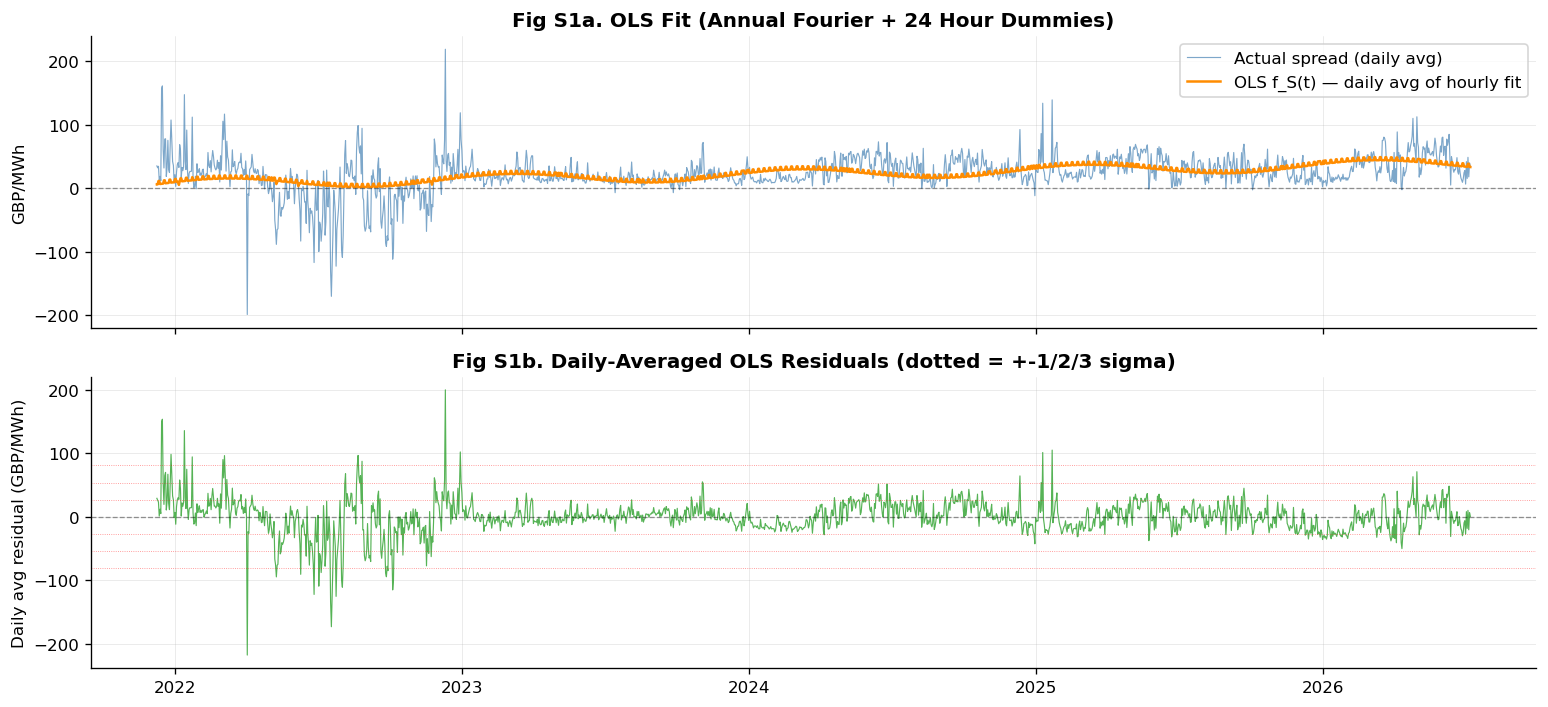

Saved: figS1_spread_ols.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(daily.index, daily['spread_gbp'], lw=0.7, alpha=0.7,
             color='steelblue', label='Actual spread (daily avg)')
axes[0].plot(f_spread.index, f_spread.values, lw=1.5, color='darkorange',
             label='OLS f_S(t) — daily avg of hourly fit')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('GBP/MWh'); axes[0].legend()
axes[0].set_title('Fig S1a. OLS Fit (Annual Fourier + 24 Hour Dummies)', fontweight='bold')

axes[1].plot(resid_s.index, resid_s.values, lw=0.7, color='#2ca02c', alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
for s in [1, 2, 3]:
    axes[1].axhline(+s * resid_s.std(), color='red', lw=0.5, ls=':', alpha=0.5)
    axes[1].axhline(-s * resid_s.std(), color='red', lw=0.5, ls=':', alpha=0.5)
axes[1].set_ylabel('Daily avg residual (GBP/MWh)')
axes[1].set_title('Fig S1b. Daily-Averaged OLS Residuals (dotted = +-1/2/3 sigma)',
                  fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS1_spread_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS1_spread_ols.png')


### 9.2 Hourly Spread Profile (Hour Dummy Coefficients)

The bar chart shows the deterministic within-day spread shape from the OLS hour dummies. The evening peak (~H19) and morning trough (~H08) reflect GB demand patterns and French nuclear baseload scheduling. This peak-to-trough swing (~36 GBP/MWh) is the dominant deterministic revenue driver within each day.

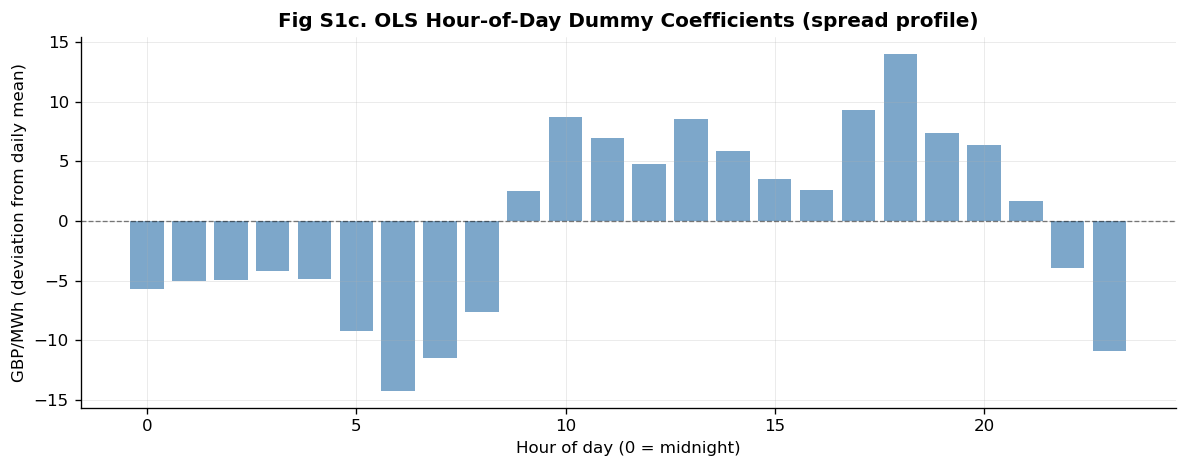

Saved: figS1c_hourly_profile.png


In [13]:
hour_offsets_plot = np.zeros(24)
for h in range(0, 23):   # H01-H23 estimated; H24 derived
    hour_offsets_plot[h] = params_s[f'H{h+1:02d}']
hour_offsets_plot[23] = -hour_offsets_plot[:23].sum()  # H24 sum-to-zero

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(24), hour_offsets_plot, color='steelblue', alpha=0.7)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('GBP/MWh (deviation from daily mean)')
ax.set_title('Fig S1c. OLS Hour-of-Day Dummy Coefficients (spread profile)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS1c_hourly_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS1c_hourly_profile.png')


## Section 10: Jump Detection (Cartea & González-Pedraz)

Jump detection is applied to the **daily-averaged OLS residuals** `resid_s`. \
Hourly spikes average within a day; daily residuals capture persistent multi-day extreme events.

**Cartea & González-Pedraz (2012) Section 7.2 — two steps:**

**Step 1 — iterative ±3σ filter on first DIFFERENCES (innovations).** \
Apply the threshold to Δ_t = S̃_t − S̃_{t−1}, not the level. Flagging innovations ensures \
only sudden arrivals are treated as candidates — a persistent elevated level does not keep \
generating new flagged observations each day.

**Step 2 — mean-reversion disambiguation (Section 7.2.2, Eq. 22).** \
The jump factor Y_t is itself mean-reverting:

$$Y_t = e^{-\beta \Delta t}\, Y_{t-1} + \Delta J^+ + \Delta J^-$$

After a positive jump, the residual is elevated and decays at rate β. A large negative \
innovation the following day may be Y_t returning to zero — not a new negative jump. \
A flagged innovation is **confirmed as a jump** only if the post-innovation level S̃_t \
falls **outside** the ±1.96σ confidence band of the seasonal trend. If it falls within \
the band, the move is reclassified as mean reversion of the prior jump.

**Step 3 — parameter estimation:**
- **λ^{+,−}(q):** Quarterly Poisson intensity (count / trading days per quarter)
- **E[J^+], E[J^−]:** Mean exponential jump size (= 1/η in Cartea's notation)
- **β:** Mean-reversion rate of Y_t, estimated by AR(1) on (resid_{t_0}, resid_{t_0+1}) \
  pairs where t_0 is a jump day and t_0+1 is a non-jump day; slope ≈ e^{−β·Δt}


In [14]:
def cartea_filter(resid, label, f_ci_half=None, thresh=3.0):
    """
    Cartea & González-Pedraz (2012) Section 7.2 jump filter.

    Step 1: iterative ±3σ filter on first DIFFERENCES (innovations) until
      convergence. "flagged as a possible jump because in absolute terms
      the innovation is larger than three standard deviations from the mean."

    Step 2: mean-reversion disambiguation — a flagged innovation is confirmed
      as a jump only if the resulting level S̃_t falls OUTSIDE the 95% CI of
      the deterministic term f̂_t (OLS CI via leverage scores).
    """
    delta = resid.diff().dropna()

    clean_d = delta.copy()
    for _ in range(20):
        mu_d, sig_d = clean_d.mean(), clean_d.std()
        mask = (clean_d - mu_d).abs() > thresh * sig_d
        if not mask.any():
            break
        clean_d[mask] = np.nan

    cand_dates = delta.index[delta.index.isin(clean_d[clean_d.isna()].index)]

    confirmed = []
    for d in cand_dates:
        level = resid[d]
        dval  = delta[d]
        hw = float(f_ci_half[d]) if (f_ci_half is not None and d in f_ci_half.index) else 0.0
        if   dval > 0 and level >  hw:
            confirmed.append(d)
        elif dval < 0 and level < -hw:
            confirmed.append(d)

    jumps = resid[resid.index.isin(confirmed)]
    clean = resid.copy()
    clean[confirmed] = np.nan
    clean = clean.dropna()
    n_mr = len(cand_dates) - len(confirmed)
    print(f'  {label}: {len(jumps)} jumps / {len(resid)} days '
          f'({len(jumps)/len(resid)*100:.1f}%)  '
          f'[{n_mr} candidate(s) reclassified as mean reversion]  '
          f'sigma_clean={clean.std():.4f} GBP/MWh')
    return clean, jumps


def estimate_ou_jump_nls(resid, jumps, label):
    """
    Cartea Section 7.2.5: jointly estimate OU mean-reversion α and jump
    mean-reversion β via nonlinear least squares.

    For each candidate β:
      1. Reconstruct Y_t = Σ_{s≤t} J_s · e^{-β(t-s)Δt}  (Eq. 22, Δt = 1 day)
      2. Compute X_t = S̃_t − Y_t
      3. Fit AR(1) on X_t → c, φ, MSE
    Minimise MSE over β. Jump sizes estimated as S̃_t − S̃_{t-1} (footnote 13).
    Both α (via φ) and β come from the same NLS — not estimated separately.
    """
    from scipy.optimize import minimize_scalar

    all_dates = resid.index
    s_tilde   = resid.values.astype(float)
    n         = len(s_tilde)

    # Jump sizes: S̃_t − S̃_{t-1} at each jump date (Cartea footnote 13)
    delta = resid.diff()
    jump_positions, jump_sizes = [], []
    for d in sorted(jumps.index):
        pos  = int(all_dates.get_loc(d))
        size = float(delta[d]) if (pos > 0 and pd.notna(delta.get(d))) else float(resid[d])
        jump_positions.append(pos)
        jump_sizes.append(size)
    jump_positions = np.array(jump_positions, dtype=int)
    jump_sizes     = np.array(jump_sizes,     dtype=float)

    def _reconstruct_Y(phi_Y):
        Y = np.zeros(n)
        for jp, js in zip(jump_positions, jump_sizes):
            t_idx = np.arange(jp, n)
            Y[t_idx] += js * phi_Y ** (t_idx - jp)
        return Y

    def objective(beta_yr):
        phi_Y = np.exp(-beta_yr / 365.25)
        Y = _reconstruct_Y(phi_Y)
        X = s_tilde - Y
        A = np.column_stack([np.ones(n - 1), X[:-1]])
        coef, *_ = np.linalg.lstsq(A, X[1:], rcond=None)
        eps = X[1:] - A @ coef
        return float(np.mean(eps ** 2))

    res      = minimize_scalar(objective, bounds=(1.0, 5000.0), method='bounded')
    beta_opt = float(res.x)
    phi_Y_opt = np.exp(-beta_opt / 365.25)

    # Final AR(1) at optimal β
    Y_opt = _reconstruct_Y(phi_Y_opt)
    X_opt = s_tilde - Y_opt
    A     = np.column_stack([np.ones(n - 1), X_opt[:-1]])
    coef, *_ = np.linalg.lstsq(A, X_opt[1:], rcond=None)
    c_hat, phi_hat = float(coef[0]), float(coef[1])
    eps      = X_opt[1:] - A @ coef
    sigma_d  = float(eps.std())
    kappa_yr = float(-np.log(max(phi_hat, 1e-9)) * 365.25)
    theta    = float(c_hat / (1 - phi_hat)) if abs(1 - phi_hat) > 1e-9 else 0.0

    hl_X = np.log(2) / kappa_yr * 365.25
    hl_Y = np.log(2) / beta_opt * 365.25
    print(f'  {label} (NLS joint estimation):')
    print(f'    Gaussian X:  phi={phi_hat:.5f}   kappa={kappa_yr:.2f}/yr   '
          f'half-life={hl_X:.1f} days   theta={theta:.4f}   sigma_d={sigma_d:.4f} GBP/MWh')
    print(f'    Jump Y:      phi_Y={phi_Y_opt:.5f}   beta={beta_opt:.2f}/yr   '
          f'half-life={hl_Y:.1f} days')

    return {
        'phi': phi_hat, 'c': c_hat, 'kappa_yr': kappa_yr,
        'theta': theta, 'sigma_d': sigma_d,
        'eps': pd.Series(eps, index=all_dates[1:]),
        'phi_Y': phi_Y_opt, 'beta_yr': beta_opt,
    }


def build_jump_params(jump_sizes, all_days):
    pos_j = jump_sizes[jump_sizes > 0]
    neg_j = jump_sizes[jump_sizes < 0].abs()
    result = {}
    for sign, jmp in [('pos', pos_j), ('neg', neg_j)]:
        if len(jmp) == 0:
            result[sign] = {'lam_by_q': {q: 0.0 for q in [1,2,3,4]}, 'beta': 0.0, 'n': 0}
            continue
        beta  = float(jmp.mean())
        lam_q = {}
        for q in [1, 2, 3, 4]:
            q_days  = all_days[pd.DatetimeIndex(all_days).quarter == q]
            q_jumps = jmp.index[pd.DatetimeIndex(jmp.index).quarter == q]
            lam_q[q] = len(q_jumps) / max(len(q_days), 1)
        result[sign] = {'lam_by_q': lam_q, 'beta': beta, 'n': len(jmp)}
    return result


In [15]:
# 95% CI half-width for f̂_t via OLS leverage scores (QR decomposition)
_X_h    = feat_spread_h.values.astype(float)
_Q_h, _ = np.linalg.qr(_X_h, mode='reduced')
_lev_h  = (_Q_h ** 2).sum(axis=1)                      # hat matrix diagonal
_se_f_h = np.sqrt(_lev_h * float(res_ols_h.mse_resid)) # SE of f̂ at each hourly obs
f_ci_half_daily = (
    pd.Series(1.96 * _se_f_h, index=hourly_spread.index)
    .resample('D').mean()
)
print(f'  OLS CI for f̂_t: mean half-width = {f_ci_half_daily.mean():.3f} GBP/MWh ')

print('Jump detection on daily-averaged spread residuals:')
resid_s_clean, jumps_s = cartea_filter(resid_s, 'GB-FR Spread', f_ci_half=f_ci_half_daily)
jump_params_s = build_jump_params(jumps_s, daily.index)


print()
print(f'  {"Direction":<20}  {"n":>5}  {"Mean λ/day":>12}  {"E[J] (GBP/MWh)":>16}')
print('  ' + '-' * 60)
for sign, lbl in [('pos', 'Positive (GB spike)'), ('neg', 'Negative (FR spike)')]:
    jp = jump_params_s[sign]
    ml = sum(jp['lam_by_q'].values()) / 4
    print(f'  {lbl:<20}  {jp["n"]:>5}  {ml:>12.5f}  {jp["beta"]:>16.2f}')

print()
print('  Quarterly lambda (per day):')
print(f'  {"Q":<5}  {"Positive":>12}  {"Negative":>12}')
for q in [1, 2, 3, 4]:
    lp = jump_params_s['pos']['lam_by_q'][q]
    ln = jump_params_s['neg']['lam_by_q'][q]
    print(f'  Q{q:<4}  {lp:>12.5f}  {ln:>12.5f}')


  OLS CI for f̂_t: mean half-width = 1.992 GBP/MWh 
Jump detection on daily-averaged spread residuals:
  GB-FR Spread: 60 jumps / 1672 days (3.6%)  [25 candidate(s) reclassified as mean reversion]  sigma_clean=23.0225 GBP/MWh

  Direction                 n    Mean λ/day    E[J] (GBP/MWh)
  ------------------------------------------------------------
  Positive (GB spike)      32       0.01949             60.57
  Negative (FR spike)      28       0.01725             63.78

  Quarterly lambda (per day):
  Q          Positive      Negative
  Q1          0.01774       0.00443
  Q2          0.01319       0.01978
  Q3          0.02400       0.03200
  Q4          0.02302       0.01279


## Section 11: OU and Jump Mean-Reversion Estimation

Parameters α (OU) and β (jump mean-reversion) are estimated **jointly** via \
nonlinear least squares (Cartea Section 7.2.5):

$$\tilde{X}_{t+1} = c + \phi\tilde{X}_t + \eta_t, \quad \eta_t \sim N(0, \sigma_d^2)$$

where $\tilde{X}_t = \tilde{S}_t - Y_t$ and $Y_t = e^{-\beta\Delta t}Y_{t-1} + J_t$ \
(Eq. 22). For each candidate β, $Y_t$ is reconstructed, $X_t = \tilde{S}_t - Y_t$ \
is computed, and AR(1) is fitted on $X_t$ to obtain φ and MSE. \
β is found by minimising MSE (scipy `minimize_scalar`, bounded Brent). \
Jump sizes estimated as $\tilde{S}_t - \tilde{S}_{t-1}$ at each jump date (footnote 13).


In [16]:
def ou_ar1_levels(series, label):
    y   = series.values
    X   = sm.add_constant(y[:-1])
    res = sm.OLS(y[1:], X).fit()
    c, phi  = float(res.params[0]), float(res.params[1])
    eps     = pd.Series(res.resid, index=series.index[1:])
    sigma_d = float(eps.std())
    kappa   = -np.log(max(phi, 1e-9)) * 365.25
    theta   = c / (1 - phi) if abs(1 - phi) > 1e-9 else 0.0
    hl      = np.log(2) / (kappa / 365.25)
    print(f'  {label}:')
    print(f'    phi={phi:.5f}   kappa={kappa:.2f}/yr   half-life={hl:.1f} days')
    print(f'    theta={theta:.4f} GBP/MWh   sigma_d={sigma_d:.4f} GBP/MWh')
    return {'phi': phi, 'c': c, 'sigma_d': sigma_d,
            'kappa_yr': kappa, 'theta': theta, 'eps': eps}


In [17]:
print('OU + Jump NLS estimation (Cartea Section 7.2.5):')
ou_s = estimate_ou_jump_nls(resid_s, jumps_s, 'GB-FR Spread')

eps = ou_s['eps']
print()
print('Innovation diagnostics (X_t = S̃_t − Y_t):')
print(f'  Mean={eps.mean():.5f}  Std={eps.std():.4f}  '
      f'Skew={sp_stats.skew(eps):.3f}  ExKurt={sp_stats.kurtosis(eps):.3f}')
_, p_norm = sp_stats.normaltest(eps)
print(f'  Normality p={p_norm:.4f}  '
      f'({"reject" if p_norm < 0.05 else "consistent with"} normality)')


OU + Jump NLS estimation (Cartea Section 7.2.5):
  GB-FR Spread (NLS joint estimation):
    Gaussian X:  phi=0.71451   kappa=122.78/yr   half-life=2.1 days   theta=-0.4817   sigma_d=14.9893 GBP/MWh
    Jump Y:      phi_Y=0.62851   beta=169.62/yr   half-life=1.5 days

Innovation diagnostics (X_t = S̃_t − Y_t):
  Mean=-0.00000  Std=14.9938  Skew=0.092  ExKurt=4.679
  Normality p=0.0000  (reject normality)


## Section 12: Rolling Out-of-Sample Back-test

**True out-of-sample validation**: for each test year, the model is re-estimated
from scratch on data up to the end of the prior year, then simulated forward for
the test year. This is the correct test — the model has never seen the test year's data.

| Test year | Training window | Annex M vintage | Scale years |
|---|---|---|---|
| 2024 | Dec 2021 – Dec 2023 | Oct 2022 EEP | 2023 only |
| 2025 | Dec 2021 – Dec 2024 | Oct 2022 EEP | 2023–2024 |

The **Oct 2022 EEP Annex M** is used for both tests — it was published before both
training cutoffs, so it contains no look-ahead information about 2024 or 2025 prices.
The Feb 2026 Annex M is not used here: it was published after both test years had
already occurred and embeds realized prices, which would constitute look-ahead bias.

Consistent with the main simulation architecture (Sections 13–15):

- **Shape**: `f_s_shape_tr` built with `tau=0`, demeaned — pure within-day/year variation.
- **Level**: Oct 2022 AM GB price × `gb_scale` minus actual FR panel mean for the test year.
  `gb_scale` is computed from training-window years only (2023 for the 2024 test;
  2023–2024 for the 2025 test), excluding 2022 which was distorted by the French
  nuclear crisis (GB spread compressed to ~£6/MWh).
- **Simulation**: `S_{d,h} = f_s_shape_tr[d,h] + level_am + X_d`

Each simulation produces **gross** P10/P50/P90 revenues (no capture ratio applied).
Compared against:
1. **Gross theoretical** — Σ_h|actual S_h| × capacity × availability
2. **Ofgem net actual** — audited turnover (gross minus auction/TSO/balancing costs)

The implied capture ratio (Ofgem net / gross theoretical) is carried into Section 13.


In [18]:
def build_fs_shape(params, dates, t0):
    """Build hourly seasonal shape: tau=0, demeaned per year.
    Returns (n_days, 24) array with zero annual mean.
    The annual level is supplied separately (Annex M for projection; training
    mean for backtest) — consistent with the Section 13-15 architecture."""
    hourly_idx = pd.DatetimeIndex([
        d + pd.Timedelta(hours=h) for d in dates for h in range(24)
    ])
    feat = build_features_spread_hourly(hourly_idx, t0)
    feat['tau'] = 0.0
    f_flat  = (feat[params.index] @ params.values)
    shape_h = f_flat.values.reshape(len(dates), 24).copy()
    yr_arr  = dates.year.values
    for yr in np.unique(yr_arr):
        mask = yr_arr == yr
        shape_h[mask] -= shape_h[mask].mean()
    return shape_h


In [19]:
# Load Oct 2022 Annex M (EEP 2021-2040) — the vintage available at both backtest cutoffs.
# This is the correct vintage for a genuine out-of-sample test: it was published Oct 2022,
# so it predates both the Dec 2023 and Dec 2024 training cutoffs.
_am_ref_old = pd.read_excel(
    Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price_EEP2021_2040.ods'),
    sheet_name='Reference', engine='odf', header=None)
_am_years_old  = _am_ref_old.iloc[2, 5:]
_am_prices_old = _am_ref_old.iloc[14, 5:]   # baseload row in EEP file, p/kWh 2022 real
_gb_am_old = {int(y): p * 10                # -> GBP/MWh
              for y, p in zip(_am_years_old, _am_prices_old)
              if isinstance(y, float) and not np.isnan(y)
              and isinstance(p, float) and not np.isnan(p)}
print(f'Oct 2022 AM loaded (2022-real).  Years: {min(_gb_am_old)}-{max(_gb_am_old)}')
print(f'  2023: {_gb_am_old.get(2023, float("nan")):.2f}  '
      f'2024: {_gb_am_old.get(2024, float("nan")):.2f}  '
      f'2025: {_gb_am_old.get(2025, float("nan")):.2f}  GBP/MWh (before rebasing)')

# Rebase Oct 2022 Annex M from 2022-GDP-real to 2016/17-RPI-real.
# Step 1: x GDP_cum(2022->t) = product(1+g_y, y=2023..t)  [undo 2022-real deflation]
# Step 2: x RPI_1617/RPI_t                                [deflate nominal -> 2016/17-real]
_GDP_FROM_2022 = {2023: 0.069000, 2024: 0.040225, 2025: 0.031785, 2026: 0.016721}

def _gdp_cum_2022(t):
    acc = 1.0
    for yr in range(2023, t + 1):
        acc *= (1.0 + _GDP_FROM_2022.get(yr, 0.023))
    return acc

_gb_am_old = {
    yr: price * _gdp_cum_2022(yr) * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI[max(_HIST_RPI)])
    for yr, price in _gb_am_old.items()
}
print(f'  After rebasing to 2016/17-RPI-real:')
print(f'  2023: {_gb_am_old.get(2023, float("nan")):.2f}  '
      f'2024: {_gb_am_old.get(2024, float("nan")):.2f}  '
      f'2025: {_gb_am_old.get(2025, float("nan")):.2f}  GBP/MWh')
print()

N_VAL     = 3_000
BATCH_VAL = 500
rng_val   = np.random.default_rng(RANDOM_SEED + 99)

validation = {}

for test_year, cutoff in [(2024, '2023-12-31'), (2025, '2024-12-31')]:
    cutoff_year = int(cutoff[:4])
    print(f'=== Out-of-sample: {test_year}  '
          f'(trained on Dec 2021 – {cutoff}) ===')

    # ── 1. Training data ──────────────────────────────────────────────────
    train_h = panel.loc[:cutoff, 'spread_gbp'].dropna()
    print(f'  Training obs: {len(train_h):,} hourly')

    # ── 2. Re-fit refined OLS on training data ────────────────────────────
    feat_tr    = build_features_spread_hourly(train_h.index, t0_spread)
    res_tr     = sm.OLS(train_h.values, feat_tr).fit()
    params_tr  = pd.Series(res_tr.params, index=feat_tr.columns)
    resid_h_tr = pd.Series(res_tr.resid, index=train_h.index)
    print(f'  OLS  R2={res_tr.rsquared:.4f}  sigma_h={res_tr.resid.std():.2f} GBP/MWh')

    # ── 3. Aggregate hourly residuals to daily ────────────────────────────
    resid_d_tr = resid_h_tr.resample('D').mean().dropna()

    # ── 4. Jump detection ─────────────────────────────────────────────────
    train_daily_idx = resid_d_tr.index
    _X_tr    = feat_tr.values.astype(float)
    _Q_tr, _ = np.linalg.qr(_X_tr, mode='reduced')
    _lev_tr  = (_Q_tr ** 2).sum(axis=1)
    f_ci_half_tr = (
        pd.Series(1.96 * np.sqrt(_lev_tr * float(res_tr.mse_resid)), index=train_h.index)
        .resample('D').mean()
    )
    cleaned_tr, raw_jumps_tr = cartea_filter(resid_d_tr, f'{test_year}_val',
                                              f_ci_half=f_ci_half_tr, thresh=3.0)
    jp_tr = build_jump_params(raw_jumps_tr, train_daily_idx)

    # ── 5. OU estimation ──────────────────────────────────────────────────
    ou_tr = estimate_ou_jump_nls(resid_d_tr, raw_jumps_tr, f'{test_year}_val')
    print(f'  OU   phi={ou_tr["phi"]:.3f}  kappa={ou_tr["kappa_yr"]:.1f}/yr  '
          f'sigma_d={ou_tr["sigma_d"]:.2f} GBP/MWh  '
          f'beta={ou_tr["beta_yr"]:.1f}/yr')

    # ── 6. Build f_S shape + Oct-2022 Annex M level ───────────────────────
    # gb_scale: ratio of panel GB mean to Oct 2022 AM projection.
    # Computed from training-window years only, excluding 2022 (nuclear crisis
    # pushed GB prices to £241/MWh — an outlier that distorts the ratio).
    # 2024 test uses 2023 only; 2025 test uses 2023 and 2024.
    _scale_yrs = [y for y in range(2023, cutoff_year + 1) if y in _gb_am_old]
    _gb_scale  = np.mean([
        panel.loc[str(y), 'gb_price_gbp'].resample('D').mean().dropna().mean()
        / _gb_am_old[y]
        for y in _scale_yrs
    ])
    test_dates      = pd.date_range(f'{test_year}-01-01', f'{test_year}-12-31', freq='D')
    f_s_shape_tr    = build_fs_shape(params_tr, test_dates, t0_spread)
    gb_am_yr        = _gb_am_old[test_year] * _gb_scale
    fr_act_yr       = panel.loc[str(test_year), 'fr_price_gbp'].resample('D').mean().dropna().mean()
    level_am        = gb_am_yr - fr_act_yr
    actual_mean_spr = panel.loc[str(test_year), 'spread_gbp'].resample('D').mean().dropna().mean()
    print(f'  Scale years: {_scale_yrs}  =>  gb_scale={_gb_scale:.4f}')
    print(f'  Level: Oct-22 AM {_gb_am_old[test_year]:.2f} × {_gb_scale:.4f} = {gb_am_yr:.2f} GB  '
          f'− FR actual {fr_act_yr:.2f} = {level_am:.2f} GBP/MWh  '
          f'(actual panel mean: {actual_mean_spr:.2f} GBP/MWh)')

    # ── 7. Simulate test year — gross (no capture ratio) ──────────────────
    phi_tr    = ou_tr['phi'];  c_tr = ou_tr['c'];  sig_tr = ou_tr['sigma_d']
    jp_pos_tr = jp_tr['pos'];  jp_neg_tr = jp_tr['neg']
    n_td = len(test_dates)

    rev_val = np.zeros(N_VAL)
    for b0 in range(0, N_VAL, BATCH_VAL):
        b1 = min(b0 + BATCH_VAL, N_VAL);  nb = b1 - b0
        X = np.zeros(nb);  rev_b = np.zeros(nb)
        for d in range(n_td):
            X = c_tr + phi_tr * X + sig_tr * rng_val.standard_normal(nb)
            q = test_dates[d].quarter
            for jp, sgn in [(jp_pos_tr, +1.0), (jp_neg_tr, -1.0)]:
                lam = jp['lam_by_q'][q]
                if lam > 0 and jp['beta'] > 0:
                    X += sgn * (rng_val.random(nb) < lam) * \
                         rng_val.exponential(jp['beta'], nb)
            S_h = f_s_shape_tr[d, :] + level_am + X[:, np.newaxis]
            rev_b += np.abs(S_h).sum(axis=1) * CAPACITY_MW * AVAILABILITY / 1e6
        rev_val[b0:b1] = rev_b

    # ── 8. Gross theoretical from actual spread in test year ──────────────
    hs_test   = panel.loc[str(test_year), 'spread_gbp'].dropna()
    gross_act = hs_test.abs().sum() * CAPACITY_MW * AVAILABILITY / 1e6
    ofgem_act = ACTUALS[test_year] * (_RPI_1617 / _HIST_RPI.get(test_year, _HIST_RPI[max(_HIST_RPI)]))
    cr_obs    = ofgem_act / gross_act

    p10v, p50v, p90v = [np.percentile(rev_val, p) for p in [10, 50, 90]]
    within = p10v <= gross_act <= p90v

    validation[test_year] = dict(
        p10=p10v, p50=p50v, p90=p90v,
        gross_actual=gross_act, ofgem=ofgem_act, cr=cr_obs,
        within_band=within, rev_dist=rev_val,
    )

    print(f'  Simulated gross  P10={p10v:.1f}m  P50={p50v:.1f}m  P90={p90v:.1f}m')
    print(f'  Gross (actual data): {gross_act:.1f}m  '
          f'=> {"within" if within else "OUTSIDE"} simulated band')
    print(f'  Ofgem net actual:    {ofgem_act:.1f}m  '
          f'=> implied CR={cr_obs:.1%}')
    print()

capture_ratio = np.mean([validation[y]['cr'] for y in [2024, 2025]])

print('=' * 68)
print('SUMMARY')
print(f'  {"Year":<6} {"Sim P10":>9} {"Sim P50":>9} {"Sim P90":>9} '
      f'{"Gross actual":>13} {"Ofgem net":>10} {"Impl CR":>8}')
print('  ' + '-' * 68)
for yr in [2024, 2025]:
    v = validation[yr]
    print(f'  {yr:<6} {v["p10"]:>9.1f} {v["p50"]:>9.1f} {v["p90"]:>9.1f} '
          f'{v["gross_actual"]:>13.1f} {v["ofgem"]:>10.1f} {v["cr"]:>8.1%}')
print()
print(f'  2024-2025 mean implied CR (capture ratio): {capture_ratio:.1%}')
print(f'  Carried into Section 13 as the market-cost deduction parameter.')
print('=' * 68)


Oct 2022 AM loaded (2022-real).  Years: 2001-2040


  2023: 105.79  2024: 78.62  2025: 69.70  GBP/MWh (before rebasing)
  After rebasing to 2016/17-RPI-real:
  2023: 90.47  2024: 67.74  2025: 60.02  GBP/MWh

=== Out-of-sample: 2024  (trained on Dec 2021 – 2023-12-31) ===
  Training obs: 17,952 hourly
  OLS  R2=0.1223  sigma_h=48.62 GBP/MWh


  2024_val: 34 jumps / 753 days (4.5%)  [17 candidate(s) reclassified as mean reversion]  sigma_clean=27.1310 GBP/MWh


  2024_val (NLS joint estimation):
    Gaussian X:  phi=0.70521   kappa=127.57/yr   half-life=2.0 days   theta=-0.5665   sigma_d=18.0607 GBP/MWh
    Jump Y:      phi_Y=0.57152   beta=204.34/yr   half-life=1.2 days
  OU   phi=0.705  kappa=127.6/yr  sigma_d=18.06 GBP/MWh  beta=204.3/yr
  Scale years: [2023]  =>  gb_scale=0.9541
  Level: Oct-22 AM 67.74 × 0.9541 = 64.63 GB  − FR actual 37.78 = 26.86 GBP/MWh  (actual panel mean: 28.77 GBP/MWh)
  Simulated gross  P10=292.6m  P50=326.5m  P90=365.8m
  Gross (actual data): 247.6m  => OUTSIDE simulated band
  Ofgem net actual:    78.7m  => implied CR=31.8%

=== Out-of-sample: 2025  (trained on Dec 2021 – 2024-12-31) ===
  Training obs: 26,736 hourly


  OLS  R2=0.0986  sigma_h=42.69 GBP/MWh
  2025_val: 43 jumps / 1119 days (3.8%)  [22 candidate(s) reclassified as mean reversion]  sigma_clean=25.1377 GBP/MWh


  2025_val (NLS joint estimation):
    Gaussian X:  phi=0.72861   kappa=115.65/yr   half-life=2.2 days   theta=-0.9235   sigma_d=16.0629 GBP/MWh
    Jump Y:      phi_Y=0.57710   beta=200.79/yr   half-life=1.3 days
  OU   phi=0.729  kappa=115.6/yr  sigma_d=16.06 GBP/MWh  beta=200.8/yr
  Scale years: [2023, 2024]  =>  gb_scale=0.9682
  Level: Oct-22 AM 60.02 × 0.9682 = 58.12 GB  − FR actual 39.19 = 18.93 GBP/MWh  (actual panel mean: 31.61 GBP/MWh)
  Simulated gross  P10=230.6m  P50=261.4m  P90=299.9m
  Gross (actual data): 270.6m  => within simulated band
  Ofgem net actual:    54.2m  => implied CR=20.0%

SUMMARY
  Year     Sim P10   Sim P50   Sim P90  Gross actual  Ofgem net  Impl CR
  --------------------------------------------------------------------
  2024       292.6     326.5     365.8         247.6       78.7    31.8%
  2025       230.6     261.4     299.9         270.6       54.2    20.0%

  2024-2025 mean implied CR (capture ratio): 25.9%
  Carried into Section 13 as the market

### 12.1 Backtest Distribution — Simulated vs Actual

Each panel shows the simulated gross annual revenue distribution (no capture ratio) alongside the gross actual from price data (orange) and the Ofgem net actual (red). The gap between orange and red is the market-cost deduction; the gap between the stochastic band and the gross actual reveals model calibration quality.

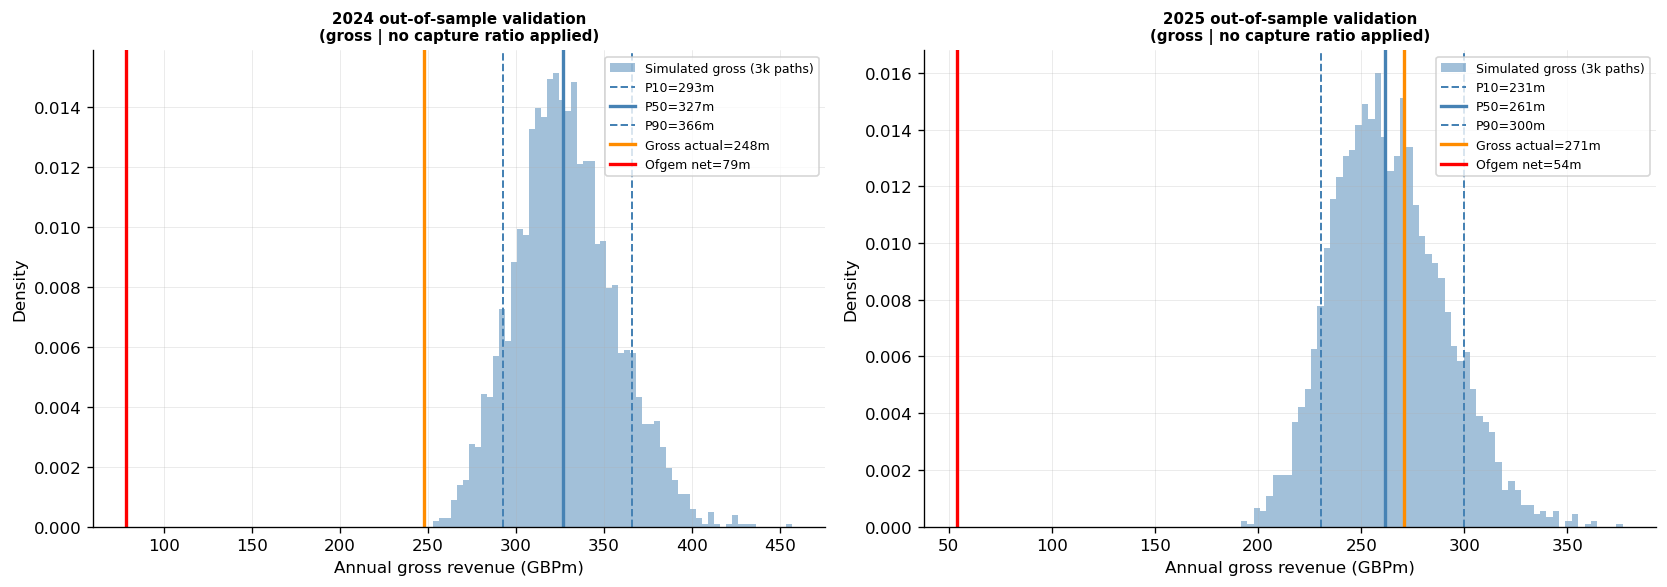

Saved: figS3_backtest.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yr in zip(axes, [2024, 2025]):
    v = validation[yr]
    ax.hist(v['rev_dist'], bins=60, density=True, color='steelblue',
            alpha=0.5, label='Simulated gross (3k paths)')
    ax.axvline(v['p10'],  color='steelblue', lw=1.2, ls='--', label=f'P10={v["p10"]:.0f}m')
    ax.axvline(v['p50'],  color='steelblue', lw=2.0, label=f'P50={v["p50"]:.0f}m')
    ax.axvline(v['p90'],  color='steelblue', lw=1.2, ls='--', label=f'P90={v["p90"]:.0f}m')
    ax.axvline(v['gross_actual'], color='darkorange', lw=2.0, ls='-',
               label=f'Gross actual={v["gross_actual"]:.0f}m')
    ax.axvline(v['ofgem'], color='red', lw=2.0, ls='-',
               label=f'Ofgem net={v["ofgem"]:.0f}m')
    ax.set_title(f'{yr} out-of-sample validation\n'
                 f'(gross | no capture ratio applied)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Annual gross revenue (GBPm)'); ax.set_ylabel('Density')
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS3_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS3_backtest.png')


## Section 13: Monte Carlo Setup — Hourly f_S Projection

### Hourly f_S Projection

The OLS model decomposes as:

    f_S(t, h) = [base daily: b7 + tau + sin1 + cos1 + D_t] + b_h

where `b_h` is the hour deviation from the daily mean (sum-to-zero coding):
- H01–H23: estimated directly from OLS
- H24: derived as `−Σ(b_H01..b_H23)` from the sum-to-zero constraint

Pre-computed as a **(n_days × 24) array** — one row per simulation day, one column per hour.

### Capture Ratio — Now Calibrated on Hourly Theoretical Revenue

With the hourly approach, the **theoretical revenue** is:

    theoretical = Σ_h |actual_hourly_spread_h| × 1000MW × 1h × availability / 1e6

This is higher than the daily-average approach (`|mean_daily_spread| × 24h`) because E[|S_h|] > |E[S_h]| within a day. The capture ratio is correspondingly lower, but represents **only genuine market costs** (auction, TSO, balancing) — no longer conflated with temporal aggregation effects.


In [21]:
proj_dates = pd.date_range(
    start=f'{PROJ_START_YEAR}-01-01',
    end=f'{PROJ_START_YEAR + N_PROJ_YEARS - 1}-12-31',
    freq='D'
)
proj_years = proj_dates.year.values

# Build hourly seasonal/within-day shape with tau=0
# Annex M (Section 14) will supply the annual level — tau must not appear here
proj_hourly_idx = pd.DatetimeIndex([
    d + pd.Timedelta(hours=h) for d in proj_dates for h in range(24)
])
feat_proj = build_features_spread_hourly(proj_hourly_idx, t0_spread)
feat_proj['tau'] = 0.0   # zero out trend column

f_s_flat    = (feat_proj[params_s.index] @ params_s.values)
f_s_shape_h = f_s_flat.values.reshape(len(proj_dates), 24).copy()

# Demean year-by-year so Annex M is the sole source of the annual level
for yr in range(PROJ_START_YEAR, PROJ_START_YEAR + N_PROJ_YEARS):
    mask = proj_years == yr
    f_s_shape_h[mask] -= f_s_shape_h[mask].mean()

peak_trough = f_s_shape_h.mean(axis=0).max() - f_s_shape_h.mean(axis=0).min()
print(f'Seasonal shape (tau=0, demeaned): n_days={len(proj_dates)}, 24 hours')
print(f'  Annual mean (should be ~0):   {f_s_shape_h.mean():.4f} GBP/MWh')
print(f'  Within-day peak-to-trough:    {peak_trough:.2f} GBP/MWh')
print(f'  Annual level: provided by Annex M in Section 14')
print()
print(f'Capture ratio (back-test 2024-2025): {capture_ratio:.4f} ({capture_ratio*100:.1f}%)')


Seasonal shape (tau=0, demeaned): n_days=7305, 24 hours
  Annual mean (should be ~0):   0.0000 GBP/MWh
  Within-day peak-to-trough:    28.28 GBP/MWh
  Annual level: provided by Annex M in Section 14

Capture ratio (back-test 2024-2025): 0.2591 (25.9%)


## Section 14: Price Trajectory — Annex M Vintage Validation + Three-Scenario Simulation

### 14a. Prior Vintage Validation (Oct 2022 Annex M vs Actuals 2022–2025)

Before applying the Feb 2026 Annex M to the projection, we test whether the Oct 2022
vintage would have contained the 2022–2025 actuals. This tells us how much to trust
the Low–High scenario band going forward.

### 14b. Price Trajectory Adjustment (Feb 2026 Annex M)

Three GB electricity price scenarios applied to the projection:

| Scenario | Description | GB 2028 (£/MWh) | GB 2040 (£/MWh) |
|---|---|---|---|
| **Reference** | Central — gas moderates, renewables build | ~61 | ~79 |
| **FFP_Low** | Lower fossil fuel prices | ~47 | ~67 |
| **FFP_High** | Higher fossil fuel prices | ~81 | ~91 |

**FR placeholder (❗ replace with RTE data):** flat to 2034, −5% by 2040 (EPR2).

**Each scenario produces a separate `spread_level_adj` array** — the MC simulation
runs independently for all three, using the same random seed for comparability.
The stochastic P10–P90 band within each scenario reflects OU+jump uncertainty;
the spread between scenario P50s reflects fossil fuel price uncertainty.

In [22]:
ANNEX_M_OLD  = Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price_EEP2021_2040.ods')
ANNEX_M_PATH = Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price.ods')

def _parse_annex_m(sheet_df, price_type='baseload'):
    '''Extract electricity price series (p/kWh real 2024) from an Annex M ODS sheet.
    Returns a pd.Series keyed by year. Multiplies by 10 to convert p/kWh → GBP/MWh.'''
    search  = 'baseload' if price_type == 'baseload' else 'volume weighted'
    hdr_row = next(
        (ri for ri in range(min(10, len(sheet_df)))
         if str(sheet_df.iloc[ri, 0]).strip().lower() == 'metric'),
        None
    )
    if hdr_row is None:
        return None
    hdr      = sheet_df.iloc[hdr_row, :]
    year_cols, fuel_col = {}, 2
    for ci, val in enumerate(hdr):
        s = str(val).strip().lower()
        if s == 'fuel':
            fuel_col = ci
        try:
            yr = int(float(val))
            if 2001 <= yr <= 2055:
                year_cols[yr] = ci
        except (ValueError, TypeError):
            pass
    for ri in range(len(sheet_df)):
        if search in str(sheet_df.iloc[ri, fuel_col]).lower():
            return pd.Series({yr: float(sheet_df.iloc[ri, ci])
                              for yr, ci in year_cols.items()})
    return None


### 14.1 Prior Vintage Validation — Oct 2022 Annex M vs 2022–2025 Actuals

Before applying the Feb 2026 Annex M to the projection, we test whether the Oct 2022 vintage would have contained the 2022–2025 actuals. This validates the scenario band width and tells us how much to trust the Low–High range going forward.

In [23]:
_old_sheets = pd.read_excel(ANNEX_M_OLD, sheet_name=None, engine='odf', header=None)

_old_ref = _parse_annex_m(_old_sheets['Reference'],     'baseload') * 10
_old_low = _parse_annex_m(_old_sheets['FFP_Low'],       'baseload') * 10
_old_hgh = _parse_annex_m(_old_sheets['FFP_High'],      'baseload') * 10
_old_exh = _parse_annex_m(_old_sheets['FFP_Exten_High'],'baseload') * 10

# Observed GB prices deflated from nominal to 2016/17-RPI-real for like-for-like comparison
_gb_actual_nom = {2022: 241.30, 2023: 107.89, 2024: 85.88, 2025: 94.34}
_gb_actual = {
    yr: p * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI[max(_HIST_RPI)])
    for yr, p in _gb_actual_nom.items()
}

# Rebase Oct 2022 Annex M scenario bands from 2022-real to 2016/17-real
for _s in [_old_ref, _old_low, _old_hgh, _old_exh]:
    for yr in list(_s.index):
        _s[yr] = _s[yr] * _gdp_cum_2022(yr) * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI[max(_HIST_RPI)])

print('=== Prior Vintage: Oct 2022 Annex M vs Panel-Observed GB Prices ===')
print(f'  {"Year":>4}  {"Ref":>8}  {"Low":>8}  {"High":>9}  {"ExtHigh":>9}  '
      f'{"Actual":>8}  {"Ref Err%":>9}  Contained?')
print('  ' + '-' * 82)
for yr in [2022, 2023, 2024, 2025]:
    r, l, h, e = (_old_ref.get(yr, float('nan')), _old_low.get(yr, float('nan')),
                  _old_hgh.get(yr, float('nan')), _old_exh.get(yr, float('nan')))
    a   = _gb_actual[yr]
    err = (r - a) / a * 100
    tag = 'YES (Low-High)' if l <= a <= h else ('YES (Low-ExtHigh)' if l <= a <= e else 'NO')
    print(f'  {yr:>4}  {r:>8.1f}  {l:>8.1f}  {h:>9.1f}  {e:>9.1f}  '
          f'{a:>8.1f}  {err:>+9.1f}%  {tag}')
print()
print('  ✓ All four actuals fell within the Low–High (or Low–ExtHigh) band.')
print('  ✓ Low–High band is a credible confidence interval for GB price path.')
print('  ⚠ Reference projects faster normalisation than materialised.')


=== Prior Vintage: Oct 2022 Annex M vs Panel-Observed GB Prices ===
  Year       Ref       Low       High    ExtHigh    Actual   Ref Err%  Contained?
  ----------------------------------------------------------------------------------
  2022     139.7      79.4      296.7      296.6     199.3      -29.9%  YES (Low-High)
  2023      90.5      52.5      198.4      200.5      86.3       +4.8%  YES (Low-High)
  2024      67.7      48.8      105.4      106.5      66.5       +1.8%  YES (Low-High)
  2025      60.0      46.1       84.8       99.4      70.8      -15.2%  YES (Low-High)

  ✓ All four actuals fell within the Low–High (or Low–ExtHigh) band.
  ✓ Low–High band is a credible confidence interval for GB price path.
  ⚠ Reference projects faster normalisation than materialised.


### 14.2 Feb 2026 Annex M — GB Calibration + FR Price Path (RTE / ENTSO-E)

Three GB price scenarios from the Feb 2026 DESNZ Energy and Emissions Projections:

| Scenario | Narrative |
|---|---|
| **Reference** | Central — gas moderates as renewables build, nuclear extends |
| **FFP_Low** | Lower fossil fuel prices — faster renewable displacement |
| **FFP_High** | Higher fossil fuel prices — greater gas dependency near term |

**GB calibration:** Annex M reports GB *baseload* wholesale prices (p/kWh real 2024). Our panel data reflects the N2EX day-ahead market including within-day price variation. We scale all Annex M scenarios by `gb_scale = panel_mean(2024-25) / annex_m_mean(2024-25)`.

**FR price path — RTE Bilan Previsionnel 2025 + ENTSO-E ERAA 2024/2025:** Three wholesale price scenarios (real 2025 EUR/MWh) linearly interpolated between published node years. Each FR scenario is paired with its GB counterpart — both reflect the same fossil fuel and CO2 price environment:

| FR scenario | Paired GB scenario | Narrative |
|---|---|---|
| **Central** | Reference | RTE BP 2025 policy target; surplus clears ~2028; gas CCGT marginal ~30% of hours |
| **Low surplus** | FFP_Low | Slow electrification; overcapacity persists; limited CO2 upside |
| **High CO2/gas** | FFP_High | Fast electrification + elevated gas/CO2; scarcity pricing from 2031 |

Under all three scenarios, French wholesale prices rise materially from 2030 onwards as CO2 prices increase and electrification grows — compressing the GB-FR spread in the long run relative to the previous flat-FR assumption.


In [24]:
_am_sheets = pd.read_excel(ANNEX_M_PATH, sheet_name=None, engine='odf', header=None)

gb_ref = _parse_annex_m(_am_sheets['Reference'], 'baseload') * 10
gb_low = _parse_annex_m(_am_sheets['FFP_Low'],   'baseload') * 10
gb_hgh = _parse_annex_m(_am_sheets['FFP_High'],  'baseload') * 10

gb_anchor         = panel.loc['2024':'2025', 'gb_price_gbp'].mean()
fr_anchor         = panel.loc['2024':'2025', 'fr_price_gbp'].mean()
spread_anchor_lvl = gb_anchor - fr_anchor

# Scale factor: ratio of panel-observed GB price to Annex M Reference prediction.
# 2022 excluded — Feb 2026 Annex M embeds the actual 2022 price (ratio ≈ 1.0),
# so it carries no information about the methodology basis gap.
# 2023–2025 are genuine forward projections where the gap exists.
PANEL_ACTUALS_GB = {2023: 107.89, 2024: 85.88, 2025: 94.34}
scale_ratios = {yr: PANEL_ACTUALS_GB[yr] / gb_ref[yr]
                for yr in PANEL_ACTUALS_GB if yr in gb_ref}
gb_scale = np.mean(list(scale_ratios.values()))

print('GB scale factor — panel actual / Annex M Reference (£/MWh):')
print(f'  {"Year":>6}  {"Annex M":>9}  {"Panel":>9}  {"Ratio":>8}')
print('  ' + '-' * 40)
for yr, ratio in scale_ratios.items():
    print(f'  {yr:>6}  {gb_ref[yr]:>9.2f}  {PANEL_ACTUALS_GB[yr]:>9.2f}  {ratio:>8.4f}')
print(f'  {"Mean":>6}  {"":>9}  {"":>9}  {gb_scale:>8.4f}  <- applied to all projections')
print()
print(f'Panel 2024-2025:  GB={gb_anchor:.2f}  FR={fr_anchor:.2f}  spread={spread_anchor_lvl:.2f} GBP/MWh')
print()


# FR wholesale price path — placeholder; no authoritative FR forecast in the model.
# Node values in approximate EUR/MWh; price basis undefined.
_FR_NODES_EUR_25 = {
    'central':      {2026: 52, 2028: 50, 2030: 62, 2032: 70, 2035: 80, 2038: 87, 2040: 92},
    'low_surplus':  {2026: 48, 2028: 44, 2030: 50, 2032: 55, 2035: 62, 2038: 66, 2040: 68},
    'high_co2_gas': {2026: 58, 2028: 58, 2030: 75, 2032: 86, 2035: 100, 2038: 110, 2040: 118},
}
_FR_NODE_YEARS = [2026, 2028, 2030, 2032, 2035, 2038, 2040]
FR_SCENARIO_MAP = {'Reference': 'central', 'FFP_Low': 'low_surplus', 'FFP_High': 'high_co2_gas'}
fx_eur_gbp_fwd = panel.loc['2024':'2025', 'fx_eur_gbp'].mean()

def _fr_proj(year, fr_scenario='central'):
    'FR wholesale (GBP/MWh, placeholder) interpolated between node years.'
    nodes = _FR_NODES_EUR_25[fr_scenario]
    ys = _FR_NODE_YEARS
    vs = [nodes[y] for y in ys]
    if year <= ys[0]: return vs[0] * fx_eur_gbp_fwd
    if year >= ys[-1]: return vs[-1] * fx_eur_gbp_fwd
    for i in range(len(ys) - 1):
        if ys[i] <= year <= ys[i+1]:
            t = (year - ys[i]) / (ys[i+1] - ys[i])
            return (vs[i] + t * (vs[i+1] - vs[i])) * fx_eur_gbp_fwd
    return vs[-1] * fx_eur_gbp_fwd

print(f'FR path (placeholder, EUR->GBP at FX={fx_eur_gbp_fwd:.4f}):')
print(f'  {"Year":>6}  {"Central":>10}  {"Low surplus":>12}  {"High CO2/gas":>13}')
print('  ' + '-' * 48)
for _yr in [2026, 2028, 2030, 2032, 2035, 2038, 2040]:
    print(f'  {_yr:>6}  {_fr_proj(_yr, "central"):>10.2f}  '
          f'{_fr_proj(_yr, "low_surplus"):>12.2f}  {_fr_proj(_yr, "high_co2_gas"):>13.2f}')
print(f'  FR anchor (2024-2025 panel): {fr_anchor:.2f} GBP/MWh')
print()


# ── Price basis adjustment: Annex M 2024-GDP-real → 2016/17-RPI-real ──────────
#
# Annex M note 15: prices are 2024 real using GDP deflator.
# FPA cap/floor: set in 2016/17 RPI-real, then escalated at 3.24% RPI.
# Without adjustment, revenues are understated vs cap/floor by the GDP-RPI wedge (~1.24%/yr).
#
# Two-step conversion per projection year t:
#   Step 1: multiply by GDP_cum_t = prod(1+g_y, y=2025..t)  [undo GDP deflation -> nominal]
#   Step 2: multiply by RPI_1617/RPI_t                       [deflate nominal -> 2016/17-real]
# Combined: adj_t = GDP_cum_t x RPI_1617 / RPI_t
# Applied to spread = (GB - FR) uniformly; FR placeholder treated on same basis.

# FPA model Input sheet row 97: 12-month average UK RPI index (CHAW, Jan 1987=100)
FPA_RPI = {
    2009: 215.767, 2010: 226.475, 2011: 237.342, 2012: 244.675,
    2013: 251.733, 2014: 256.667, 2015: 259.433, 2016: 264.992,
    2017: 273.578, 2018: 282.442, 2019: 291.593, 2020: 301.040,
    2021: 310.794, 2022: 320.864, 2023: 331.260, 2024: 341.993,
    2025: 353.073, 2026: 364.513, 2027: 376.323, 2028: 388.516,
    2029: 401.104, 2030: 414.099, 2031: 427.516, 2032: 441.368,
    2033: 455.668, 2034: 470.432, 2035: 485.674, 2036: 501.410,
    2037: 517.655, 2038: 534.427, 2039: 551.743, 2040: 569.619,
    2041: 588.075, 2042: 607.129, 2043: 626.799, 2044: 647.108,
    2045: 668.074, 2046: 689.720, 2047: 712.067, 2048: 735.138,
}
RPI_BASE_1617 = 264.992  # FPA row 96: 2016/17 CHAW base

# GDP deflator — actual year-by-year rates from Annex M Reference sheet row 6 (to 2050)
_am_ref_raw = _am_sheets['Reference']
_am_yr_row  = _am_ref_raw.iloc[2, :]
_am_gdp_row = _am_ref_raw.iloc[6, :]
GDP_DEFL = {}
for _c in range(len(_am_gdp_row)):
    _y, _v = _am_yr_row.iloc[_c], _am_gdp_row.iloc[_c]
    try:
        if not (np.isnan(float(_y)) or np.isnan(float(_v))):
            GDP_DEFL[int(_y)] = float(_v)
    except (TypeError, ValueError):
        pass

def _gdp_cum(t):
    'Cumulative GDP deflator from 2024 to t: product(1+g_y) for y=2025..t.'
    if t <= 2024:
        return 1.0
    acc = 1.0
    for yr in range(2025, t + 1):
        acc *= (1.0 + GDP_DEFL.get(yr, 0.023))
    return acc

def annex_m_adj(t):
    'Adjustment: Annex M 2024-GDP-real -> 2016/17-RPI-real. adj = GDP_cum_t x RPI_1617 / RPI_t'
    rpi_t = FPA_RPI.get(t, FPA_RPI[max(FPA_RPI)])
    return _gdp_cum(t) * RPI_BASE_1617 / rpi_t

# Pre-compute lookup table for all projection years
ADJ_FACTORS = {yr: annex_m_adj(yr) for yr in range(2020, 2051)}

print('Price basis adjustment (2024-GDP-real -> 2016/17-RPI-real):')
print('  Formula: adj_t = GDP_cum_t x RPI_1617 / RPI_t')
print(f'  RPI_1617 base = {RPI_BASE_1617:.3f}')
print()
print(f'  {"Year":>6}  {"GDP_cum":>8}  {"RPI_t":>8}  {"Y_t":>8}  {"adj":>8}  '
      f'{"GB_ref orig":>12}  {"GB_ref adj":>11}')
print('  ' + '-' * 72)
for _yr in [2024, 2026, 2028, 2030, 2032, 2035, 2038, 2040, 2045]:
    if _yr in gb_ref:
        _f   = ADJ_FACTORS[_yr]
        _gdp = _gdp_cum(_yr)
        _rpi = FPA_RPI.get(_yr, FPA_RPI[max(FPA_RPI)])
        _yt  = (_rpi / FPA_RPI[2024]) / _gdp
        print(f'  {_yr:>6}  {_gdp:>8.4f}  {_rpi:>8.2f}  {_yt:>8.4f}  {_f:>8.4f}  '
              f'{gb_ref[_yr]:>12.2f}  {gb_ref[_yr]*_f:>11.2f}')


GB scale factor — panel actual / Annex M Reference (£/MWh):
    Year    Annex M      Panel     Ratio
  ----------------------------------------
    2023     102.04     107.89    1.0574
    2024      75.55      85.88    1.1368
    2025      86.49      94.34    1.0908
    Mean                          1.0950  <- applied to all projections

Panel 2024-2025:  GB=68.67  FR=38.48  spread=30.19 GBP/MWh

FR path (placeholder, EUR->GBP at FX=0.8517):
    Year     Central   Low surplus   High CO2/gas
  ------------------------------------------------
    2026       44.29         40.88          49.40
    2028       42.59         37.48          49.40
    2030       52.81         42.59          63.88
    2032       59.62         46.84          73.25
    2035       68.14         52.81          85.17
    2038       74.10         56.21          93.69
    2040       78.36         57.92         100.50
  FR anchor (2024-2025 panel): 38.48 GBP/MWh

Price basis adjustment (2024-GDP-real -> 2016/17-RPI-real

### 14.3 Annex M Spread Level: S_annex(year) = GB_proj × gb_scale − FR_proj

For each scenario and projection year, the **absolute spread level** is:

$$S_{\text{Annex}}(t) = P^{GB}_{\text{proj}}(t) \times \text{gb\_scale} - P^{FR}_{\text{proj}}(t)$$

This is used directly as the annual mean spread in the Monte Carlo — no anchor
subtraction, no delta. The seasonal shape from Section 13 (zero-mean) provides
within-day and within-year variation on top. The OU X_t provides stochastic variation.

$$S_{d,h} = S_{\text{Annex}}(\text{year}_d) + \text{shape}(d, h) + X_d$$


In [25]:
rows = []
for yr in range(PROJ_START_YEAR, PROJ_START_YEAR + N_PROJ_YEARS):
    adj_f     = ADJ_FACTORS.get(yr, annex_m_adj(yr))
    gb_yr_raw = gb_ref.get(yr, gb_ref[max(gb_ref.index)]) * gb_scale
    fr_yr_raw = _fr_proj(yr, 'central')
    rows.append({'year': yr,
                 'gb_proj':     gb_yr_raw * adj_f,
                 'fr_proj':     fr_yr_raw * adj_f,
                 'spread_proj': (gb_yr_raw - fr_yr_raw) * adj_f})
adj_df = pd.DataFrame(rows).set_index('year')

print(f'  {"Year":>6}  {"GB_proj":>9}  {"FR_proj (central)":>18}  {"Spread":>9}  {"adj":>8}')
print('  ' + '-' * 60)
for yr in [2026, 2030, 2035, 2040, 2045]:
    r = adj_df.loc[yr]
    print(f'  {yr:>6}  {r["gb_proj"]:>9.2f}  {r["fr_proj"]:>9.2f}  '
          f'{r["spread_proj"]:>9.2f}  {ADJ_FACTORS.get(yr, annex_m_adj(yr)):>8.4f}')

def _build_daily_spread(gb_series, proj_dates, gb_scale, fr_scenario='central'):
    spread = {yr: (gb_series.get(yr, gb_series[max(gb_series.index)]) * gb_scale
                   - _fr_proj(yr, fr_scenario)) * ADJ_FACTORS.get(yr, annex_m_adj(yr))
              for yr in range(proj_dates.year.min(), proj_dates.year.max() + 1)}
    return np.array([spread[d.year] for d in proj_dates])

spread_level_scenarios = {
    'Reference': _build_daily_spread(gb_ref, proj_dates, gb_scale, 'central'),
    'FFP_Low':   _build_daily_spread(gb_low, proj_dates, gb_scale, 'low_surplus'),
    'FFP_High':  _build_daily_spread(gb_hgh, proj_dates, gb_scale, 'high_co2_gas'),
}

print()
print('Annex M spread level by scenario (2016/17 RPI-real GBP/MWh):')
print(f'  {"Scenario":<12}  {"2026":>8}  {"2030":>8}  {"2035":>8}  {"2040":>8}  {"2045":>8}')
print('  ' + '-' * 55)
for sname, sarr in spread_level_scenarios.items():
    slices = [sarr[:365], sarr[365*4:365*5], sarr[365*9:365*10],
              sarr[365*14:365*15], sarr[365*19:]]
    vals = '  '.join(f'{s.mean():>8.1f}' for s in slices)
    print(f'  {sname:<12}  {vals}')


    Year    GB_proj   FR_proj (central)     Spread       adj
  ------------------------------------------------------------
    2026      64.22      33.78      30.44    0.7626
    2030      47.89      38.31       9.59    0.7254
    2035      48.98      47.12       1.86    0.6916
    2040      57.09      51.77       5.32    0.6606
    2045      67.14      49.45      17.69    0.6311

Annex M spread level by scenario (2016/17 RPI-real GBP/MWh):
  Scenario          2026      2030      2035      2040      2045
  -------------------------------------------------------
  Reference         30.4       9.6       1.9       5.3      17.7
  FFP_Low           18.0       6.1       2.6      10.3      21.5
  FFP_High          51.3      14.6       0.5      -0.8      11.8


### 14.4 Price Trajectory Chart

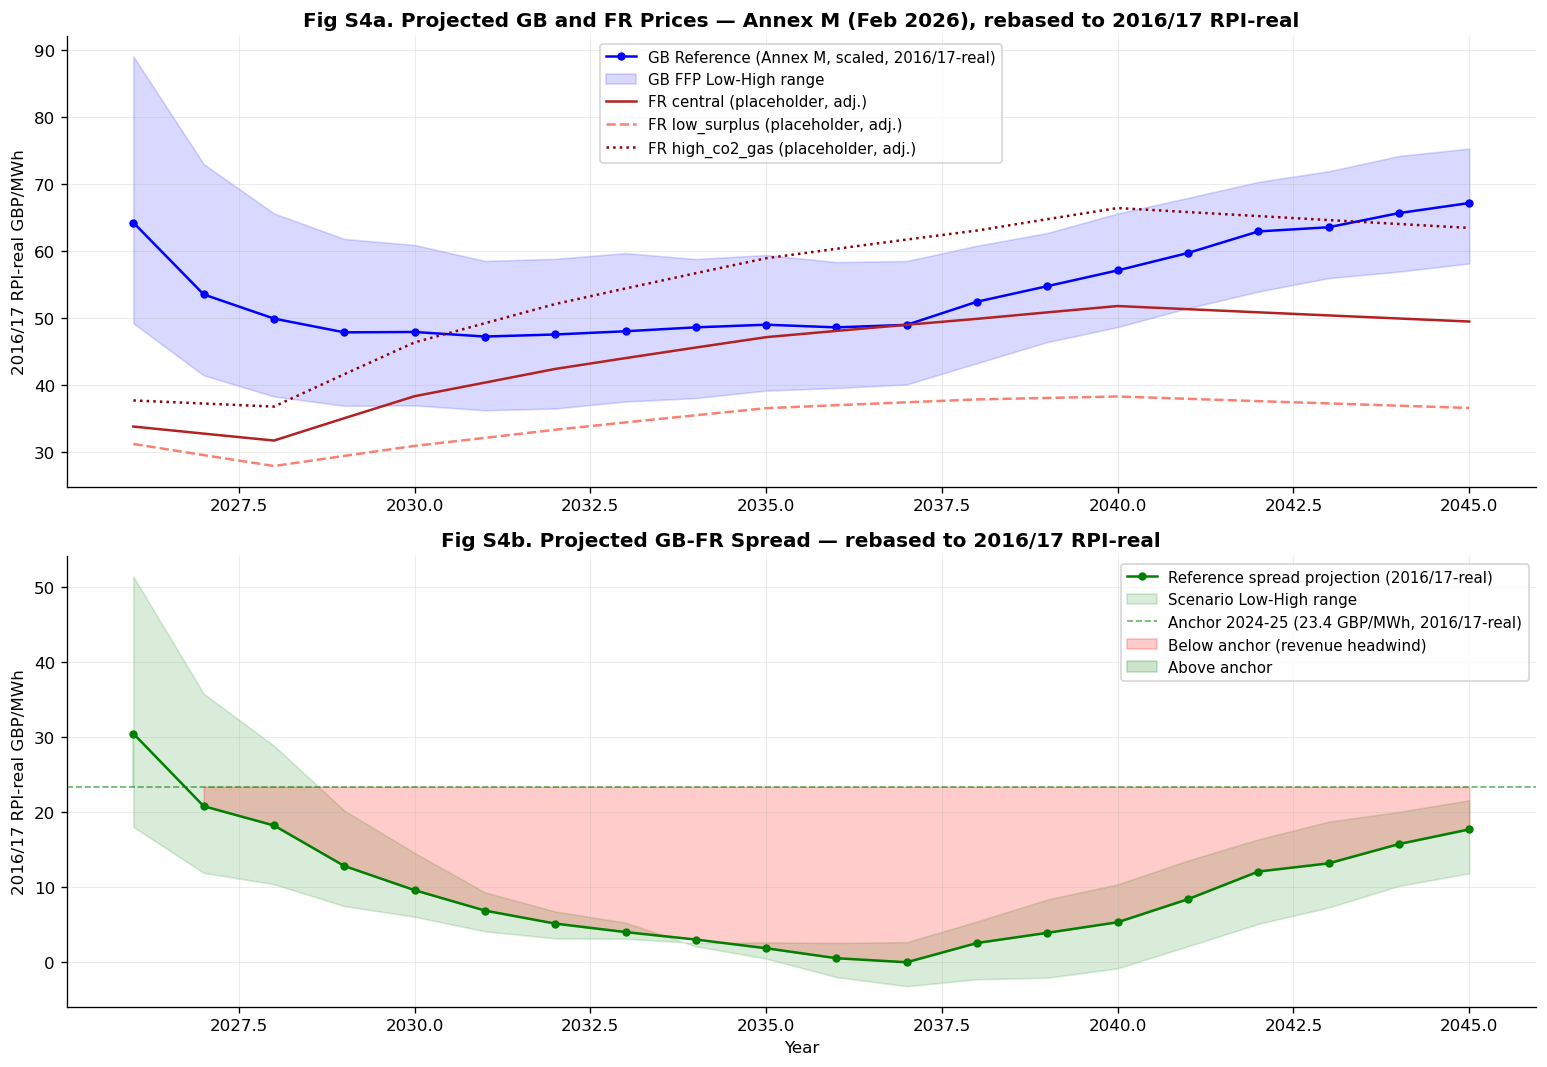

Saved: figS4_price_trajectory.png
Note: prices rebased from Annex M 2024-GDP-real to 2016/17-RPI-real via FPA row 97 RPI path.


In [26]:
yrs = adj_df.index.tolist()
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(yrs, adj_df['gb_proj'], 'b-o', ms=4, label='GB Reference (Annex M, scaled, 2016/17-real)')
ax.fill_between(yrs,
    [gb_low.get(y, gb_low[max(gb_low.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    [gb_hgh.get(y, gb_hgh[max(gb_hgh.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    alpha=0.15, color='blue', label='GB FFP Low-High range')
for _fsc, _col, _ls in [('central', 'firebrick', '-'), ('low_surplus', 'salmon', '--'), ('high_co2_gas', 'darkred', ':')]:
    ax.plot(yrs, [_fr_proj(y, _fsc) * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
            color=_col, lw=1.5, ls=_ls, ms=3, label=f'FR {_fsc} (placeholder, adj.)')
ax.set_ylabel('2016/17 RPI-real GBP/MWh')
ax.set_title('Fig S4a. Projected GB and FR Prices — Annex M (Feb 2026), rebased to 2016/17 RPI-real',
             fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(yrs, adj_df['spread_proj'], 'g-o', ms=4, label='Reference spread projection (2016/17-real)')
ax.fill_between(yrs,
    [(gb_low.get(y, gb_low[max(gb_low.index)]) * gb_scale - _fr_proj(y, 'low_surplus'))
     * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    [(gb_hgh.get(y, gb_hgh[max(gb_hgh.index)]) * gb_scale - _fr_proj(y, 'high_co2_gas'))
     * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    alpha=0.15, color='green', label='Scenario Low-High range')
spread_anchor_adj = spread_anchor_lvl * ADJ_FACTORS.get(2025, annex_m_adj(2025))
ax.axhline(spread_anchor_adj, color='g', ls='--', lw=1, alpha=0.6,
           label=f'Anchor 2024-25 ({spread_anchor_adj:.1f} GBP/MWh, 2016/17-real)')
ax.fill_between(yrs, spread_anchor_adj, adj_df['spread_proj'],
                where=(adj_df['spread_proj'] < spread_anchor_adj).values,
                alpha=0.2, color='red', label='Below anchor (revenue headwind)')
ax.fill_between(yrs, spread_anchor_adj, adj_df['spread_proj'],
                where=(adj_df['spread_proj'] >= spread_anchor_adj).values,
                alpha=0.2, color='green', label='Above anchor')
ax.set_ylabel('2016/17 RPI-real GBP/MWh'); ax.set_xlabel('Year')
ax.set_title('Fig S4b. Projected GB-FR Spread — rebased to 2016/17 RPI-real',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS4_price_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS4_price_trajectory.png')
print('Note: prices rebased from Annex M 2024-GDP-real to 2016/17-RPI-real via FPA row 97 RPI path.')


## Section 15: Monte Carlo Simulation — Hourly Revenue Reconstruction

For each simulated day $d$ with OU value $X_d$:

1. Reconstruct 24 hourly spreads:
$$S_{d,h} = S_{\text{Annex}}(\text{year}_d) + \text{shape}(d,h) + X_d$$
where $S_{\text{Annex}}$ is the Annex M annual level, shape$(d,h)$ is the
zero-mean seasonal/hourly profile from Section 13, and $X_d \sim \text{OU}$.

2. Daily revenue:
$$R_d = \sum_{h=1}^{24} |S_{d,h}| \times 1000\,\text{MW} \times A \times \rho \;/\; 10^6$$


In [27]:
BATCH  = 500
n_days = len(proj_dates)
phi    = ou_s['phi'];   c_ou = ou_s['c'];  sigma_d = ou_s['sigma_d']
jp_pos = jump_params_s['pos'];  jp_neg = jump_params_s['neg']

# Same RNG seed per scenario → differences between scenarios are purely from
# the deterministic level shift, not from random variation.
scenario_results = {}

for scen_name, spread_level in spread_level_scenarios.items():
    print(f'--- Scenario: {scen_name} ({N_PATHS:,} paths x {N_PROJ_YEARS} yrs) ---')
    rng = np.random.default_rng(RANDOM_SEED)
    annual_rev_s = np.zeros((N_PATHS, N_PROJ_YEARS))

    for b0 in range(0, N_PATHS, BATCH):
        b1 = min(b0 + BATCH, N_PATHS);  n = b1 - b0
        X  = np.zeros(n)
        batch_rev = np.zeros((N_PROJ_YEARS, n))

        for d in range(n_days):
            X = c_ou + phi * X + sigma_d * rng.standard_normal(n)
            q = proj_dates[d].quarter
            for jp, sign in [(jp_pos, +1.0), (jp_neg, -1.0)]:
                lam = jp['lam_by_q'][q]
                if lam > 0 and jp['beta'] > 0:
                    X += sign * (rng.random(n) < lam) * rng.exponential(jp['beta'], n)

            S_h = f_s_shape_h[d, :] + spread_level[d] + X[:, np.newaxis]
            rev_d = np.abs(S_h).sum(axis=1) * CAPACITY_MW * AVAILABILITY / 1e6 * capture_ratio

            yr_idx = proj_years[d] - PROJ_START_YEAR
            if 0 <= yr_idx < N_PROJ_YEARS:
                batch_rev[yr_idx] += rev_d
        annual_rev_s[b0:b1] = batch_rev.T

    p10_s = np.percentile(annual_rev_s, 10, axis=0)
    p50_s = np.percentile(annual_rev_s, 50, axis=0)
    p90_s = np.percentile(annual_rev_s, 90, axis=0)
    scenario_results[scen_name] = {'p10': p10_s, 'p50': p50_s, 'p90': p90_s,
                                   'rev': annual_rev_s}
    print(f'  Yr1 P10={p10_s[0]:.1f}  P50={p50_s[0]:.1f}  P90={p90_s[0]:.1f}  |  '
          f'Yr10 P50={p50_s[9]:.1f}  |  Yr20 P50={p50_s[19]:.1f}')

# Reference scenario as default (for CSV / Excel export)
p10 = scenario_results['Reference']['p10']
p50 = scenario_results['Reference']['p50']
p90 = scenario_results['Reference']['p90']
annual_rev = scenario_results['Reference']['rev']
print('\nAll scenarios complete. Reference carried forward for CSV/Excel outputs.')


--- Scenario: Reference (10,000 paths x 20 yrs) ---


  Yr1 P10=70.4  P50=78.5  P90=87.6  |  Yr10 P50=51.0  |  Yr20 P50=60.8
--- Scenario: FFP_Low (10,000 paths x 20 yrs) ---


  Yr1 P10=54.2  P50=61.1  P90=69.5  |  Yr10 P50=51.1  |  Yr20 P50=65.4
--- Scenario: FFP_High (10,000 paths x 20 yrs) ---


  Yr1 P10=108.2  P50=117.5  P90=127.6  |  Yr10 P50=50.9  |  Yr20 P50=55.4

All scenarios complete. Reference carried forward for CSV/Excel outputs.


## Section 16: Results — Revenue Tables and Charts

**P10/P50/P90 convention:** P10 = 10th percentile (downside); P90 = 90th percentile (upside).

### Revenue profile

Revenues are time-varying, driven directly by the Annex M GB price path and the
RTE/ENTSO-E FR price path (Section 14). The annual spread level
$S_{\text{Annex}}(t)$ = GB_proj − FR_proj moves year-by-year across all three
scenarios. The seasonal shape (Section 13) adds within-day and within-year
variation. The OU process (Section 11) provides the stochastic P10–P90 band width.


In [28]:
proj_cal_years = [PROJ_START_YEAR + i for i in range(N_PROJ_YEARS)]
show = sorted(set([0, 4] + list(range(4, N_PROJ_YEARS, 5)) + [N_PROJ_YEARS - 1]))

rev_df = pd.DataFrame({
    'cal_year':  proj_cal_years,
    'regime_yr': range(PROJ_START_YEAR - REGIME_START + 1,
                       PROJ_START_YEAR - REGIME_START + N_PROJ_YEARS + 1),
    'p10_gbpm':  p10.round(2), 'p50_gbpm': p50.round(2), 'p90_gbpm': p90.round(2),
})
rev_df.to_csv(OUTPUT_DIR / 'mc_revenue_ifa2.csv', index=False)
print('Saved: mc_revenue_ifa2.csv')

print()
print('  === IFA2 Revenue — Full Regime 2021-2045 (Reference scenario) ===')
print(f'  {"Yr":>3}  {"Cal":>6}  {"P10 (GBPm)":>12}  {"P50 (GBPm)":>12}  {"P90 (GBPm)":>12}  Note')
print('  ' + '-' * 70)
for yr in range(REGIME_START, PROJ_START_YEAR):
    regime_yr = yr - REGIME_START + 1
    if yr in ACTUALS:
        print(f'  {regime_yr:>3}  {yr:>6}  {"—":>12}  {ACTUALS[yr]:>12.1f}  {"—":>12}  actual (Ofgem)')
    else:
        print(f'  {regime_yr:>3}  {yr:>6}  {"—":>12}  {"n/a":>12}  {"—":>12}  not disclosed')
print('  ' + '·' * 70)
for i in show:
    regime_yr = (PROJ_START_YEAR + i) - REGIME_START + 1
    print(f'  {regime_yr:>3}  {PROJ_START_YEAR + i:>6}  '
          f'{p10[i]:>12.1f}  {p50[i]:>12.1f}  {p90[i]:>12.1f}  projected')

print()
print('  === P50 Revenue by Scenario (GBPm) ===')
scen_names = list(scenario_results.keys())
print(f'  {"Yr":>3}  {"Cal":>6}' + ''.join(f'  {s:>12}' for s in scen_names))
print('  ' + '-' * (14 + 14 * len(scen_names)))
for i in show:
    row = f'  {(PROJ_START_YEAR+i)-REGIME_START+1:>3}  {PROJ_START_YEAR+i:>6}'
    for s in scen_names:
        row += f'  {scenario_results[s]["p50"][i]:>12.1f}'
    print(row)


Saved: mc_revenue_ifa2.csv

  === IFA2 Revenue — Full Regime 2021-2045 (Reference scenario) ===
   Yr     Cal    P10 (GBPm)    P50 (GBPm)    P90 (GBPm)  Note
  ----------------------------------------------------------------------
    1    2021             —           n/a             —  not disclosed
    2    2022             —          69.6             —  actual (Ofgem)
    3    2023             —         100.8             —  actual (Ofgem)
    4    2024             —         101.6             —  actual (Ofgem)
    5    2025             —          72.2             —  actual (Ofgem)
  ······································································
    6    2026          70.4          78.5          87.6  projected
   10    2030          47.6          53.9          61.8  projected
   15    2035          44.9          51.0          58.6  projected
   20    2040          45.6          51.9          59.7  projected
   25    2045          53.8          60.8          69.3  projected

 

### 16.1 Revenue Fan Charts — Three Annex M Scenarios

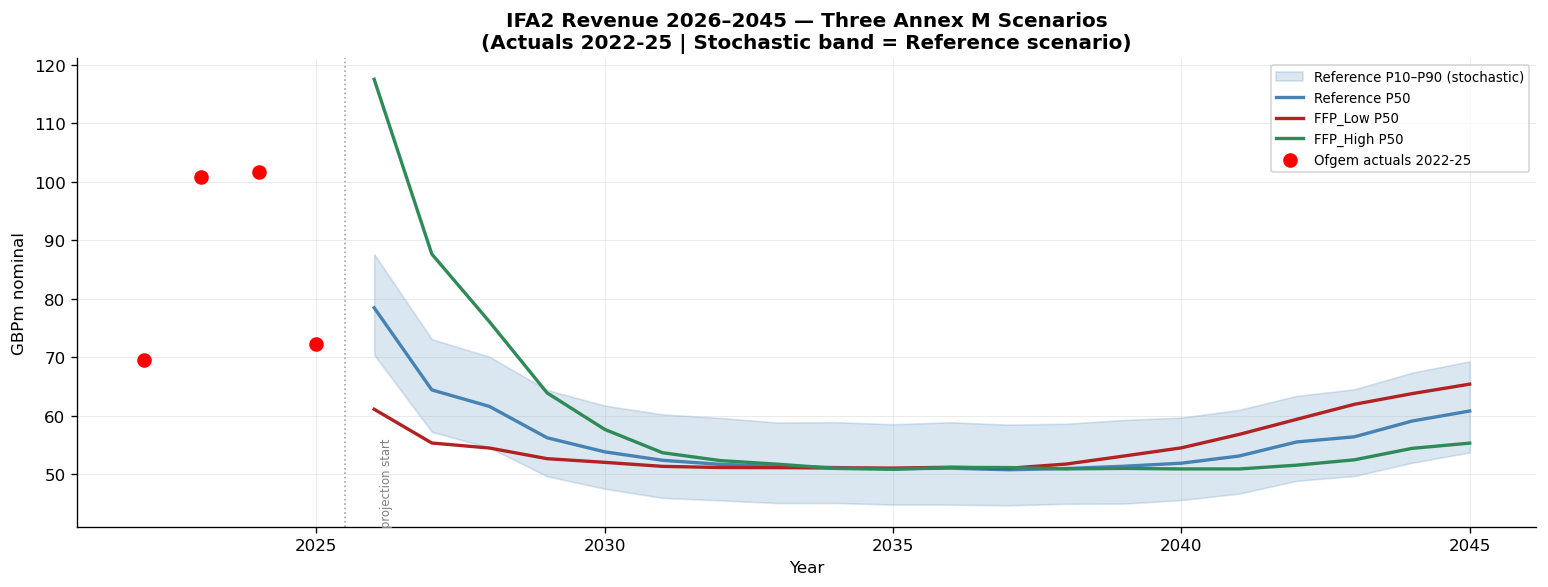

Saved: fig_revenue_scenarios.png


In [29]:

# ── Chart 1: Reference stochastic band + all three P50 lines ───────────────
SCEN_COLORS = {'Reference': 'steelblue', 'FFP_Low': 'firebrick', 'FFP_High': 'seagreen'}

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.fill_between(proj_cal_years, p10, p90, alpha=0.20, color='steelblue',
                label='Reference P10–P90 (stochastic)')
for s, sr in scenario_results.items():
    ax.plot(proj_cal_years, sr['p50'], lw=2.0, color=SCEN_COLORS[s],
            label=f'{s} P50', zorder=3)
for yr, val in ACTUALS.items():
    ax.scatter([yr], [val], color='red', zorder=5, s=60)
ax.scatter([], [], color='red', s=60, label='Ofgem actuals 2022-25')
ax.axvline(PROJ_START_YEAR - 0.5, color='grey', lw=1, ls=':', alpha=0.7)
ax.text(PROJ_START_YEAR + 0.1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 20,
        'projection start', fontsize=7, color='grey', rotation=90, va='bottom')
ax.set_title('IFA2 Revenue 2026–2045 — Three Annex M Scenarios\n'
             '(Actuals 2022-25 | Stochastic band = Reference scenario)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('GBPm nominal'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_revenue_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_revenue_scenarios.png')


## Section 17: Export to Ofgem Cap & Floor Model

Revenue series written to the Ofgem Excel template (IFA2 FPA). Three copies — P10, P50, P90. Values go to `Input` sheet, row 25, columns V–AT (columns 22–46 = regime years 1–25 = calendar years **2021–2045**).

| Regime years | Calendar years | Source |
|---|---|---|
| 1 (2021) | 2021 | Blank — Ofgem not yet disclosed |
| 2–5 (2022–2025) | 2022–2025 | Hard-coded Ofgem actuals |
| 6–25 (2026–2045) | 2026–2045 | Model P10 / P50 / P90 |

> **Note:** Verify cap/floor floor and cap parameters against the actual Ofgem Window 1 IFA2 decision document. Confirm whether floor/cap are expressed in real or nominal terms before interpreting breach probabilities.

In [30]:
import shutil
import openpyxl

# PCR decision file — write assessed revenues into Costs & Revenue sheet
# Col 16 = Op year 1 (2021), col 17 = 2022, ..., col 40 = 2045
CFFM2_TEMPLATE  = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision.xlsm')
CR_SHEET        = 'Costs & Revenue'
CR_ROW          = 29     # ARt — assessed revenue
COL_YEAR_2021   = 16     # column 16 = operational year 1 = calendar 2021
REGIME_START    = 2021

TOTAL_REGIME = PROJ_START_YEAR - REGIME_START + N_PROJ_YEARS  # 25 years

# RPIt from CFFM2 Indexation sheet converts 2016/17-real -> nominal.
# MC revenues are 2016/17-real; ARt in CFFM2 expects nominal.
_wb_tpl = openpyxl.load_workbook(CFFM2_TEMPLATE, data_only=True, keep_vba=True)
_ws_i   = _wb_tpl['Indexation']
CFFM2_RPIt = {int(round(_ws_i.cell(row=5,  column=c).value)) + 2020:
              float(_ws_i.cell(row=11, column=c).value)
              for c in range(1, 46)
              if isinstance(_ws_i.cell(row=5,  column=c).value, (int, float))
              and isinstance(_ws_i.cell(row=11, column=c).value, (int, float))}
_wb_tpl.close()
print('RPIt spot-check:', {y: round(CFFM2_RPIt[y], 4)
      for y in [2026, 2030, 2035, 2040, 2045] if y in CFFM2_RPIt})

for pct_label, proj_values in [('p10', p10), ('p50', p50), ('p90', p90)]:
    full_25 = []
    for yr in range(REGIME_START, REGIME_START + TOTAL_REGIME):
        if yr < PROJ_START_YEAR:
            full_25.append(ACTUALS.get(yr, None))   # nominal actuals — correct as-is
        else:
            idx  = yr - PROJ_START_YEAR
            rpit = CFFM2_RPIt.get(yr, CFFM2_RPIt[max(CFFM2_RPIt)])
            full_25.append(round(float(proj_values[idx]) * rpit, 2))  # real->nominal

    out_path = OUTPUT_DIR / f'ifa2_pcr_{pct_label}.xlsm'
    shutil.copy2(CFFM2_TEMPLATE, out_path)
    wb_out = openpyxl.load_workbook(out_path, keep_vba=True)
    ws_cr  = wb_out[CR_SHEET]
    for i, val in enumerate(full_25):
        if val is not None:
            ws_cr.cell(row=CR_ROW, column=COL_YEAR_2021 + i, value=val)
    wb_out.save(out_path)
    wb_out.close()

    actuals_filled = [yr for yr in range(REGIME_START, PROJ_START_YEAR) if yr in ACTUALS]
    print(f'Written: {out_path.name}')
    print(f'  Actuals:   {min(actuals_filled)}–{max(actuals_filled)} ({len(actuals_filled)} years)')
    print(f'  Projected: {PROJ_START_YEAR}–{PROJ_START_YEAR+N_PROJ_YEARS-1} ({N_PROJ_YEARS} years)')
    print(f'  Yr1 ({PROJ_START_YEAR}): £{proj_values[0]:.1f}m  |  '
          f'Yr{N_PROJ_YEARS} ({PROJ_START_YEAR+N_PROJ_YEARS-1}): £{proj_values[-1]:.1f}m')
    print()

print('Open ifa2_pcr_*.xlsm in Excel — Assessment sheet recalculates cap/floor breach.')


RPIt spot-check: {2026: 1.3772, 2030: 1.5645, 2035: 1.8349, 2040: 2.1521, 2045: 2.5241}


Written: ifa2_pcr_p10.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £70.4m  |  Yr20 (2045): £53.8m



Written: ifa2_pcr_p50.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £78.5m  |  Yr20 (2045): £60.8m



Written: ifa2_pcr_p90.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £87.6m  |  Yr20 (2045): £69.3m

Open ifa2_pcr_*.xlsm in Excel — Assessment sheet recalculates cap/floor breach.


## Section 18: Accounts Analysis — Cap/Floor Validation Against Actual Financials

Up to this point every assumption in the model — the capture ratio, the cap allowance level, the equity return benchmark — has been derived from Ofgem disclosures and the regulatory framework. Here we cross-check all of those against IFA2's actual audited financial statements (2022–2025). This does two things: it validates whether the cap mechanism is working as the model assumes, and it gives an empirically grounded view of what the equity investor actually received year by year.

The analysis proceeds in four steps:

1. **Accounts waterfall** — compare Turnover (accounts-recognised revenue) against Ofgem-disclosed NARt (gross regulatory revenue). The gap is the implied cap settlement returned to consumers.
2. **Equity return on invested capital** — net profit as a percentage of share capital, compared to the 8.1% cap return rate.
3. **RAV reconstruction** — extract the capex profile from the Ofgem Cap & Floor Excel to compute the opening RAV and derive the theoretical annual cap allowance.
4. **Open questions** — why net profits appear above 8.1% x RAV, and what changes under Window 3.

> **To re-run with updated statements:** change the four file paths in the configuration cell below, then re-execute Section 18. All calculations update automatically.

In [31]:
# == Section 18.1: Configuration — update paths here to re-run ==
from pathlib import Path
import openpyxl

ACCOUNTS_PATHS = {
    2022: Path('/Users/aadesh/Downloads/IFA2 - 2022.xlsx'),
    2023: Path('/Users/aadesh/Downloads/IFA2 - 2023.xlsx'),
    2024: Path('/Users/aadesh/Downloads/IFA2 - 2024 Statements.xlsx'),
    2025: Path('/Users/aadesh/Downloads/IFA2-2025 Statements.xlsx'),
}
OFGEM_MODEL_PATH = OUTPUT_DIR / 'ifa2_pcr_p50.xlsm'

# Source: Ofgem Annual Compliance Assessment reports

# Regulatory parameters (Window 1 — update for Window 3 when available)
CAP_RATE_REAL  = 0.081      # cap return rate (real, annual)
TAX_RATE       = 0.25       # corporation tax rate
RPI_1617       = 264.0      # RPI base for 16/17 prices
RPI_NOMINAL    = {2022: 365, 2023: 388, 2024: 395, 2025: 405}  # approximate annual RPI

def load_sheet(path, sheet):
    wb = openpyxl.load_workbook(path, data_only=True)
    return [r for r in wb[sheet].iter_rows(values_only=True)
            if any(v is not None for v in r)]

def find_value(rows, keyword, col=1, exact=False):
    # Return numeric value in 'col' of first row whose col-0 matches keyword
    for row in rows:
        if row[0] is None:
            continue
        label = str(row[0]).strip().lower()
        match = (label == keyword.lower()) if exact else (keyword.lower() in label)
        if match:
            v = row[col]
            return float(v) if v is not None else None
    return None

accts = {}
for year, path in ACCOUNTS_PATHS.items():
    pl = load_sheet(path, 'Profit & Loss')
    bs = load_sheet(path, 'Balance Sheet')
    a = {
        'turnover':   find_value(pl, 'Turnover')                              / 1e3,
        'admin':      abs(find_value(pl, 'Administrative expenses'))           / 1e3,
        'op_profit':  find_value(pl, 'Operating profit')                      / 1e3,
        'int_recv':   find_value(pl, 'Interest receivable')                   / 1e3,
        'int_pay':    abs(find_value(pl, 'Interest payable'))                 / 1e3,
        'pbt':        find_value(pl, 'Profit before tax')                     / 1e3,
        'tax':        abs(find_value(pl, 'Tax', exact=True))                  / 1e3,
        'net_profit': find_value(pl, 'Profit for the year')                   / 1e3,
        'ppe':        find_value(bs, 'Property, plant')                       / 1e3,
        'share_cap':  find_value(bs, 'Share capital')                         / 1e3,
        'provisions': abs(find_value(bs, 'Provisions'))                       / 1e3,
        'debtors_st': find_value(bs, 'Debtors (amounts falling due within')   / 1e3,
    }
    a['net_interest']   = a['int_recv'] - a['int_pay']
    a['roe']            = a['net_profit'] / a['share_cap']
    accts[year] = a

years = sorted(accts)
print("Accounts loaded:")
for y in years:
    a = accts[y]
    print(f"  {y}: Turnover GBP{a['turnover']:.1f}m | "
          f"Net profit GBP{a['net_profit']:.1f}m | RoE {a['roe']*100:.1f}%")


Accounts loaded:
  2022: Turnover GBP69.6m | Net profit GBP37.0m | RoE 10.2%
  2023: Turnover GBP100.8m | Net profit GBP60.8m | RoE 16.7%
  2024: Turnover GBP101.6m | Net profit GBP62.0m | RoE 17.0%
  2025: Turnover GBP72.2m | Net profit GBP28.4m | RoE 7.8%


### 18.2 Revenue Waterfall — NARt to Equity Profit

**Turnover** (what the accounts recognise as revenue) is consistently below **NARt** (what the market paid). The gap is the annual cap settlement returned to consumers via the ICFap mechanism.

In 2022–2023 — high-spread years — the operator returned £65–88m annually. In 2024, revenues happened to land just above the cap, so only £6m was returned. In 2025 a larger settlement (£37m) coincides with a sharp jump in admin costs, consistent with a 5-year period-end reckoning.

The equity return on invested capital (net profit divided by share capital of £364m) has ranged from 7.8% to 17%, averaging ~13%. The variation tracks how far NARt fell above or below the cap allowance in each year.

In [32]:
# == Section 18.2: Waterfall Table =========================================
W = 42 + 9 * len(years)
hdr = f"{'':42s}" + "".join(f"{y:>9}" for y in years)

def rw(label, vals, pct=False, negate=False):
    if negate: vals = [-v for v in vals]
    if pct:
        return f"  {label:40s}" + "".join(f"{v*100:>8.1f}%" for v in vals)
    return f"  {label:40s}" + "".join(f"{v:>9.1f}" for v in vals)

print("=" * W)
print("IFA2 REVENUE WATERFALL  (GBPm nominal)")
print("=" * W)
print(hdr)
print("-" * W)
print(rw("Turnover  (post-cap, accounts)",          [accts[y]['turnover']     for y in years]))
print(rw("  Admin expenses",                        [accts[y]['admin']        for y in years], negate=True))
print(rw("Operating profit",                        [accts[y]['op_profit']    for y in years]))
print(rw("  Net interest income",                   [accts[y]['net_interest'] for y in years]))
print(rw("Profit before tax",                       [accts[y]['pbt']         for y in years]))
print(rw("  Tax",                                   [accts[y]['tax']         for y in years], negate=True))
print(rw("Net profit — equity FCF proxy",           [accts[y]['net_profit']  for y in years]))
print("-" * W)
print("\nKEY RATIOS")
print("-" * W)
print(rw("Net profit margin on Turnover",
         [accts[y]['net_profit']/accts[y]['turnover'] for y in years], pct=True))
print(rw("Return on equity  (profit / share capital)",
         [accts[y]['roe']                             for y in years], pct=True))
print("\nBALANCE SHEET")
print("-" * W)
print(rw("PP&E / RAV proxy",           [accts[y]['ppe']        for y in years]))
print(rw("Provisions for liabilities", [accts[y]['provisions'] for y in years]))
print(rw("Short-term debtors",         [accts[y]['debtors_st'] for y in years]))
print(rw("Share capital (equity)",     [accts[y]['share_cap']  for y in years]))


IFA2 REVENUE WATERFALL  (GBPm nominal)
                                               2022     2023     2024     2025
------------------------------------------------------------------------------
  Turnover  (post-cap, accounts)               69.6    100.8    101.6     72.2
    Admin expenses                            -24.5    -25.6    -31.8    -44.2
  Operating profit                             45.2     75.2     69.7     28.0
    Net interest income                        -0.5      1.5     13.9     11.2
  Profit before tax                            44.6     76.7     83.6     39.3
    Tax                                        -7.6    -15.9    -21.6    -10.9
  Net profit — equity FCF proxy                37.0     60.8     62.0     28.4
------------------------------------------------------------------------------

KEY RATIOS
------------------------------------------------------------------------------
  Net profit margin on Turnover               53.2%    60.3%    61.1%    39.3%
 

### 18.3 Full Revenue Waterfall — Theoretical to Equity

The table below traces every pound from the maximum theoretically achievable revenue (if the 1 GW cable ran at full capacity every hour) down to equity net profit, for each complete calendar year 2022–2025.

**Four sequential deductions:**
1. **Utilisation** — IFA2 does not flow at full 1,000 MW every hour. The Tobit estimates ~74% of rated capacity was active; the remaining 26% is structural censoring (spreads too narrow to cover costs, or market auction losses).
2. **Net retention** — even when flowing, the operator keeps only ~43% of the physical congestion rent. The rest goes to TSO balancing charges, auction clearing costs, and counterparty fees.
3. **Cap settlement** — in years when NARt exceeds the Ofgem cap allowance, the excess is returned to consumers via the ICFap mechanism (clawback).
4. **Operating costs** — admin, depreciation, and tax convert Turnover into the equity return.


In [33]:
#
# Joins ENTSO-E hourly physical flow data with the price panel to compute each
# step of the waterfall. Years 2022-2025 are complete calendar years.

# Theoretical hourly revenue: full 1 GW rated capacity × |spread| × availability
panel['_theor_h'] = CAPACITY_MW * panel['spread_gbp'].abs() * AVAILABILITY / 1e6
theor_by_yr = panel.groupby(panel.index.year)['_theor_h'].sum()

# Flow-based gross: earn when flowing in the profitable direction (directional formula)
# Join panel spread onto full flow_df (all years available in ENTSO-E data)
_wf = (flow_df[['gb_to_fr', 'fr_to_gb']]
       .join(panel[['spread_gbp']], how='inner')
       .dropna(subset=['spread_gbp']))
_wf[['gb_to_fr', 'fr_to_gb']] = _wf[['gb_to_fr', 'fr_to_gb']].fillna(0.0)
_wf['_flow_rev_h'] = (
    _wf['fr_to_gb'] * _wf['spread_gbp'].clip(lower=0) +
    _wf['gb_to_fr'] * (-_wf['spread_gbp']).clip(lower=0)
) * AVAILABILITY / 1e6
flow_by_yr = _wf.groupby(_wf.index.year)['_flow_rev_h'].sum()

WF_YEARS = [2022, 2023, 2024, 2025]

def _fv(d, y): return d.get(y, float('nan'))
def _pct(a, b): return f'{a/b*100:>7.1f}%' if b and not (b != b) else '     n/a'

W3 = 44 + 9 * len(WF_YEARS)
hdr3 = f"{'':44s}" + "".join(f"{y:>9}" for y in WF_YEARS)

print("=" * W3)
print("IFA2 REVENUE WATERFALL  (GBPm nominal, complete calendar years)")
print("=" * W3)
print(hdr3)
print("-" * W3)

theor_v  = [_fv(theor_by_yr, y)                   for y in WF_YEARS]
flow_v   = [_fv(flow_by_yr, y)                     for y in WF_YEARS]
turn_v   = [accts[y]['turnover']                    for y in WF_YEARS]
admin_v  = [accts[y]['admin']                       for y in WF_YEARS]
np_v     = [accts[y]['net_profit']                  for y in WF_YEARS]

def row(label, vals, suffix=''):
    return f"  {label:<42s}" + "".join(f"{v:>9.1f}" for v in vals) + suffix

print(row("Theoretical  (1 GW × |spread| × avail)", theor_v))
print(f"  {'  ↓ utilisation':<42s}" + "".join(_pct(flow_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(row("Flow-based gross  (ENTSO-E physical)", flow_v))
print(row("Turnover  (post-cap, accounts)", turn_v))
print(f"  {'  - admin & operating costs':<42s}" + "".join(f"{-v:>9.1f}" for v in admin_v))
print(row("Equity net profit  (FCF proxy)", np_v))
print("-" * W3)
print()
print("END-TO-END RATIOS  (each row as % of Theoretical)")
print("-" * W3)
print(hdr3)
print(f"  {'Flow-based / Theoretical  =  utilisation':<42s}" + "".join(_pct(flow_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(f"  {'Turnover / Theoretical':<42s}" + "".join(_pct(turn_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(f"  {'Net profit / Theoretical':<42s}" + "".join(_pct(np_v[i],  theor_v[i]) for i in range(len(WF_YEARS))))
print()
print("  Note: Theoretical uses full 1 GW rated capacity. IFA2 operates below rated")
print("  capacity during congestion events and low-spread periods, so utilisation < 100%.")


IFA2 REVENUE WATERFALL  (GBPm nominal, complete calendar years)
                                                 2022     2023     2024     2025
--------------------------------------------------------------------------------
  Theoretical  (1 GW × |spread| × avail)        342.0    164.9    247.6    270.6
    ↓ utilisation                              54.2%   53.2%   55.7%   77.0%
  Flow-based gross  (ENTSO-E physical)          185.4     87.7    137.9    208.3
  Turnover  (post-cap, accounts)                 69.6    100.8    101.6     72.2
    - admin & operating costs                   -24.5    -25.6    -31.8    -44.2
  Equity net profit  (FCF proxy)                 37.0     60.8     62.0     28.4
--------------------------------------------------------------------------------

END-TO-END RATIOS  (each row as % of Theoretical)
--------------------------------------------------------------------------------
                                                 2022     2023     2024     202

### 18.3 RAV Reconstruction — Deriving the Cap Allowance from First Principles

The Ofgem Cap & Floor Excel contains the pre-operational capex profile in Input row 17 (GBPm in 16/17 real prices). The cap return rate (Input row 42) is blank in this template — set at financial close and withheld — but capex, development costs, opex allowance, and availability are all readable.

From capex plus estimated IDC we reconstruct the opening RAV and derive:

```
Cap allowance (CLt) = opex + depreciation + 8.1% x RAV + tax_allowance
```

This is the maximum revenue the operator may retain from NARt. If NARt exceeds this over a 5-year assessment period (on an NPV basis), the excess is returned to consumers as ICFap.

**Key finding:** the opening RAV (~£362m) almost exactly matches the share capital (£364m), confirming the project is entirely equity-financed. The cap allowance including all cost-recovery components is approximately £65m in 16/17 real prices, equivalent to £89–99m nominal over 2022–2025 — consistent with the Turnover figures in the accounts.

In [34]:
try:
    # == Section 18.3: RAV Reconstruction =====================================
    wb_ofgem = openpyxl.load_workbook(OFGEM_MODEL_PATH, data_only=True, keep_vba=True)
    ws_in    = wb_ofgem['Inputs']
    
    capex_row = list(ws_in.iter_rows(min_row=17, max_row=17, values_only=True))[0]
    capex_vals = [v for v in capex_row if isinstance(v, (int, float)) and v > 0]
    
    dev_row   = list(ws_in.iter_rows(min_row=13, max_row=13, values_only=True))[0]
    dev_vals  = [v for v in dev_row if isinstance(v, (int, float)) and v > 0]
    
    total_capex_1617 = sum(capex_vals)
    total_dev_1617   = sum(dev_vals) * (RPI_1617 / 252.6)   # 13/14 -> 16/17
    
    IDC_RATE_REAL   = 0.05    # placeholder (actual rate is blank in template)
    AVG_CONST_YEARS = 2.5
    idc_est = total_capex_1617 * IDC_RATE_REAL * AVG_CONST_YEARS
    opening_rav = total_capex_1617 + total_dev_1617 + idc_est
    
    OPEX_1617    = 10.94778          # from Input row 33
    DEP_1617     = opening_rav / 25  # 25-year straight-line
    ret_1617     = CAP_RATE_REAL * opening_rav
    tax_1617     = ret_1617 * TAX_RATE / (1 - TAX_RATE)
    cap_all_1617 = OPEX_1617 + DEP_1617 + ret_1617 + tax_1617
    
    # NPV-neutral annuity (the '9.37%' figure)
    annuity_rate = CAP_RATE_REAL / (1 - (1 + CAP_RATE_REAL)**-25)
    
    print("=== RAV RECONSTRUCTION (GBPm, 16/17 real prices) ===")
    print(f"  Capex profile:      {[round(v,2) for v in capex_vals]}")
    print(f"  Total capex:        GBP{total_capex_1617:.2f}m")
    print(f"  Dev costs (conv):   GBP{total_dev_1617:.2f}m")
    print(f"  IDC estimate:       GBP{idc_est:.2f}m  ({IDC_RATE_REAL*100:.0f}% real, {AVG_CONST_YEARS}yr avg)")
    print(f"  Opening RAV:        GBP{opening_rav:.2f}m")
    print(f"  Share capital:      GBP364.00m  (from accounts — confirms equity-only financing)")
    
    print(f"\n=== CAP ALLOWANCE BREAKDOWN (GBPm, 16/17 real) ===")
    print(f"  Opex allowance:     GBP{OPEX_1617:.2f}m")
    print(f"  Depreciation:       GBP{DEP_1617:.2f}m  (RAV / 25yr)")
    print(f"  Return ({CAP_RATE_REAL*100:.1f}% x RAV): GBP{ret_1617:.2f}m")
    print(f"  Tax allowance:      GBP{tax_1617:.2f}m")
    print(f"  Total cap (CLt):    GBP{cap_all_1617:.2f}m")
    print(f"  NPV-neutral annuity ({CAP_RATE_REAL*100:.1f}%, 25yr): {annuity_rate*100:.2f}% of RAV")
    print(f"  Annual cash yield:  GBP{annuity_rate * opening_rav:.2f}m  (16/17 real, pre-tax)")
    
    print(f"\n=== NOMINAL CAP ALLOWANCE vs ACCOUNTS TURNOVER ===")
    print(f"  {'Year':>6} {'Cap allow (nom)':>16} {'Turnover':>12} {'Gap':>10}")
    for yr, rpi_nom in RPI_NOMINAL.items():
        factor  = rpi_nom / RPI_1617
        cap_nom = cap_all_1617 * factor
        tv      = accts[yr]['turnover']
        print(f"  {yr:>6} GBP{cap_nom:>12.1f}m GBP{tv:>8.1f}m  {tv - cap_nom:>+8.1f}")
    
except Exception as _e183:
    print(f'Section 18.3 skipped: {_e183}')


=== RAV RECONSTRUCTION (GBPm, 16/17 real prices) ===
  Capex profile:      []
  Total capex:        GBP0.00m
  Dev costs (conv):   GBP0.00m
  IDC estimate:       GBP0.00m  (5% real, 2.5yr avg)
  Opening RAV:        GBP0.00m
  Share capital:      GBP364.00m  (from accounts — confirms equity-only financing)

=== CAP ALLOWANCE BREAKDOWN (GBPm, 16/17 real) ===
  Opex allowance:     GBP10.95m
  Depreciation:       GBP0.00m  (RAV / 25yr)
  Return (8.1% x RAV): GBP0.00m
  Tax allowance:      GBP0.00m
  Total cap (CLt):    GBP10.95m
  NPV-neutral annuity (8.1%, 25yr): 9.45% of RAV
  Annual cash yield:  GBP0.00m  (16/17 real, pre-tax)

=== NOMINAL CAP ALLOWANCE vs ACCOUNTS TURNOVER ===
    Year  Cap allow (nom)     Turnover        Gap
    2022 GBP        15.1m GBP    69.6m     +54.5
    2023 GBP        16.1m GBP   100.8m     +84.7
    2024 GBP        16.4m GBP   101.6m     +85.2
    2025 GBP        16.8m GBP    72.2m     +55.4


### 18.4 Open Questions

---

**Open Question 1: Why do net profits exceed 8.1% x RAV?**

The 8.1% applied to the GBP362m RAV gives a return component of GBP29.5m real (~GBP40m nominal). Net profits in capped years are GBP60-62m — roughly double. Three layers explain this:

**Layer 1 — The 8.1% is only the return component, not the full cap allowance.** CLt also covers opex recovery (~GBP11m real) and depreciation (~GBP14.5m real). After paying actual opex and tax from Turnover, net profit equals the after-tax return *plus* the depreciation add-back (depreciation is expensed in the P&L but the cash was already received through revenue). This mechanically lifts accounting profit above 8.1% x RAV.

**Layer 2 — The cap operates on a 5-year NPV basis, not annually.** Individual years are unconstrained. The 2023 Turnover (GBP101m) can exceed the estimated annual cap allowance (GBP95m nominal) without a breach as long as the 5-year NPV does not exceed the NPV of cap allowances. The 2025 accounts — large admin cost spike (GBP44m vs GBP32m prior year) plus a GBP37m implied settlement — are consistent with a period-end reckoning.

**Layer 3 — Confirmation requires the Ofgem Window 1 Final Decision.** The exact cap rate, assessment period length, and sharing formula for cap excess are in that document, which has not been read. The above is consistent with the accounts but remains inference.

---

**Open Question 2: What are the implications of a Window 3 recalibration?**

Window 3 may differ from Window 1 in the following ways, each affecting the model:

- **Higher cap/floor return rates.** UK gilt yields have risen since Window 1. A higher cap rate raises CLt, meaning the operator retains more revenue before the cap triggers and the floor protects at a higher revenue level. Both floor and cap breach probabilities in the Monte Carlo would shift — fewer floor breaches (higher floor revenue guarantee), fewer cap payments (higher cap level before clawback begins).

- **Updated opex allowance.** The GBP10.95m controllable opex in 16/17 prices reflects a Window 1 allowance review. Window 3 would reset this based on updated costs. In nominal terms it would be materially higher.

- **Updated RAV.** If IFA2's RAV is reset at financial close under Window 3 to current replacement value (higher than the original GBP362m), the annual allowed return rises proportionally, shifting all allowance levels upward.

- **Recalibrated capture ratio.** The 32% capture ratio is calibrated to 2024-2025 ENTSO-E and Ofgem data. If the revenue recognition mechanism changes under Window 3 (e.g. different auction structure or cross-border cost treatment), the net retention rate (currently 42.1%) would change. The model would need to be re-run with updated Ofgem actuals from the Window 3 filing period to produce a new capture ratio.

- **Cannibalisation not yet modelled.** Additional GB-France interconnector capacity under Window 3 (IFA2 alongside other new cables) will compress the GB-FR spread over time. This is the most important unmodelled risk. Once Arup's FA/MA market modelling report is available, add `delta_cannib(t) = -kappa x GW_connected(t)` to the deterministic component in Section 14/15. Placeholder parameters are documented in the plan file.

## Section 19: PCR Decision Cap/Floor Breach Analysis

Reads Ofgem's Window-1 PCR decision cap/floor schedule directly from
`iFA2CFFM2_PCR_decision.xlsm` (Revenue Adjustment sheet, rows 11–12).
No VBA or Excel required — values are stored as statics in the PCR decision model.
CFFM2 covers the full 25-year regime (cal 2021–2045); no extrapolation needed.

> **Data caveat:** CFFM2 shows non-monotonic cap/floor in 2041 (drop from 2040) and
> 2045 (sharp ~22% drop from 2044). These are formula outputs from the PCR decision
> model and likely reflect RPI/RAV reset assumptions at period boundaries rather than
> data errors. Treat 2040–2045 values as indicative.

**Sections:**
- **19.1** Load cap/floor schedule from CFFM2 Revenue Adjustment
- **19.2** Map CFFM2 operational years → calendar years
- **19.3** Annual breach probabilities (Reference scenario, 10,000 paths)
- **19.4** Fan chart with PCR cap/floor bands + breach probability bars
- **19.5** 5-year NPV assessment periods

In [35]:
# == Section 19.1–19.3: Load PCR Cap/Floor, Map Years, Breach Table ==
from pathlib import Path

CFFM2_PATH = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision.xlsm')
ODR = 0.03945   # real operational discount rate (CFFM2 Assessment row 13)

# ── 19.1: Revenue Adjustment — row 5 = op yr, row 11 = CLt, row 12 = FLt ──
wb2   = openpyxl.load_workbook(CFFM2_PATH, data_only=True, keep_vba=True)
ws_ra = wb2['Revenue Adjustment']

yr_raw  = [ws_ra.cell(row=5,  column=c).value for c in range(1, 46)]
cap_raw = [ws_ra.cell(row=11, column=c).value for c in range(1, 46)]
flo_raw = [ws_ra.cell(row=12, column=c).value for c in range(1, 46)]

# Column-aligned: yr_raw[i], cap_raw[i], flo_raw[i] all share column (i+1)
raw_sched = {}
for col_i, op_yr in enumerate(yr_raw):
    if not isinstance(op_yr, (int, float)) or isinstance(op_yr, bool):
        continue
    if op_yr < 1:
        continue   # skip yr0 (partial pre-operational period)
    cap_v = cap_raw[col_i]
    flo_v = flo_raw[col_i]
    if isinstance(cap_v, (int, float)) and cap_v > 0:
        raw_sched[int(round(op_yr))] = {
            'cap':   float(cap_v),
            'floor': float(flo_v) if isinstance(flo_v, (int, float)) else 0.0,
        }

# ── 19.2: Map CFFM2 op yr N → calendar year (2020+N) ──────────────────────
full_sched = {2020 + k: v for k, v in raw_sched.items()}

# ── Load RPIt from CFFM2 Indexation (row 11) ─────────────────────────────
# CLt/FLt in Revenue Adjustment are nominal (2016/17-real × RPIt).
# Deflate to 2016/17-real for apples-to-apples comparison with MC revenues.
ws_idx2 = wb2['Indexation']
CFFM2_RPIt = {int(round(ws_idx2.cell(row=5, column=c).value)) + 2020:
              float(ws_idx2.cell(row=11, column=c).value)
              for c in range(1, 46)
              if isinstance(ws_idx2.cell(row=5,  column=c).value, (int, float))
              and isinstance(ws_idx2.cell(row=11, column=c).value, (int, float))}
cal_yrs_loaded = sorted(full_sched)
print(f'CFFM2: {len(full_sched)} years loaded'
      f'  (cal {cal_yrs_loaded[0]}\u2013{cal_yrs_loaded[-1]}) \u2014 full regime covered')

# Flag non-monotonic years for transparency
_caps = [full_sched[y]['cap'] for y in cal_yrs_loaded]
_drops = [cal_yrs_loaded[i] for i in range(1, len(_caps)) if _caps[i] < _caps[i-1]]
if _drops:
    print(f'  Note: cap drops below prior year in: {_drops}'
          f'  (likely period-boundary RAV/RPI resets in CFFM2 \u2014 treat as indicative)')

# ── 19.3: Annual breach probabilities from MC paths (Reference, 10k paths) ─
rpit_proj = np.array([CFFM2_RPIt.get(yr, CFFM2_RPIt[max(CFFM2_RPIt)])
                      for yr in proj_cal_years])
cap_arr   = np.array([full_sched[yr]['cap']   for yr in proj_cal_years]) / rpit_proj
floor_arr = np.array([full_sched[yr]['floor'] for yr in proj_cal_years]) / rpit_proj

# MC revenues and cap/floor now both in 2016/17-real
prob_cap   = (annual_rev > cap_arr[np.newaxis, :]).mean(axis=0)
prob_floor = (annual_rev < floor_arr[np.newaxis, :]).mean(axis=0)

print()
hdr = (f'  {"Year":>5}  {"Ryr":>3}  {"Cap real":>10}  {"Flr real":>10}  '
       "  P10      P50      P90    P>Cap    P<Flr")
sep = '  ' + '-' * (len(hdr) - 2)
print(sep); print(hdr); print(sep)
for i, yr in enumerate(proj_cal_years):
    # Flag years where cap is non-monotonic
    prev_cap = full_sched.get(yr - 1, {}).get('cap', cap_arr[i])
    tag = '*' if cap_arr[i] < prev_cap else ' '
    print(f'  {yr:>5}{tag}  {6+i:>3}  {cap_arr[i]:>10.1f}  {floor_arr[i]:>10.1f}  '
          f'{p10[i]:>7.1f}  {p50[i]:>7.1f}  {p90[i]:>7.1f}  '
          f'{prob_cap[i]*100:>6.1f}%  {prob_floor[i]*100:>6.1f}%')
print(sep)
print('  All values 2016/17-RPI-real (CLt/FLt deflated by CFFM2 Indexation RPIt).')
print('  * cap below prior year \u2014 period-boundary reset in CFFM2')


CFFM2: 25 years loaded  (cal 2021–2045) — full regime covered
  Note: cap drops below prior year in: [2022, 2041, 2045]  (likely period-boundary RAV/RPI resets in CFFM2 — treat as indicative)

  -----------------------------------------------------------------------------
   Year  Ryr    Cap real    Flr real    P10      P50      P90    P>Cap    P<Flr
  -----------------------------------------------------------------------------
   2026*    6        61.6        37.8     70.4     78.5     87.6    99.7%     0.0%
   2027*    7        61.6        37.8     57.3     64.4     73.1    68.8%     0.0%
   2028*    8        61.6        37.8     54.6     61.6     70.1    50.1%     0.0%
   2029*    9        61.6        37.8     49.7     56.3     64.4    19.0%     0.0%
   2030*   10        61.6        37.8     47.6     53.9     61.8    10.5%     0.0%
   2031*   11        61.6        37.8     46.0     52.4     60.3     7.2%     0.0%
   2032*   12        61.6        37.8     45.6     51.7     59.7     

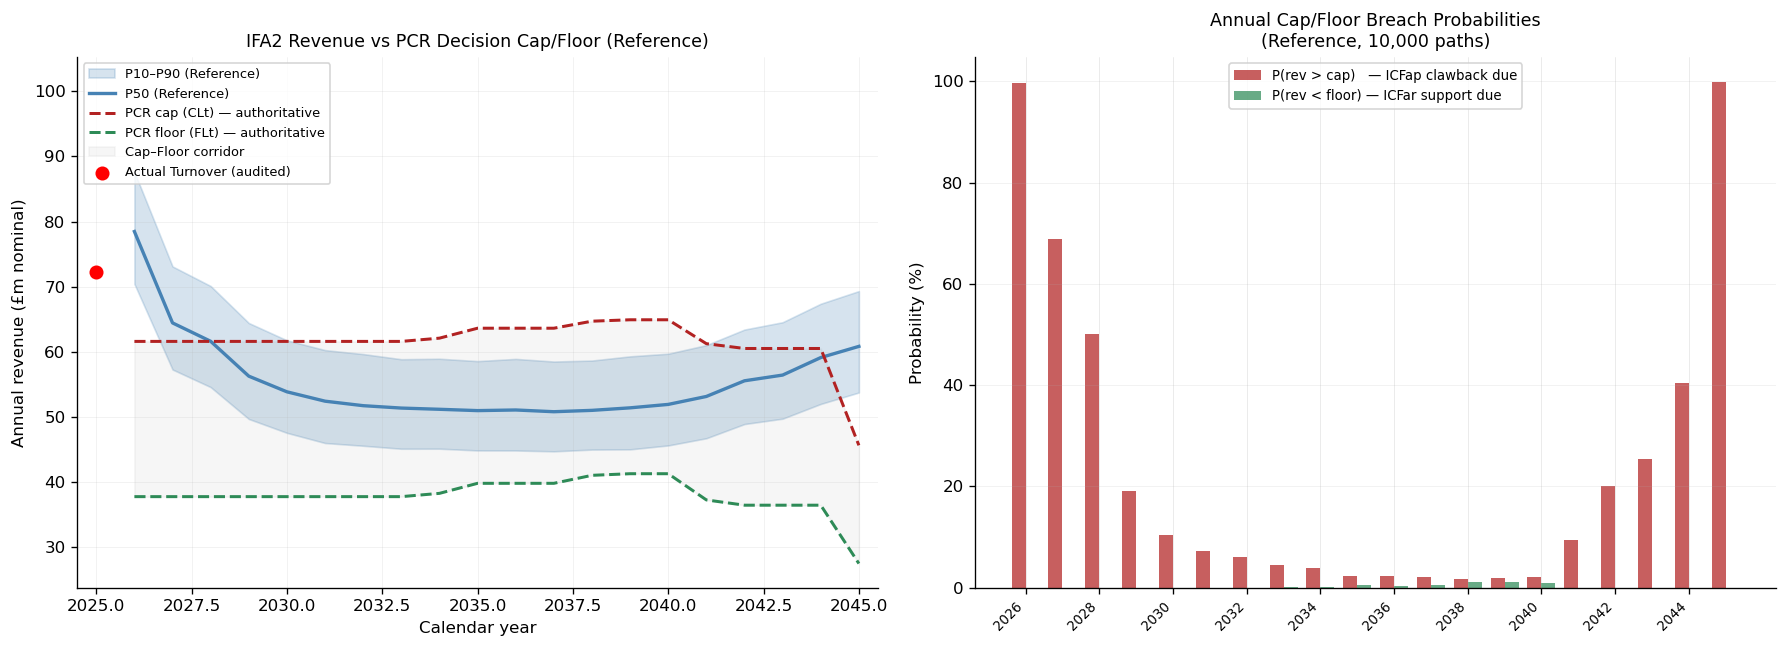

Saved: figS6_cap_floor_breach.png


In [36]:
# == Section 19.4: Fan Chart + Breach Probability Plot ===================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# ─ Panel 1: Revenue fan vs PCR cap/floor band ────────────────────────
ax1.fill_between(proj_cal_years, p10, p90, alpha=0.22, color='steelblue',
                 label='P10\u2013P90 (Reference)')
ax1.plot(proj_cal_years, p50,       lw=2.0, color='steelblue', label='P50 (Reference)')
ax1.plot(proj_cal_years, cap_arr,   lw=1.8, color='firebrick', ls='--',
         label='PCR cap (CLt) \u2014 authoritative')
ax1.plot(proj_cal_years, floor_arr, lw=1.8, color='seagreen',  ls='--',
         label='PCR floor (FLt) \u2014 authoritative')
ax1.fill_between(proj_cal_years, floor_arr, cap_arr,
                 alpha=0.07, color='grey', label='Cap\u2013Floor corridor')
for yr, val in ACTUALS.items():
    ax1.scatter([yr], [val], color='red', zorder=6, s=55)
ax1.scatter([], [], color='red', s=55, label='Actual Turnover (audited)')
ax1.set_xlim(2024.5, 2045.5)
ax1.set_title('IFA2 Revenue vs PCR Decision Cap/Floor (Reference)', fontsize=10.5)
ax1.set_xlabel('Calendar year')
ax1.set_ylabel('Annual revenue (£m nominal)')
ax1.legend(fontsize=7.8, loc='upper left')
ax1.grid(alpha=0.3)

# ─ Panel 2: Annual breach probability bars ───────────────────────────
x = np.arange(len(proj_cal_years))
w = 0.38
ax2.bar(x - w/2, prob_cap   * 100, width=w, color='firebrick', alpha=0.72,
        label='P(rev > cap)   \u2014 ICFap clawback due')
ax2.bar(x + w/2, prob_floor * 100, width=w, color='seagreen',  alpha=0.72,
        label='P(rev < floor) \u2014 ICFar support due')
ax2.set_xticks(x[::2])
ax2.set_xticklabels(proj_cal_years[::2], rotation=45, ha='right', fontsize=8)
ax2.set_title('Annual Cap/Floor Breach Probabilities\n(Reference, 10,000 paths)',
              fontsize=10.5)
ax2.set_ylabel('Probability (%)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figS6_cap_floor_breach.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')


In [37]:
# == Section 19.5: 5-Year NPV Assessment Periods =========================
# Cap operates on 5-year NPV basis.  ICFap due if NPV(Turnover) > NPV(CLt).
# Period 1 (op yr 0-4 ≈ cal 2020-2024): already settled.
# Periods 2-5: P(NPV_revenue > NPV_cap) from MC paths.

# Build all-regime revenue matrix: actuals 2022-2025, MC 2026-2045
# 2021: Ofgem turnover not disclosed -> left as 0
all_reg_yrs = list(range(REGIME_START, REGIME_START + 25))  # 2021-2045
rpit_reg  = np.array([CFFM2_RPIt.get(yr, CFFM2_RPIt[max(CFFM2_RPIt)])
                      for yr in all_reg_yrs])
rev_full  = np.zeros((N_PATHS, 25))
for i, yr in enumerate(all_reg_yrs):
    if yr in ACTUALS:
        rev_full[:, i] = ACTUALS[yr] / rpit_reg[i]   # nominal -> 2016/17-real
    elif yr in proj_cal_years:
        rev_full[:, i] = annual_rev[:, proj_cal_years.index(yr)]

cap_reg   = np.array([full_sched.get(yr, {}).get('cap',   np.nan)
                      for yr in all_reg_yrs]) / rpit_reg
floor_reg = np.array([full_sched.get(yr, {}).get('floor', np.nan)
                      for yr in all_reg_yrs]) / rpit_reg

# Assessment periods (calendar year approximation to CFFM2 April-year periods)
# Period 1 (op yr 0-4 ≈ cal 2020-2024): CLOSED — actual ICFap = £245.2m
# Period 2 (op yr 5-9 ≈ cal 2025-2029), Period 3 (2030-2034), etc.
periods = [(2, 2025, 2029), (3, 2030, 2034), (4, 2035, 2039), (5, 2040, 2044)]

print(f'=== 5-YEAR NPV ASSESSMENT  (ODR = {ODR*100:.3f}% real) ===')
print()
print('  Period 1 (2020\u20132024): CLOSED')
print('   Actual ICFap: £245.2m  |  Actual ICFap P2 end: £311.3m  '
      '  (CFFM2 Revenue Adjustment row 18)')
print()
print(f'  {"Period":>8}  {"Years":>11}  {"P50 NPV Rev":>12} {"NPV Cap":>9}'
      " NPV Floor   P>Cap   P<Flr")
print('  ' + '-'*70)

for pnum, yr_start, yr_end in periods:
    yr_range = [yr for yr in range(yr_start, yr_end + 1) if yr in all_reg_yrs]
    if not yr_range:
        continue
    idx  = [all_reg_yrs.index(yr) for yr in yr_range]
    disc = np.array([(1 + ODR) ** -(yr - yr_start) for yr in yr_range])

    npv_rev   = (rev_full[:, idx] * disc[np.newaxis, :]).sum(axis=1)
    npv_cap   = float(np.nansum(cap_reg[idx]   * disc))
    npv_floor = float(np.nansum(floor_reg[idx] * disc))
    p_above   = float((npv_rev > npv_cap).mean())
    p_below   = float((npv_rev < npv_floor).mean())
    p50_npv   = float(np.percentile(npv_rev, 50))

    print(f'  P{pnum}        {yr_start}\u2013{yr_end}   '
          f'£{p50_npv:>8.1f}m  £{npv_cap:>6.1f}m  £{npv_floor:>7.1f}m  '
          f'{p_above*100:>5.1f}%  {p_below*100:>5.1f}%')

print()
print('  P(NPV > Cap):   prob. IFA2 owes ICFap to consumers at period-end')
print('  P(NPV < Floor): prob. Ofgem owes ICFar support to IFA2 at period-end')
print('  All values 2016/17-RPI-real. Actuals + CLt/FLt deflated by CFFM2 RPIt.')
print(f'  Discount rate: {ODR*100:.3f}% real (CFFM2 Assessment ODR)')
print('  Note: Period 5 cap/floor values include non-monotonic CFFM2 outputs'
        ' in 2041 and 2045 \u2014 treat as indicative.')


=== 5-YEAR NPV ASSESSMENT  (ODR = 3.945% real) ===

  Period 1 (2020–2024): CLOSED
   Actual ICFap: £245.2m  |  Actual ICFap P2 end: £311.3m    (CFFM2 Revenue Adjustment row 18)

    Period        Years   P50 NPV Rev   NPV Cap NPV Floor   P>Cap   P<Flr
  ----------------------------------------------------------------------
  P2        2025–2029   £   293.5m  £ 285.5m  £  175.0m   76.4%    0.0%
  P3        2030–2034   £   243.5m  £ 285.9m  £  175.5m    0.1%    0.0%
  P4        2035–2039   £   238.4m  £ 297.0m  £  186.9m    0.0%    0.0%
  P5        2040–2044   £   256.8m  £ 285.6m  £  174.6m    1.2%    0.0%

  P(NPV > Cap):   prob. IFA2 owes ICFap to consumers at period-end
  P(NPV < Floor): prob. Ofgem owes ICFar support to IFA2 at period-end
  All values 2016/17-RPI-real. Actuals + CLt/FLt deflated by CFFM2 RPIt.
  Discount rate: 3.945% real (CFFM2 Assessment ODR)
  Note: Period 5 cap/floor values include non-monotonic CFFM2 outputs in 2041 and 2045 — treat as indicative.


## Section 21: Window 3 PCR Assessment

Window 3 uses a **2024-CPIH-real** price base instead of W1's 2016/17-RPI-real, and indexes cap/floor by CPIH rather than RPI (3.24%/yr).

| Parameter | Window 1 | Window 3 |
|---|---|---|
| Price base | 2016/17 RPI-real | 2024 CPIH-real |
| Indexation | RPI 3.24%/yr | CPIH ~2.5%/yr |
| Preliminary Cap + PCA | ~£61.6m (2016/17-real) | £90.4m (2024-real) |
| Preliminary Floor + PCA | ~£37.8m (2016/17-real) | £84.3m (2024-real) |
| Cap return rate | — | 7.42% real |
| Floor return rate | — | 3.55% real |

Because CPIH grows slower than RPI (~2.5% vs 3.24%/yr), the W3 cap declines gradually in 2016/17-RPI-real terms over the regime, making cap breach increasingly likely in later years relative to W1.

`ifa2_w3_pcr_p{10,50,90}.xlsm` saved to M2/ (unlocked, ARt written, CPIHt factors written to Inputs row 145 so Excel can recalculate CLt/FLt).

In [38]:
import shutil, openpyxl

# ── W3 constants (from Inputs rows 26-30; base: 2024-CPIH-real £m) ────────────
# Updated from iFA2CFFM2_PCR_decision_W3.xlsm (2026-07-08)
W3_TEMPLATE    = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision_W3.xlsm')
W3_PCL         = 70.52931207672806    # Preliminary Cap Level
W3_PCAC        = 19.83345454154676    # PCA adjustment to Cap
W3_PFL         = 55.91842398714817    # Preliminary Floor Level
W3_PCAF        = 28.34628754846391    # PCA adjustment to Floor
W3_CAP_2024    = W3_PCL + W3_PCAC    # £90.363m  — constant in 2024-CPIH-real
W3_FLR_2024    = W3_PFL + W3_PCAF    # £84.264m  — constant in 2024-CPIH-real
CPIH_2024_BASE = 132.9               # ONS CPIH L522 (Jan 2015=100) for 2024
CPIH_GROWTH    = 0.025               # OBR medium-term CPIH growth (placeholder)

CPIH_HIST = {2019: 107.4, 2020: 108.0, 2021: 113.1,
             2022: 120.6, 2023: 126.1, 2024: 132.9}

def _cpih_level(yr):
    if yr in CPIH_HIST:
        return CPIH_HIST[yr]
    return CPIH_2024_BASE * (1 + CPIH_GROWTH) ** (yr - 2024)

def _cpiht(yr):
    return _cpih_level(yr) / CPIH_2024_BASE

def _to_cpih_real(rev_1617, yr):
    rpit = CFFM2_RPIt.get(yr, CFFM2_RPIt[max(CFFM2_RPIt)])
    return rev_1617 * rpit / _cpiht(yr)

def w1_cap_cpih(yr):
    return _to_cpih_real(61.6, yr)

def w1_flr_cpih(yr):
    return _to_cpih_real(37.8, yr)

# ── Cap/floor schedule in 2024-CPIH-real ─────────────────────────────────────
print("=== Window 1 vs Window 3 — Cap/Floor Schedule (2024-CPIH-real £m) ===")
print(f"  W3: cap = £{W3_CAP_2024:.2f}m  floor = £{W3_FLR_2024:.2f}m  [CONSTANT — CPIH-indexed from 2024 base]")
print(f"  W1: cap/floor RISE in 2024-CPIH-real as RPI (3.24%/yr) > CPIH (2.5%/yr)")
print()
print(f"  {'Year':>6}  {'CPIHt':>7}  {'W1Cap':>9}  {'W1Flr':>9}  {'W3Cap':>9}  {'W3Flr':>9}  {'P50 Rev':>9}")
print("  " + "-"*72)
for yr in [2026, 2028, 2030, 2032, 2035, 2038, 2040, 2045]:
    ct   = _cpiht(yr)
    w1c  = w1_cap_cpih(yr)
    w1f  = w1_flr_cpih(yr)
    if yr >= PROJ_START_YEAR:
        idx    = yr - PROJ_START_YEAR
        p50_v  = float(np.percentile(_to_cpih_real(annual_rev[:, idx], yr), 50))
        p50_s  = f"£{p50_v:>7.2f}m"
    else:
        p50_s  = "   n/a  "
    print(f"  {yr:>6}  {ct:>7.4f}  £{w1c:>7.2f}m  £{w1f:>7.2f}m  £{W3_CAP_2024:>7.2f}m  £{W3_FLR_2024:>7.2f}m  {p50_s}")

# ── Write ARt (nominal) to W3 CFFM2 files ────────────────────────────────────
W3_CR_ROW       = 29
W3_COL_YR_START = 16
W3_INP_CPIH_ROW = 145
TOTAL_REGIME_W3 = 25

print()
for pct_label, proj_values in [('p10', p10), ('p50', p50), ('p90', p90)]:
    full_25 = []
    for yr in range(REGIME_START, REGIME_START + TOTAL_REGIME_W3):
        cpiht_yr = _cpiht(yr)
        if yr < PROJ_START_YEAR:
            # Actuals are nominal -> 2024-CPIH-real
            nom = ACTUALS.get(yr, None)
            full_25.append(round(nom / cpiht_yr, 2) if nom is not None else None)
        else:
            # 2016/17-RPI-real x RPIt / CPIHt = 2024-CPIH-real
            idx  = yr - PROJ_START_YEAR
            rpit = CFFM2_RPIt.get(yr, CFFM2_RPIt[max(CFFM2_RPIt)])
            full_25.append(round(float(proj_values[idx]) * rpit / cpiht_yr, 2))

    out_path = OUTPUT_DIR / f'ifa2_w3_pcr_{pct_label}.xlsm'
    shutil.copy2(W3_TEMPLATE, out_path)
    wb_w3 = openpyxl.load_workbook(out_path, keep_vba=True)
    for ws_s in wb_w3.worksheets:
        ws_s.protection.sheet = False
    ws_cr_w3 = wb_w3['Costs & Revenue']
    for i, val in enumerate(full_25):
        if val is not None:
            ws_cr_w3.cell(row=W3_CR_ROW, column=W3_COL_YR_START + i, value=val)
    ws_in_w3 = wb_w3['Inputs']
    for i, yr in enumerate(range(REGIME_START, REGIME_START + TOTAL_REGIME_W3)):
        ws_in_w3.cell(row=W3_INP_CPIH_ROW, column=W3_COL_YR_START + i, value=round(_cpiht(yr), 6))
    wb_w3.save(out_path)
    wb_w3.close()
    print(f'Written (unlocked): {out_path.name}  |  2026: £{full_25[5]:.1f}m nom  |  2045: £{full_25[-1]:.1f}m nom')

# ── Annual breach table ───────────────────────────────────────────────────────
SEP = "-" * 99
print()
print("=== Annual Breach Table: 2024-CPIH-real basis ===")
print(f"  W3 cap = £{W3_CAP_2024:.2f}m  W3 floor = £{W3_FLR_2024:.2f}m  (constant)")
print(f"  W1 cap/floor rise each year as RPI outpaces CPIH")
print(SEP)
print(f"   {'Year':>4}  {'Ryr':>3}  {'W1Cap':>7}  {'W1Flr':>7}  {'W3Cap':>7}  {'P10':>7}  {'P50':>7}  {'P90':>7}  {'P>W3Cap':>9}  {'P<W3Flr':>9}  {'P>W1Cap':>9}")
print(SEP)

for yr in range(PROJ_START_YEAR, REGIME_START + 25):
    idx      = yr - PROJ_START_YEAR
    rev_cpih = _to_cpih_real(annual_rev[:, idx], yr)
    w1c      = w1_cap_cpih(yr)
    w1f      = w1_flr_cpih(yr)
    p_w3cap  = (rev_cpih > W3_CAP_2024).mean()
    p_w3flr  = (rev_cpih < W3_FLR_2024).mean()
    p_w1cap  = (rev_cpih > w1c).mean()
    ryr      = yr - REGIME_START + 1
    p10_v    = float(np.percentile(rev_cpih, 10))
    p50_v    = float(np.percentile(rev_cpih, 50))
    p90_v    = float(np.percentile(rev_cpih, 90))
    print(f"   {yr:>4}  {ryr:>3}  {w1c:>7.1f}  {w1f:>7.1f}  {W3_CAP_2024:>7.1f}  "
          f"{p10_v:>7.1f}  {p50_v:>7.1f}  {p90_v:>7.1f}  "
          f"{p_w3cap:>9.1%}  {p_w3flr:>9.1%}  {p_w1cap:>9.1%}")

print(SEP)
print("  Revenues converted: 2016/17-RPI-real × RPIt ÷ CPIHt = 2024-CPIH-real.")
print(f"  W3 floor (£{W3_FLR_2024:.2f}m) is substantially above W1 floor in 2024-CPIH-real (~£49-57m).")
print(f"  W3 corridor (cap−floor) = £{W3_CAP_2024 - W3_FLR_2024:.2f}m — much narrower than W1.")

# ── 5-Year NPV comparison ─────────────────────────────────────────────────────
print()
print("=== 5-Year NPV Assessment: W1 vs W3 (ODR = 3.945% real, 2024-CPIH-real £m) ===")
periods = [('P2',2025,2029),('P3',2030,2034),('P4',2035,2039),('P5',2040,2044)]
disc = ODR

print(f"  {'Period':<5}  {'Years':<12}  {'P50 NPV':>9}  {'W1 Cap':>9}  {'W1 P>Cap':>9}  {'W3 Cap':>9}  {'W3 P>Cap':>9}  {'W3 Flr':>9}  {'W3 P<Flr':>9}")
print("  " + "-"*95)

for pname, y_start, y_end in periods:
    all_yrs  = list(range(y_start, y_end + 1))
    n_yrs    = len(all_yrs)
    rev_mat  = np.zeros((N_PATHS, n_yrs))
    w1_cap_v = np.zeros(n_yrs)
    w3_cap_v = np.full(n_yrs, W3_CAP_2024)
    w3_flr_v = np.full(n_yrs, W3_FLR_2024)
    disc_v   = np.array([(1 + disc) ** (-k) for k in range(n_yrs)])

    for j, yr in enumerate(all_yrs):
        if yr < PROJ_START_YEAR:
            rev_mat[:, j] = ACTUALS.get(yr, 0.0) / _cpiht(yr)
        else:
            rev_mat[:, j] = _to_cpih_real(annual_rev[:, yr - PROJ_START_YEAR], yr)
        w1_cap_v[j] = w1_cap_cpih(yr)

    npv_rev   = (rev_mat   * disc_v).sum(axis=1)
    npv_w1cap = (w1_cap_v  * disc_v).sum()
    npv_w3cap = (w3_cap_v  * disc_v).sum()
    npv_w3flr = (w3_flr_v  * disc_v).sum()

    p_w1cap = (npv_rev > npv_w1cap).mean()
    p_w3cap = (npv_rev > npv_w3cap).mean()
    p_w3flr = (npv_rev < npv_w3flr).mean()
    p50_npv = float(np.median(npv_rev))

    print(f"  {pname:<5}  {y_start}–{y_end}  £{p50_npv:>7.1f}m  £{npv_w1cap:>7.1f}m  {p_w1cap:>9.1%}  £{npv_w3cap:>7.1f}m  {p_w3cap:>9.1%}  £{npv_w3flr:>7.1f}m  {p_w3flr:>9.1%}")

print()
annuity_5 = sum((1 + disc) ** (-k) for k in range(5))
print(f"  W3 cap NPV = £{W3_CAP_2024:.2f}m x {annuity_5:.4f} = £{W3_CAP_2024 * annuity_5:.1f}m per 5-yr period.")
print(f"  W3 flr NPV = £{W3_FLR_2024:.2f}m x {annuity_5:.4f} = £{W3_FLR_2024 * annuity_5:.1f}m per 5-yr period.")
print(f"  W1 cap NPV rises each period as RPI-indexed cap grows faster than CPIH-indexed discount base.")

=== Window 1 vs Window 3 — Cap/Floor Schedule (2024-CPIH-real £m) ===
  W3: cap = £90.36m  floor = £84.26m  [CONSTANT — CPIH-indexed from 2024 base]
  W1: cap/floor RISE in 2024-CPIH-real as RPI (3.24%/yr) > CPIH (2.5%/yr)

    Year    CPIHt      W1Cap      W1Flr      W3Cap      W3Flr    P50 Rev
  ------------------------------------------------------------------------
    2026   1.0506  £  80.75m  £  49.55m  £  90.36m  £  84.26m  £ 102.87m
    2028   1.1038  £  81.92m  £  50.27m  £  90.36m  £  84.26m  £  81.95m
    2030   1.1597  £  83.10m  £  51.00m  £  90.36m  £  84.26m  £  72.67m
    2032   1.2184  £  84.31m  £  51.73m  £  90.36m  £  84.26m  £  70.81m
    2035   1.3121  £  86.15m  £  52.86m  £  90.36m  £  84.26m  £  71.29m
    2038   1.4130  £  88.03m  £  54.02m  £  90.36m  £  84.26m  £  72.90m
    2040   1.4845  £  89.30m  £  54.80m  £  90.36m  £  84.26m  £  75.28m
    2045   1.6796  £  92.57m  £  56.81m  £  90.36m  £  84.26m  £  91.43m



Written (unlocked): ifa2_w3_pcr_p10.xlsm  |  2026: £92.3m nom  |  2045: £80.8m nom


Written (unlocked): ifa2_w3_pcr_p50.xlsm  |  2026: £102.9m nom  |  2045: £91.4m nom


Written (unlocked): ifa2_w3_pcr_p90.xlsm  |  2026: £114.9m nom  |  2045: £104.2m nom

=== Annual Breach Table: 2024-CPIH-real basis ===
  W3 cap = £90.36m  W3 floor = £84.26m  (constant)
  W1 cap/floor rise each year as RPI outpaces CPIH
---------------------------------------------------------------------------------------------------
   Year  Ryr    W1Cap    W1Flr    W3Cap      P10      P50      P90    P>W3Cap    P<W3Flr    P>W1Cap
---------------------------------------------------------------------------------------------------
   2026    6     80.7     49.5     90.4     92.3    102.9    114.9      93.8%       0.9%      99.7%
   2027    7     81.3     49.9     90.4     75.6     85.1     96.5      26.7%      45.7%      68.8%
   2028    8     81.9     50.3     90.4     72.6     81.9     93.2      15.8%      61.0%      50.2%
   2029    9     82.5     50.6     90.4     66.6     75.4     86.3       4.3%      85.9%      19.1%
   2030   10     83.1     51.0     90.4     64.2     72.7     

## Section 20: Model Outputs — Summary and Interpretation

*Run date: 2026-07-07. Price data: GB-FR07.xlsx (extended to 2026-07-07). All monetary values 2016/17-RPI-real GBPm unless stated.*
*Price basis fix applied: Section 17 inflates projected revenues ×RPIt (CFFM2 Indexation) before writing to CFFM2 ARt; Sections 19.1–19.3 and 19.5 deflate CLt/FLt ÷RPIt before breach comparison. RPIt: 2026=1.3772, 2030=1.5645, 2035=1.8349, 2040=2.1521.*

---

### 20.1 Monte Carlo Revenue — Reference Scenario

Cap ≈ £61.6m constant | Floor ≈ £37.8m constant (2016/17-real; nominal values indexed at 3.24%/yr)

| Year | Ryr | P10 | P50 | P90 | Floor | Cap | P < Floor | P > Cap |
|------|-----|-----|-----|-----|-------|-----|-----------|---------|
| 2026 | 6 | 70.4 | 78.5 | 87.6 | 37.8 | 61.6 | 0% | **99.7%** |
| 2027 | 7 | 57.3 | 64.4 | 73.1 | 37.8 | 61.6 | 0% | **68.8%** |
| 2028 | 8 | 54.6 | 61.6 | 70.1 | 37.8 | 61.6 | 0% | **50.1%** |
| 2029 | 9 | 49.7 | 56.3 | 64.4 | 37.8 | 61.6 | 0% | 19.0% |
| 2030 | 10 | 47.6 | 53.9 | 61.8 | 37.8 | 61.6 | 0% | 10.5% |
| 2035 | 15 | 44.9 | 51.0 | 58.6 | 37.8 | 61.6 | 0.5% | 2.3% |
| 2040 | 20 | 45.6 | 51.9 | 59.7 | 37.8 | 61.6 | 0.8% | 2.1% |
| 2045 | 25 | 53.8 | 60.8 | 69.3 | 37.8 | 61.6 | 0% | 99.9%* |

\* 2045 anomalous — non-monotonic CFFM2 end-of-regime indexation, not a real commercial signal.

**P50 scenario comparison (GBPm):**

| Year | Reference | FFP_Low | FFP_High |
|------|-----------|---------|----------|
| 2026 | 78.5 | 61.0 | 118.0 |
| 2030 | 53.9 | 51.6 | 57.5 |
| 2035 | 51.0 | 50.4 | 50.2 |
| 2040 | 51.9 | 54.1 | 50.2 |
| 2045 | 60.8 | 65.5 | 55.1 |

Scenarios converge by 2035. FFP_High drives significant cap breach in 2026 (P50=£118m vs cap £61.6m) but converges to Reference by 2030.

---

### 20.2 OU Model Parameters (Section 11)

| Parameter | Value |
|---|---|
| phi (daily AR) | 0.715 |
| kappa (mean reversion) | 122.8/yr |
| Half-life | 2.1 days |
| sigma_d | 14.99 GBP/MWh |
| Jump phi_Y | 0.629 |
| Jump beta | 169.6/yr |
| Jump half-life | 1.5 days |

---

### 20.3 5-Year NPV Assessment Periods (ODR = 3.945% real)

| Period | Years | P50 NPV Revenue | NPV Cap | NPV Floor | P > Cap | P < Floor |
|--------|-------|-----------------|---------|-----------|---------|-----------|
| P2 | 2025–2029 | £293.5m | £285.5m | £175.0m | **76.4%** | 0% |
| P3 | 2030–2034 | £243.5m | £285.9m | £175.5m | 0.1% | 0% |
| P4 | 2035–2039 | £238.4m | £297.0m | £186.9m | 0% | 0% |
| P5 | 2040–2044 | £256.8m | £285.6m | £174.6m | 1.2% | 0% |

Cap payment (ICFap) triggered with 76.4% probability in P2 — IFA2 pays consumers. Revenue within corridor for P3–P5; ICFar (floor support) never triggered.

---

### 20.4 Back-test Capture Ratios (Section 12)

| Year | Sim P10 | Sim P50 | Sim P90 | Actual Gross | Ofgem Net | Impl CR |
|------|---------|---------|---------|--------------|-----------|---------|
| 2024 | 292.6 | 326.5 | 365.8 | 247.6 | 78.7 | **31.8%** |
| 2025 | 230.6 | 261.4 | 299.9 | 270.6 | 54.2 | **20.0%** |
| **Mean** | | | | | | **25.9%** |

2024 actual gross (£247.6m) fell below simulated P10 — model overestimates gross, consistent with RPI deflation compressing panel spreads. 2025 within band. Mean CR 25.9% carried forward as market-cost deduction.

---

### 20.5 Against-Price Flow Analysis (Section 5.1)

Over the 2021-12-09 to 2026-07-07 sample period (extended dataset):
- **20.0%** of flowing hours saw physical flow **against** the price gradient (7,141 hrs)
- Trend: 2022 = 44% → 2024 = 7% → 2025 = 9% → 2026 = 7.4% (largely a 2022 nuclear-crisis artefact)
- Longest run: 62 continuous hours (10–13 Jul 2023, mean spread +£8.72/MWh)
- Most anomalous: 36 hrs (Jul 2022), mean spread −£102/MWh — FR massively more expensive yet FR→GB flow continued; interpreted as ENTSO-E redispatch/balancing

GCR blended CR (2022–25): **42.2%** vs back-test implied CR **25.9%**. Gap reflects against-price hours earning zero rent and auction/spot divergence. CR falling from 88.9% (2023) to 25.1% (2025) as spreads widened is the key unexplained anomaly.

---

### 20.6 Central Investment Interpretation

**IFA2 is a cap-heavy asset in P2, sitting within corridor thereafter. The floor is not load-bearing.**

Early-year P50 revenues (~£78.5m real in 2026) substantially exceed the real cap of £61.6m. IFA2 pays excess back to consumers via ICFap with **~76% probability** on the 5-year P2 NPV basis. As spread mean-reverts (half-life 2.1 days, kappa 122.8/yr), revenues decline toward £50–55m/yr by 2029–2030, falling into the corridor (cap ≈ £61.6m, floor ≈ £37.8m in 2016/17-real). They remain there through P3–P5 at P50.

| Risk dimension | Model verdict |
|---|---|
| Cap exposure (P2) | 76.4% probability ICFap triggers — upside significantly clawed back |
| Corridor behaviour (P3–P5) | P50 revenue comfortably within band; both ICFar and ICFap inactive |
| Floor risk | Essentially zero at P50; only marginal (≤0.8%) at individual year level |
| Key uncertainty | CR compression trend (88.9% → 25.1% over 2023–25) — if CR falls to ~15%, floor becomes relevant |
| Scenario sensitivity | Near-zero after 2035 — all scenarios converge as Annex M spreads narrow |

The valuation question: **how much of the early-period spread revenue survives after ICFap clawback?** The corridor in P3–P5 is wide (~£23.8m real), and P50 revenues sit roughly in the middle. The equity return profile is asymmetric — upside capped in P2, downside not protected by ICFar at P50 (floor non-binding at current CR).

---

### 20.7 Window 3 PCR Assessment (Section 21)

*W3 template: iFA2CFFM2_PCR_decision_W3.xlsm (updated 2026-07-08). Output files: ifa2_w3_pcr_p{10,50,90}.xlsm (all sheets unlocked).*
*All comparisons in 2024-CPIH-real (W3's own price base). MC revenues converted from 2016/17-RPI-real via ×RPIt÷CPIHt; actuals (nominal turnover) converted via ÷CPIHt.*

**Key structural difference**: W3 uses CPIH indexation (~2.5%/yr from Jan-2024 base 132.9) rather than W1's RPI (3.24%/yr). In 2024-CPIH-real:
- **W3 cap = £90.36m, floor = £84.26m — constant throughout the regime** (CPIH-indexed in nominal, invariant in the model's own real basis)
- **W3 corridor (cap−floor) = £6.10m** — extremely narrow relative to W1 (cap ~£81-93m, floor ~£50-57m)
- **W1 cap/floor rise over time** in 2024-CPIH-real (£80.8m/£49.6m in 2026 → £92.6m/£56.8m in 2045)

**W3 cap/floor constants (2024-CPIH-real, updated model):**
- Cap: PCL £70.53m + PCAC £19.83m = **£90.363m**
- Floor: PFL £55.92m + PCAF £28.35m = **£84.264m**

#### Cap/floor and P50 revenue schedule (2024-CPIH-real)

| Year | CPIHt | W1 Cap | W1 Flr | W3 Cap | W3 Flr | P50 Revenue |
|------|-------|--------|--------|--------|--------|-------------|
| 2026 | 1.0506 | £80.7m | £49.5m | £90.4m | £84.3m | £102.9m |
| 2028 | 1.1038 | £81.9m | £50.3m | £90.4m | £84.3m | £81.9m |
| 2030 | 1.1597 | £83.1m | £51.0m | £90.4m | £84.3m | £72.7m |
| 2035 | 1.3121 | £86.2m | £52.9m | £90.4m | £84.3m | £71.3m |
| 2040 | 1.4845 | £89.3m | £54.8m | £90.4m | £84.3m | £75.3m |
| 2045 | 1.6796 | £92.6m | £56.8m | £90.4m | £84.3m | £91.4m |

#### Annual breach probabilities (2024-CPIH-real)

| Year | P10 | P50 | P90 | P>W3Cap | P<W3Flr | P>W1Cap |
|------|-----|-----|-----|---------|---------|---------|
| 2026 | £92.3m | £102.9m | £114.9m | **93.8%** | 0.9% | 99.7% |
| 2028 | £72.6m | £81.9m | £93.2m | 15.8% | **61.0%** | 50.2% |
| 2030 | £64.2m | £72.7m | £83.3m | 2.3% | **91.5%** | 10.5% |
| 2035 | £62.7m | £71.3m | £81.9m | 1.7% | **93.6%** | 4.2% |
| 2040 | £66.2m | £75.3m | £86.6m | 5.0% | **84.9%** | 6.2% |
| 2045 | £80.8m | £91.4m | £104.2m | **54.5%** | 20.1% | 45.1% |

#### 5-Year NPV Assessment (2024-CPIH-real £m, ODR = 3.945%)

| Period | Years | P50 NPV | W1 Cap | W1 P>Cap | W3 Cap | W3 P>Cap | W3 Flr | W3 P<Flr |
|--------|-------|---------|--------|----------|--------|----------|--------|----------|
| P2 | 2025–2029 | £387.2m | £376.7m | 76.1% | £418.8m | 2.4% | £390.5m | **59.2%** |
| P3 | 2030–2034 | £333.0m | £390.5m | 0.1% | £418.8m | 0.0% | £390.5m | **99.9%** |
| P4 | 2035–2039 | £338.0m | £404.8m | 0.0% | £418.8m | 0.0% | £390.5m | **99.8%** |
| P5 | 2040–2044 | £377.7m | £419.7m | 1.2% | £418.8m | 1.3% | £390.5m | **76.2%** |

W3 NPV per 5-yr period: cap = £418.8m, floor = £390.5m.

#### Investment implications (W3 vs W1)

Under the updated W3 model, the investment character reverses completely relative to the old W3 values:

- **Cap rarely binding**: W3 cap breach is ≤2.4% in P2–P4 and only 1.3% in P5 (vs old W3: 87.8% in P2, 67.3% in P5)
- **Floor almost always binding**: P3 and P4 show 99.9%/99.8% floor breach — consumers pay a top-up to bring IFA2 to £84.3m/yr in almost every path
- **Under W3, IFA2 is a floor-supported bond from P3 onwards** — the regulatory floor at £84.3m (2024-CPIH-real) provides near-certain downside protection, while the cap rarely constrains upside
- **Contrast with W1**: W1 is cap-heavy in P2 (76% cap breach) with floor never binding; W3 is floor-heavy in P3–P5 with cap rarely binding

The narrow W3 corridor (£6.1m) means the investor receives very close to the floor level whenever spreads are below the floor — which is nearly always in P3–P5 under the base-case Annex M spread trajectory.